# Academic Failure Prediction Model

## Project Description

### Goal:
- use the given dataset about students and past exams to build a ML model to predict students grades.
- students with predicted scores under 50% will then receive additional support from School Management.


###  Data Pre-processing (10%)
- Missing values / outliers : Robust and nuanced approach
- Categorical encoding : Advanced or balanced encoding strategies
- Scaling numerical features : Method adapted to model needs

### Feature Selection and Creation (5%)
- Relevant feature selection : Justified selection using data or domain logic Optimal features chosen via analysis
- Feature transformation / creation (Optional depending on the necessity) : Useful engineered features Innovative and insightful feature creation.

### Model Comparison and Hyperparameter Selection (25%)
- Dataset splitting : train/val/test split and crossvalidation
- Model training : more than 3 models tested (among which one deep learning model) with choice justification.
- Performance comparison : In-depth multi-metric evaluation
- Hyperparameter selection/tuning : Advanced tuning with crossvalidation
- Over/underfitting analysis : Correct analysis with remedies, Deep, justified understanding

### Presentation of Results (20%)




### Report :
- EDA requires multiple graphs to be complete.
- When evaluating your failure prediction model, use a baseline (for example, the naive average of the students’ grades). This allows you to compare your model with a very simple ”worst-case” model and determine whether your approach performs better.
- For evaluating the OCR system, consider using a confusion matrix.


## Setup & Imports:

We use a kaggle jupyter server.

In [1]:
# from learntools.core import binder
# binder.bind(globals())


# from learntools.machine_learning.ex2 import *
# from learntools.feature_engineering_new.ex2 import *
# from learntools.ml_intermediate.ex1 import *

# Visual
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


# Machine Learning
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# Save values between runs
import joblib

# Feature Engineering
from sklearn.feature_selection import mutual_info_regression


# xAI
!pip install eli5




print("Setup Complete")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Setup Complete


In [2]:
runall = False

## 1. Introduction / Problem

In this project, we work on the Smart School ECAM 2026 initiative, a data-driven system designed to improve how the school supports students and manages evaluation.

The goal is split into two main parts:

- First, we focus on failure prediction. The idea is simple: use past student data and machine learning models to predict exam grades. If a student is predicted to score below 50, the system flags them so the school can offer extra help and tutoring before they fail. This part is basically about early warning detection using regression models and then converting predictions into a pass/fail decision.

- Second, we explore automatic correction using OCR (Optical Character Recognition). Here, the goal is to reduce the workload of teachers by automatically recognizing and correcting handwritten student answers. This requires image-based machine learning and classification of digits/characters.

For the failure prediction part, we test multiple models (Linear Regression, Random Forest, XGBoost and Neural Networks), we compare them using different datasets and preprocessing methods, and analyze not only accuracy but also where the models fail (especially around the critical 40–60 range). We also go beyond simple regression metrics by converting predictions into a classification problem to evaluate real-world impact (who gets flagged for support and who doesn’t).

Overall, the objective is not just to build models, but to understand how they behave, compare them properly, and evaluate whether they are actually useful in a real school decision context.

## 2. Data Exploration :

### 2.1 Raw Data Overview

We start by inspecting the raw dataset before making any preprocessing decisions. This is important because it lets us understand the original structure of the data and identify possible issues such as missing values, identifiers, and variable types.

The audit table gives us several useful clues:
- `dtype` tells us how pandas reads each column.
- `missing_values` shows which variables need preprocessing.
- `cardinality` tells us how many different values each column has.
- `mean` is useful for numerical variables.
- `sample_values` helps us see what kind of answers a column contains.

From this first overview, we can already notice that:
- `id` is only an identifier, so it should not be used as a predictive feature.
- Some columns are clearly numerical because they represent measurable quantities.
- Some columns are categorical because they represent labels, choices, or levels.
- A few columns contain missing values, so they will need special treatment later.

This first step helps us build a clear preprocessing strategy instead of encoding or cleaning the data blindly.

In [3]:
import pandas as pd
from pathlib import Path

# Path of the file to read
dataset_file_path = 'data/project_2026_dataset/student_dataset/student_failure/train.csv'

# # Read the file into a variable
raw_data = pd.read_csv(dataset_file_path) 

# Print
print(raw_data.columns)
# raw_data.describe()


Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')


In [4]:
# Dataset holding structure
dataset = {}


In [5]:
import pandas as pd
from IPython.display import display

raw_X = raw_data.drop(columns=["score_examen"])

summary = pd.DataFrame({
    "column": raw_X.columns,
    "dtype": [raw_X[col].dtype for col in raw_X.columns],
    "missing_values": [raw_X[col].isna().sum() for col in raw_X.columns],
    "mean": [
        raw_X[col].mean() if pd.api.types.is_numeric_dtype(raw_X[col]) else None
        for col in raw_X.columns
    ],
    "sample_values": [
        raw_X[col].dropna().unique()[:5] for col in raw_X.columns
    ],
    "cardinality": [raw_X[col].nunique() for col in raw_X.columns],

})

display(summary)

,column,dtype,missing_values,mean,sample_values,cardinality
0,id,int64,0,314999.500000,"[0, 1, 2, 3, 4]",630000
1,age,int64,0,20.545821,"[21, 18, 20, 19, 23]",8
2,genre,str,0,NaN,"[male, female]",2
3,diplôme,str,0,NaN,"[Computer Science, Law, Business Management, M...",7
4,heures_etude,float64,18900,4.002779,"[7.91, 4.95, 4.68, 2.0, 7.65]",792
5,assiduité_classe,float64,0,71.987261,"[98.8, 94.8, 92.6, 49.5, 86.9]",617
6,accès_internet,str,63000,NaN,"[yes, no]",2
7,heures_sommeil,float64,0,7.072758,"[4.9, 4.7, 5.8, 8.3, 9.6]",66
8,qualité_sommeil,str,0,NaN,"[average, poor, good]",3
9,méthode_etude,str,44100,NaN,"[online videos, self-study, coaching, group st...",5


The dataset contains a mix of numerical and categorical features. Some numerical variables, such as age, heures_etude, and assiduité_classe, represent real quantities. Other columns are categorical, such as genre, diplôme, qualité_sommeil, and méthode_etude, even if some of them have only a few possible values.

The audit also shows that a few columns contain missing values, especially heures_etude, accès_internet, and méthode_etude. This means preprocessing will need to handle both data type differences and incomplete values before model training.

### 2.2. Variable Typing

Now that we have explored the raw data, we can classify the variables more carefully.


We separate the variables into four groups:

- **Numerical variables**: real quantities that can be measured and compared mathematically.
- **Binary categorical variables**: categories with only two possible values.
- **Ordinal categorical variables**: categories with a natural order.
- **Nominal categorical variables**: categories with no natural order.

This distinction is important because each type of variable needs a different encoding strategy later.


For example:
- `age`, `heures_etude`, `assiduité_classe`, `heures_sommeil`, `heures_fête`, and `taille_etudiant` are numerical because they represent measurable quantities.
- `genre` and `accès_internet` are binary categorical.
- `qualité_sommeil`, `évaluation_établissement`, and `difficulté_examen` are ordinal categorical because their values have a clear order.
- `diplôme` and `méthode_etude` are nominal categorical because they are simply labels without a meaningful ranking.

Even if some numerical columns have only a few unique values, they remain numerical if they represent quantities rather than categories.


#### 2.1 Numerical Variables

The numerical variables are the columns that represent measurable quantities:

- `age`
- `heures_etude`
- `assiduité_classe`
- `heures_sommeil`
- `heures_fête`
- `taille_etudiant`

These columns can be used directly as numbers in the model.  
Even if some of them have only a few unique values, they are still numerical because they represent real quantities and not categories

#### 2.2 Categorical Variables

Categorical variables describe groups, labels, or levels rather than continuous quantities.

In this dataset, we separate them into three groups:
- binary categorical variables
- ordinal categorical variables
- nominal categorical variables

This distinction matters because each group may need a different encoding method later.

##### Binary Categorical

These variables have only two possible values:

- `genre`
- `accès_internet`

Because they only have two categories, they can be encoded very simply, often with one-hot encoding or a 0/1 mapping.

##### Ordinal Categorical

These variables have a natural order:

- `qualité_sommeil` → poor, average, good
- `évaluation_établissement` → low, medium, high
- `difficulté_examen` → easy, moderate, hard

Since the categories are ordered, ordinal encoding can be appropriate here if we want the model to keep that order.

##### Nominal Categorical

These variables do not have a meaningful order:

- `diplôme`
- `méthode_etude`

For these columns, one-hot encoding is usually the safest choice because it does not impose an artificial ranking.


#### 2.3 Final data types

After this inspection, we can summarize the raw predictors as:

- numerical variables: real measurable quantities
- binary categorical variables: two possible labels
- ordinal categorical variables: ordered categories
- nominal categorical variables: unordered categories

This classification will guide the preprocessing step, especially the choice of encoding method.

In [6]:
numerical_cols = [
    "age",
    "heures_etude",
    "assiduité_classe",
    "heures_sommeil",
    "heures_fête",
    "taille_etudiant"
]

binary_categorical_cols = [
    "genre",
    "accès_internet"
]

ordinal_categorical_cols = [
    "qualité_sommeil",
    "évaluation_établissement",
    "difficulté_examen"
]

nominal_categorical_cols = [
    "diplôme",
    "méthode_etude"
]

### 2.3. EDA plots on raw data

#### Plot 1: Distribution of the target :

The distribution of the `exam_score` is roughly bell-shaped and centered around 60.
There is a noticeable spike at `100`, which does not follow the smooth bell curve.

Implications of the spike at score 100
That spike likely means something important:
possible ceiling effect, grade rounding, score clipping, extra bonus / perfect-score group or a subset of students with exceptional performance

- the model may need to learn a pattern that is not fully smooth.
- It also tells us that the prediction task is not just about predicting the center of the distribution; the top end may behave differently.


The target distribution is approximately bell-shaped and centered around 60, but there is a strong spike at 100. This suggests that the score may be capped, rounded, or that a subgroup of students systematically reaches the maximum score. Because of this peak, the target is not perfectly continuous in practice, and the model may need to handle the upper boundary carefully.


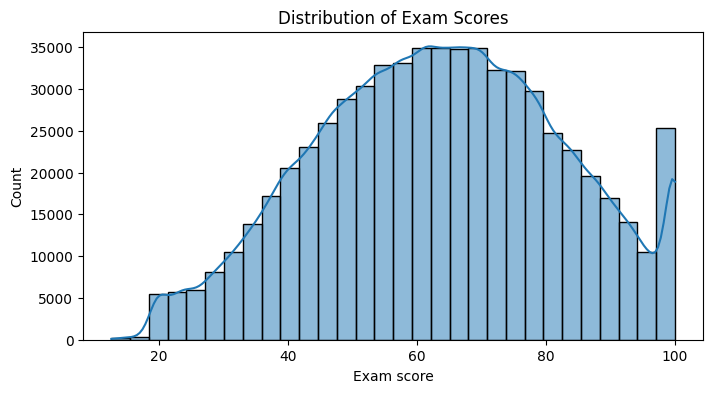

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(raw_data['score_examen'], bins=30, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam score")
plt.ylabel("Count")
plt.show()

#### Plot 2: Numerical features vs target :

The relationship between study hours and exam score is clearly positive. Students who study more tend to obtain higher scores, and the correlation is strong at about 0.76.

Because the dataset is large and many points overlap, a simple scatterplot becomes too dense. To make the pattern readable, we use a sampled scatterplot together with a binned average trend line. This shows both the local variability and the general upward relationship.

This plot confirms that `heures_etude` is one of the strongest numerical predictors of the target.

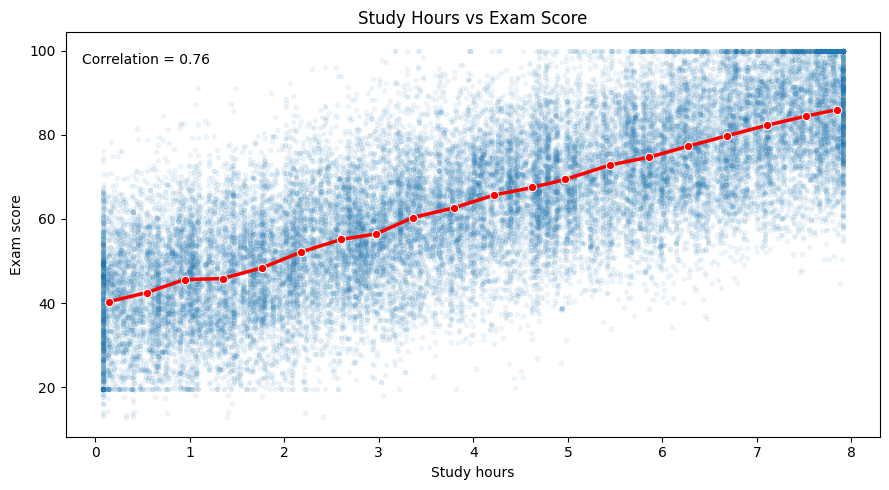

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snsraw_data

tmp = raw_data[["heures_etude", "score_examen"]].dropna().copy()

# Sample points so the scatter stays readable
sample_df = tmp.sample(n=min(30000, len(tmp)), random_state=0)

# Build bins to show the average trend clearly
tmp["study_bin"] = pd.qcut(tmp["heures_etude"], q=20, duplicates="drop")
bin_summary = tmp.groupby("study_bin", observed=True).agg(
    mean_study_hours=("heures_etude", "mean"),
    mean_score=("score_examen", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

# faint scatter for local detail
sns.scatterplot(
    data=sample_df,
    x="heures_etude",
    y="score_examen",
    alpha=0.08,
    s=12,
    edgecolor=None,
    ax=ax
)

# trend line using binned averages
sns.lineplot(
    data=bin_summary,
    x="mean_study_hours",
    y="mean_score",
    color="red",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study hours")
ax.set_ylabel("Exam score")
ax.text(
    0.02, 0.95,
    f"Correlation = {raw_data[['heures_etude', 'score_examen']].corr().iloc[0,1]:.2f}",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

#### Plot 3: Categorical feature vs target :

This plot shows a clear ordered pattern across study methods. The exam score increases from `self-study` to `coaching`, which suggests that the type of study method is strongly related to performance.

This is interesting because it confirms that `méthode_etude` is not just a nominal category: it behaves like an ordered variable in practice. That means the feature likely contains useful predictive information.

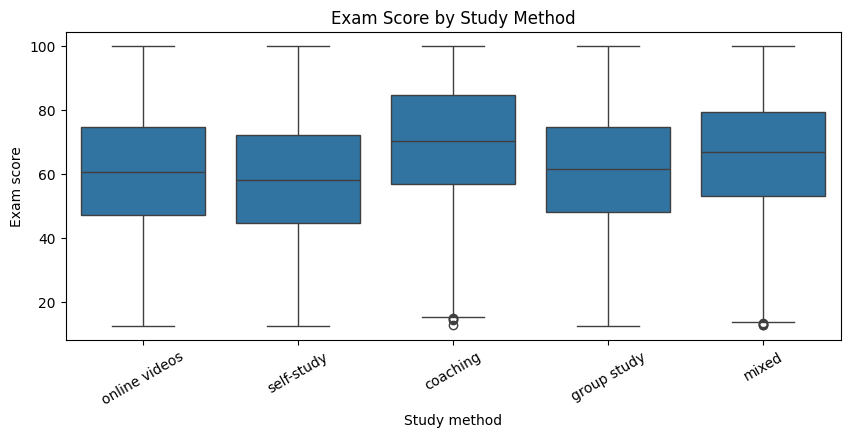

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=raw_data, x='méthode_etude', y='score_examen')
plt.title("Exam Score by Study Method")
plt.xlabel("Study method")
plt.ylabel("Exam score")
plt.xticks(rotation=30)
plt.show()


#### Plot 3.1: Exam score by internet access

Students with internet access (`yes`) appear to score about 10 points higher on average than students without access (`no`).

This does not prove that internet access alone causes better grades, but it suggests that the feature is associated with performance and may capture access to online learning resources or support.

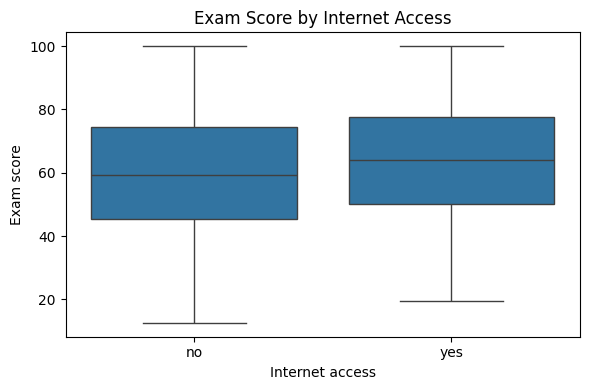

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=raw_data,
    x="accès_internet",
    y="score_examen",
    order=["no", "yes"]
)
plt.title("Exam Score by Internet Access")
plt.xlabel("Internet access")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

#### Plot 4: Correlation heatmap for numerical features :

This heatmap summarizes the linear relationships between the numerical variables. Most pairs are very close to zero, which *only* means they are only weakly related linearly.

The strongest relationship is between `heures_etude` and `score_examen` (about 0.76), which makes it the most informative numerical predictor. `assiduité_classe` also has a moderate positive correlation with the target, while `heures_sommeil` has only a weak positive relationship.

Overall, this plot tells us that a few numerical variables are clearly useful, but most of the signal is probably spread across several features rather than concentrated in many strong linear relationships.

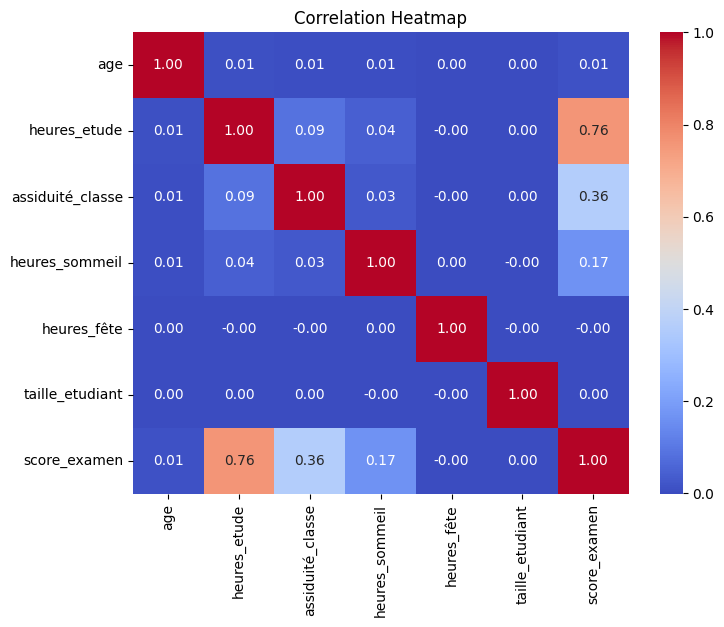

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(raw_data[numerical_cols + ['score_examen']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

the correaltion heatmap shows 0.00 to 0.01 for all the features pairs except for
- score_examen >< heures_étude : 0.76
- score_examen ><assiduité_classe : 0.36
- score_examen >< heures_sommeil : 0.17

#### Notes

Bivariate plots (interaction between features) is done in chapter 4 : Feature Engineering.




## 3. Preprocessing

### 3.1 Dataset Splitting

In [12]:
# 1. Drop target and id columns
X_raw = raw_data.drop(columns=["score_examen", "id"])
y = raw_data["score_examen"]

# Divide data into training and validation subsets
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, 
    train_size=0.8, 
    test_size=0.2, 
    random_state=0
)

# Dataset holding structure
dataset["raw"] = {
    "X_train": X_train_raw.copy(),
    "X_valid": X_valid_raw.copy(),
    "y_train": y_train.copy(),
    "y_valid": y_valid.copy(),
    "description": "Raw (0.8 - 0.2) split"
}


### 3.2 Missing Values

#### Overview

- the missingness is not tiny
- it is concentrated in only a few columns
- those columns are also meaningful predictors, so dropping them would throw away useful signal


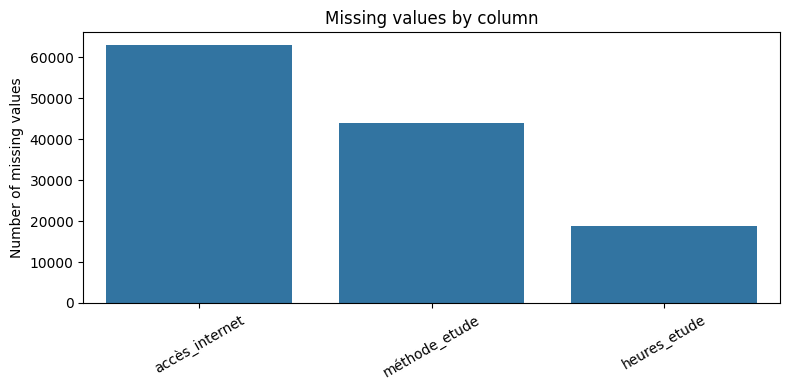

Missing values by column:
accès_internet    63000
méthode_etude     44100
heures_etude      18900
dtype: int64


In [13]:
# Missing-values summary
missing_val_count_by_column = raw_data.isnull().sum()
missing_val_count_by_column = missing_val_count_by_column[missing_val_count_by_column > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_val_count_by_column.index, y=missing_val_count_by_column.values)
plt.title("Missing values by column")
plt.ylabel("Number of missing values")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


print("Missing values by column:")
print(missing_val_count_by_column)

#### Handling Missing values

Missing values are one of the main preprocessing issues in this dataset.  
Before training the model, we compare three simple strategies:

1. **Drop the columns with missing values**
2. **Impute the missing values**
3. **Impute the missing values and add a missing-value flag**

Because some of the incomplete columns are informative predictors, dropping them would remove useful information from the dataset. For that reason, we expect imputation-based methods to perform better than simple deletion.

To make the comparison fair, we first split the data into training and validation sets, and then we evaluate each approach on the same split.


In [14]:
# We compare three simple strategies:
#   1. Drop columns with missing values
#   2. Impute missing values
#   3. Impute missing values + add missing-value flags
#
#   Since the missing columns are informative, we expect imputation to work better than dropping them.


In [15]:
# ------- General Functions ---------

# Function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    """From Kaggle - Intermediate Machine Learning : 2 - Missing Values"""
    model = RandomForestRegressor(n_estimators=10, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)


def encode_for_model(train_df, valid_df):
    """One-hot encode train/validation data and align columns."""
    X_train_enc = pd.get_dummies(train_df)
    X_valid_enc = pd.get_dummies(valid_df)
    X_train_enc, X_valid_enc = X_train_enc.align(X_valid_enc, join="left", axis=1, fill_value=0)
    return X_train_enc, X_valid_enc

def impute_dataframe(train_df, valid_df):
    """Median for numeric columns, most-frequent for categorical columns.
        -> this is a custom function similar to SimpleImputer.
    """
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    numeric_cols = train_df.select_dtypes(include="number").columns
    categorical_cols = train_df.select_dtypes(exclude="number").columns

    for col in numeric_cols:
        fill_value = train_df[col].median()
        train_df[col] = train_df[col].fillna(fill_value)
        valid_df[col] = valid_df[col].fillna(fill_value)

    for col in categorical_cols:
        fill_value = train_df[col].mode(dropna=True)[0]
        train_df[col] = train_df[col].fillna(fill_value)
        valid_df[col] = valid_df[col].fillna(fill_value)

    return train_df, valid_df



#### Approach 1: Drop columns with missing values

This is the simplest solution, but it removes all information from the affected columns. In our case, that is not ideal because the missing columns are not useless variables; they still contain predictive signal.


In [16]:
# Get names of columns with missing values
cols_with_missing = [col for col in X_train_raw.columns
                        if X_train_raw[col].isnull().any()]

if runall:
    # Drop columns in training and validation data
    drop_X_train = X_train_raw.drop(columns=cols_with_missing)
    drop_X_valid = X_valid_raw.drop(columns=cols_with_missing)

    drop_X_train_enc, drop_X_valid_enc = encode_for_model(drop_X_train, drop_X_valid)

    mae_drop = score_dataset(drop_X_train_enc, drop_X_valid_enc, y_train, y_valid)
    print("MAE from Approach 1 (Drop columns with missing values):")
    print(mae_drop)

else: print("MAE from Approach 1 (Drop columns with missing values): 14.375106051097882")




MAE from Approach 1 (Drop columns with missing values): 14.375106051097882


#### Approach 2: Imputation

Here, we fill missing values instead of deleting the columns.  
For numerical variables, we use the **median**, because it is robust to extreme values.  
For categorical variables, we use the **most frequent value** so that the missing entries are replaced with a realistic category.

We see that Approach 2 has lower MAE than Approach 1, so Approach 2 performed better on this dataset.

In [17]:
if runall:
    # Imputation
    imp_X_train, imp_X_valid = impute_dataframe(X_train_raw, X_valid_raw)
    imp_X_train_enc, imp_X_valid_enc = encode_for_model(imp_X_train, imp_X_valid)

    mae_imp = score_dataset(imp_X_train_enc, imp_X_valid_enc, y_train, y_valid)
    print("MAE from Approach 2 (Imputation):")
    print(mae_imp)

else: print("MAE from Approach 2 (Imputation): 7.901258163492063")



MAE from Approach 2 (Imputation): 7.901258163492063


#### Approach 3: Imputation + missing-value flag

This method goes one step further. In addition to filling missing values, we create a binary indicator that shows whether each value was originally missing or not. This can be useful when the pattern of missingness itself contains information.

In our results, **Approach 3 achieves the best MAE: 7.83**.  
This suggests that the missingness pattern is slightly informative, and that keeping this information helps the model perform better. Therefore, for the rest of the report, we will use **Approach 3** as our final preprocessing choice.


In [18]:
# Next, we impute the missing values, while also keeping track of which values were imputed.

# Make copy to avoid changing original data (when imputing)
X_train_plus = X_train_raw.copy()
X_valid_plus = X_valid_raw.copy()

# Make new columns indicating what will be imputed
for col in cols_with_missing:
    X_train_plus[col + '_was_missing'] = X_train_plus[col].isna().astype(int)
    X_valid_plus[col + '_was_missing'] = X_valid_plus[col].isna().astype(int)

# Imputation
imputed_X_train_plus, imputed_X_valid_plus = impute_dataframe(X_train_plus, X_valid_plus)
flag_X_train_enc, flag_X_valid_enc = encode_for_model(imputed_X_train_plus, imputed_X_valid_plus)


mae_flag = score_dataset(flag_X_train_enc, flag_X_valid_enc, y_train, y_valid)
print("MAE from Approach 3 (Imputation + flag):")
print(mae_flag)

# print("Number of missing columns:", len(cols_with_missing))
# print("Missing columns:", cols_with_missing)

MAE from Approach 3 (Imputation + flag):
7.834090297619047


#### So, why did imputation perform better than dropping the columns?

The training data has 504000 rows and 32 columns, where 1 column contain missing data. 

The training data has many rows and 32 columns, and only one column contains missing values. Since relatively few values are missing, dropping the entire column removes useful information from the dataset. Imputation, on the other hand, preserves that information by filling in the missing entries, which is why it performs better here.

In [19]:
# Shape of training data (num_rows, num_columns)
print(X_train_raw.shape)

# Number of missing values in each column of training data
missing_val_count_by_column = (X_train_raw.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0])

(504000, 13)
heures_etude      15065
accès_internet    50346
méthode_etude     35432
dtype: int64


#### Final choice for the next steps


For this dataset, imputation + missing-value flags is a stronger choice than dropping the column. It keeps more information available to the model while still handling the missing values in a reasonable way.

In [20]:
# our choice of imputed values that will be used for the next steps
approach3_X_train = imputed_X_train_plus.copy()
approach3_X_valid = imputed_X_valid_plus.copy()


dataset["imputed_with_flag"] = {
    "X_train": approach3_X_train.copy(),
    "X_valid": approach3_X_valid.copy(),
    "description": "Imputed split with missingness flags"
}




### 3.3 Extreme Values/Outliers

Extreme values are observations far from the rest of the data.
They are often called outliers, but not every extreme value is a problem.
Some are errors (impossible values, bad data entry).
Some are real but rare values, which may still be useful.




The boxplots help us check whether some numerical variables contain extreme values. In this dataset, the numerical features appear to stay within plausible ranges, so we do not remove outliers aggressively. Since the tree-based models used later are fairly robust, we prefer to keep the data unchanged unless a value is clearly suspicious.

Later we might use Outliers handling techniques such as : 
- keep all values
- cap outliers
- remove outliers
- transform skewed columns

And compare them with each other.

Note : see boxplot documentation [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

```bash
     Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers
                       IQR
```



,feature,min,max,median,q1,q3,iqr
0,age,17.00,24.00,21.00,19.00,23.00,4.00
1,heures_etude,0.08,7.91,4.00,2.03,6.00,3.97
2,assiduité_classe,40.60,99.40,72.50,57.00,87.20,30.20
3,heures_sommeil,4.10,9.90,7.10,5.60,8.60,3.00
4,heures_fête,0.00,19.00,4.00,3.00,5.00,2.00
5,taille_etudiant,1.48,2.03,1.75,1.66,1.85,0.19


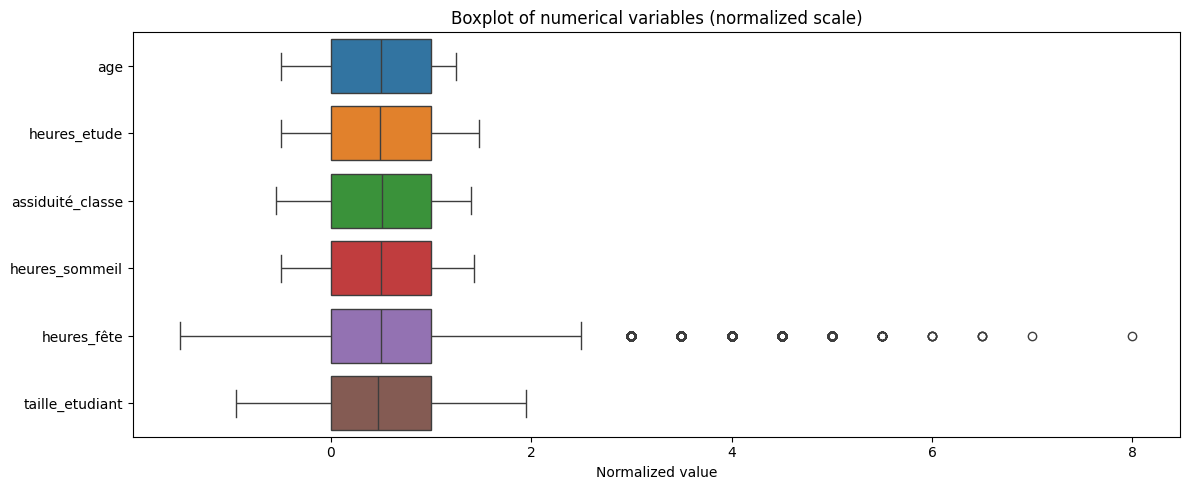

In [21]:
# small outlier check for numerical variables
# Print dynamic scale info for each numerical feature

scale_summary = pd.DataFrame({
    "feature": numerical_cols,
    "min": [approach3_X_train[col].min() for col in numerical_cols],
    "max": [approach3_X_train[col].max() for col in numerical_cols],
    "median": [approach3_X_train[col].median() for col in numerical_cols],
    "q1": [approach3_X_train[col].quantile(0.25) for col in numerical_cols],
    "q3": [approach3_X_train[col].quantile(0.75) for col in numerical_cols],
})

scale_summary["iqr"] = scale_summary["q3"] - scale_summary["q1"]
display(scale_summary)

# Robust normalization per feature for visualization
normalized_outlier_df = approach3_X_train[numerical_cols].copy()

for col in numerical_cols:
    q1 = normalized_outlier_df[col].quantile(0.25)
    q3 = normalized_outlier_df[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        normalized_outlier_df[col] = 0
    else:
        normalized_outlier_df[col] = (normalized_outlier_df[col] - q1) / iqr

plt.figure(figsize=(12, 5))
sns.boxplot(data=normalized_outlier_df, orient="h")
plt.title("Boxplot of numerical variables (normalized scale)")
plt.xlabel("Normalized value")
plt.tight_layout()
plt.show()

In [22]:
# Boxplot fences and outlier counts for each numerical column
outlier_report = []

for col in numerical_cols:
    q1 = approach3_X_train[col].quantile(0.25)
    q3 = approach3_X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    n_outliers = ((approach3_X_train[col] < lower_fence) | (approach3_X_train[col] > upper_fence)).sum()

    outlier_report.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence,
        "n_outliers": n_outliers,
        "min": approach3_X_train[col].min(),
        "max": approach3_X_train[col].max(),
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)



col = "heures_fête"

q1 = approach3_X_train[col].quantile(0.25)
q3 = approach3_X_train[col].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = approach3_X_train.loc[
    (approach3_X_train[col] < lower_fence) | (approach3_X_train[col] > upper_fence),
    col
].sort_values()

print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Outlier values:")
print(outliers.value_counts().sort_index())

,feature,q1,q3,iqr,lower_fence,upper_fence,n_outliers,min,max
0,age,19.00,23.00,4.00,13.000,29.000,0,17.00,24.00
1,heures_etude,2.03,6.00,3.97,-3.925,11.955,0,0.08,7.91
2,assiduité_classe,57.00,87.20,30.20,11.700,132.500,0,40.60,99.40
3,heures_sommeil,5.60,8.60,3.00,1.100,13.100,0,4.10,9.90
4,heures_fête,3.00,5.00,2.00,0.000,8.000,10807,0.00,19.00
5,taille_etudiant,1.66,1.85,0.19,1.375,2.135,0,1.48,2.03


Lower fence: 0.0
Upper fence: 8.0
Outlier values:
heures_fête
9     6629
10    2739
11     970
12     335
13     108
14      17
15       4
16       3
17       1
19       1
Name: count, dtype: int64


“heures_fête shows a mild-to-strong right skew, with a large concentration around 3–5 hours and a long upper tail. According to the IQR rule, values above 8 are statistical outliers, but they remain plausible observations rather than obvious errors. For this reason, we keep the feature and avoid aggressive removal.”

Note : these outliers could be strong predictors of academic success.

### 3.4 Categorical encoding : 

After the raw audit, variable typing, EDA, and missing-value analysis, we now have a clearer view of the categorical variables in the dataset.

The EDA suggested that not all categorical variables should be treated the same way:
- `méthode_etude` behaves like an ordered variable in practice,
- `accès_internet` separates students into two meaningful groups,
- `genre` is a binary label,
- `diplôme` does not have a natural ranking.

We also already handled missing values in the previous step. For Approach 3, missingness is kept as additional binary flag columns, which means that the information about “was missing or not” is preserved explicitly in the dataset.

The goal of this section is therefore to choose an encoding strategy that matches the meaning of each categorical variable, instead of applying the same method everywhere.


1. Ordinal Encoding :
Ordinal encoding assigns each unique value to a different integer. But this assumes an ordering of the categories which doesn't always fit certain situations by giving more weight to certain variables when it doesn't always make sense.



2. One-Hot Encoding
One-hot encoding creates new columns indicating the presence (or absence) of each possible value in the original data
one-hot encoding does not assume an ordering of the categories. Thus, you can expect this approach to work particularly well if there is no clear ordering in the categorical data (e.g., "Red" is neither more nor less than "Yellow"). We refer to categorical variables without an intrinsic ranking as nominal variables.

#### Encoding choice by group 

- **Binary categorical**(`genre`, `accès_internet`): use `0/1` mapping or one-hot encoding; both are fine, but 0/1 is simpler.
- **Ordinal categorical** (`qualité_sommeil`, `évaluation_établissement`, `difficulté_examen`): use ordinal encoding, because their order carries meaning.
- **Nominal categorical** (`diplôme`, `méthode_etude`): use one-hot encoding, because there is no natural ranking.

#### How we compare Encodings

1. Build Baseline: “simple sklearn preprocessing with one-hot for all categorical variables”
2. Final best pipeline: “more structured encoding using binary / ordinal / nominal treatment”
3. Compare
4. Then try small variants where you change one encoding choice at a time.

Note : we use the same Pipeline structure as given in Kaggle "Intermediate ML - 4 Pipelines".

#### Single Encoded pipeline

In [23]:
# 1. Baseline model : (inspired from Kaggle: 4 - Pipelines)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Baseline preprocessing
numerical_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

single_encoded_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer  , numerical_cols),
        ("bin", categorical_transformer, binary_categorical_cols),
        ("ord", categorical_transformer, ordinal_categorical_cols),
        ("nom", categorical_transformer, nominal_categorical_cols),
    ]
)


# --------- Store into dataset ---------
X_train = approach3_X_train
X_valid = approach3_X_valid

single_encoded_preprocessor_data = clone(single_encoded_preprocessor)
single_encoded_preprocessor_data.fit(X_train)

single_encoded_X_train = single_encoded_preprocessor_data.transform(X_train)
single_encoded_X_valid = single_encoded_preprocessor_data.transform(X_valid)

feature_names = single_encoded_preprocessor_data.get_feature_names_out()

dataset["single_encoded"] = {
    "X_train": single_encoded_X_train,
    "X_valid": single_encoded_X_valid,
    "preprocessor": single_encoded_preprocessor_data,
    "feature_names": feature_names,
    "description": "One-hot encoded features"
}

# temp_debug_sg_dataset = dataset["single_encoded"]
# print(temp_debug_sg_dataset.keys())



# ------- Fit into a test model ----------
test_single_encoded_model = RandomForestRegressor(n_estimators=3, random_state=0)

# Use from previous dataset
X_train = dataset["single_encoded"]["X_train"]
X_valid = dataset["single_encoded"]["X_valid"]

test_single_encoded_model.fit(X_train, y_train)

baseline_preds = test_single_encoded_model.predict(X_valid)  # 8.717805534391534


test_baseline_mae = mean_absolute_error(y_valid, baseline_preds)

print("Test single-encoded MAE:", test_baseline_mae)

Test single-encoded MAE: 8.717805534391534


#### Multi encoded pipeline

In [24]:
# 2. Final Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Numerical features
numerical_transformer = SimpleImputer(strategy="median")   # numeric columns will have missing values filled with the median.

# Binary features
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Missing binary values are imputed with the most frequent value.
    ("ordinal", OrdinalEncoder())                          #  turns the binary categories into numbers like 0 and 1.
])

# Ordinal features
ordinal_categories = [
    ["poor", "average", "good"],   # qualité_sommeil
    ["low", "medium", "high"],     # évaluation_établissement
    ["easy", "moderate", "hard"]   # difficulté_examen
]
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),       # Missing ordinal values are imputed.
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))  # converts ordered categories into ordered integers.
])




# Nominal features
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),    # Missing nominal values are imputed.
    ("onehot", OneHotEncoder(handle_unknown="ignore"))       # expands categories into dummy columns.
])

multi_encoded_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("bin", binary_transformer   , binary_categorical_cols),
        ("ord", ordinal_transformer  , ordinal_categorical_cols),
        ("nom", nominal_transformer  , nominal_categorical_cols),
    ]
)

# --------- Store into dataset ---------
X_train = approach3_X_train
X_valid = approach3_X_valid

multi_encoded_preprocessor_data = clone(multi_encoded_preprocessor)
multi_encoded_preprocessor_data.fit(X_train)

multi_encoded_X_train = multi_encoded_preprocessor_data.transform(X_train)
multi_encoded_X_valid = multi_encoded_preprocessor_data.transform(approach3_X_valid)

dataset["multi_encoded"] = {
    "X_train": multi_encoded_X_train,
    "X_valid": multi_encoded_X_valid,
    "preprocessor": multi_encoded_preprocessor_data,
    "description": "One-hot encoded features"
}


# ------- Fit into a test model ----------
test_multi_encoded_model = RandomForestRegressor(n_estimators=3, random_state=0)

# Use from previous dataset
X_train = dataset["multi_encoded"]["X_train"]
X_valid = dataset["multi_encoded"]["X_valid"]

test_multi_encoded_model.fit(X_train, y_train)

multi_encoded_preds = test_multi_encoded_model.predict(X_valid)  # 8.717805534391534


test_multi_encoded_mae = mean_absolute_error(y_valid, multi_encoded_preds)

print("Test Multi-encoded MAE:", test_multi_encoded_mae)


print(dataset.keys())


Test Multi-encoded MAE: 8.709697261904761
dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded'])


Using n_estimators = 100

- Baseline MAE: 7.552525982698413
- Final MAE: 7.555332094444444


#### Insights

The baseline and the final structured pipeline obtain nearly the same MAE, with the baseline being only marginally better on this validation split. The difference is too small to be considered meaningful and is likely due to normal split variability rather than a real improvement. This suggests that, for this dataset and model, the categorical encoding strategy has only a limited effect on performance. Since the structured pipeline is more consistent with the meaning of the variables and easier to justify in the report, it is reasonable to keep it for the final analysis, but this choice should be confirmed with cross-validation before drawing a final conclusion.

### 3.5 Scaling numerical features :

Scaling is a way to put numerical features on a comparable range.

A.k.a standardizing all the numerical features into a unique scale (eg. 0 - 1.0).


This is not strictly necessary for tree-based models (`DecisionTreeRegressor`, `RandomForestRegressor`, `XGBoost`)


Models that usually need scaling

- Linear models: LinearRegression, Ridge, Lasso, ElasticNet
- Distance-based models: KNN, SVM, k-means
- Neural nets: MLPRegressor, deep learning models
- Gradient-based optimization models: anything trained by gradient descent usually benefits from scaling


In [25]:
# if we later need it
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# Change only from the previous numerical preprocessing
scaled_numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler" , RobustScaler())
])

# reuse same mutli_encoded strategies, except Numerical
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaled_numerical_transformer, numerical_cols),
        ("bin", binary_transformer          , binary_categorical_cols),
        ("ord", ordinal_transformer         , ordinal_categorical_cols),
        ("nom", nominal_transformer         , nominal_categorical_cols),
    ]
)



# --------- Store into dataset ---------
X_train = approach3_X_train
X_valid = approach3_X_valid

scaled_preprocessor_data = clone(scaled_preprocessor)
scaled_preprocessor_data.fit(X_train)

scaled_X_train = scaled_preprocessor_data.transform(X_train)
scaled_X_valid = scaled_preprocessor_data.transform(X_valid)

feature_names = scaled_preprocessor_data.get_feature_names_out()

dataset["scaled"] = {
    "X_train": scaled_X_train,
    "X_valid": scaled_X_valid,
    "preprocessor": scaled_preprocessor_data,
    "feature_names": feature_names,
    "description": "Multi encoding + scaling"
}


# ------- Fit into a test model ----------
test_scaled_model = RandomForestRegressor(n_estimators=3, random_state=0)

# Use from previous dataset
X_train = dataset["scaled"]["X_train"]
X_valid = dataset["scaled"]["X_valid"]

test_scaled_model.fit(X_train, y_train)

scaled_preds = test_scaled_model.predict(X_valid)  # 8.717805534391534


test_scaled_mae = mean_absolute_error(y_valid, scaled_preds)

print("Test scaled MAE:", test_scaled_mae)



Test scaled MAE: 8.712698531746033


## 4. Feature Engineering

Feature engineering helps us create more informative inputs from the raw variables.
In this dataset, the goal is not to add many complex transformations, but to test a few simple and meaningful features that may capture student behavior better than the raw columns alone.

We first use mutual information to check which variables appear most informative.
Then we try a small number of domain-inspired features based on study time, attendance, sleep, and leisure time.
Finally, we compare the model performance before and after feature engineering to keep only what truly helps.

Goal : creating or transforming features so the model can learn better patterns.


ex. combine `heures_etude` and `heures_fête` into a `study_life` balance feature.



### 4.1 - Mutual Information

mutual information is that it can detect any kind of relationship (e.g. non-linear), while correlation only detects linear relationships.


- Very good for ranking numeric features and encoded categorical features.
- which raw features are worth keeping,
- whether some variables are weak and maybe unnecessary,
- whether the engineered features actually matter.




In [26]:
# Kaggle Utility functions from Tutorial

from sklearn.feature_selection import mutual_info_regression
import pandas as pd

def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

/tmp/ipykernel_57460/2464721298.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X.select_dtypes(["object", "category"]):


heures_etude                  0.628489
genre                         0.385986
assiduité_classe              0.174912
diplôme                       0.044910
heures_sommeil                0.043740
accès_internet                0.043601
qualité_sommeil               0.032636
méthode_etude                 0.030105
évaluation_établissement      0.024719
age                           0.007982
difficulté_examen             0.003933
taille_etudiant               0.000842
méthode_etude_was_missing     0.000531
accès_internet_was_missing    0.000391
heures_etude_was_missing      0.000167
heures_fête                   0.000000
Name: MI Scores, dtype: float64

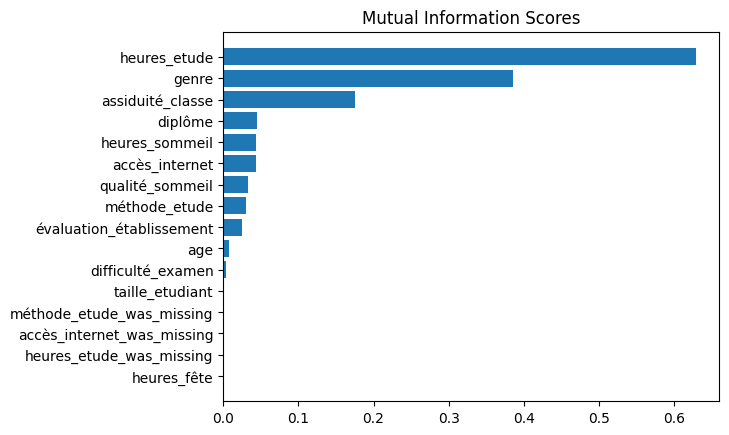

In [27]:
# Compute mutual information scores

X_mi = approach3_X_train.copy()           # use imputed dataset (not multi-encoded)
mi_scores = make_mi_scores(X_mi, y_train)

display(mi_scores)
plot_mi_scores(mi_scores)

Main Insights :
- heures_etude dominates: it is by far the most informative feature, so study time is the clearest predictor of exam score.
- genre is surprisingly strong: that suggests the target differs noticeably by gender in this dataset, so it’s worth checking for bias or hidden group effects.
- assiduité_classe matters, but less: attendance has signal, but much weaker than study time.
- Sleep and internet access are weak but non-zero: they likely help a little, but they are not primary drivers.
- heures_fête has MI = 0: by itself, it does not explain the target well, though it might still matter through interactions like study_balance or busy_score.


#### Bias Check for `genre` feature

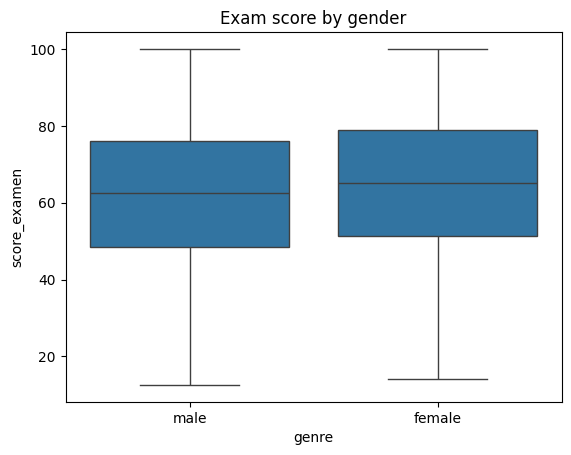

genre
female    8.727064
male      8.711100
Name: abs_error, dtype: float64

In [28]:
# Bias check for genre
sns.boxplot(data=raw_data, x="genre", y="score_examen")
plt.title("Exam score by gender")
plt.show()

val_results = pd.DataFrame({
    "genre": X_valid_raw["genre"].values,
    "y_true": y_valid.values,
    "y_pred": baseline_preds
})
val_results["abs_error"] = (val_results["y_true"] - val_results["y_pred"]).abs()
val_results.groupby("genre")["abs_error"].mean()

model appears to perform almost identically for both groups, so there is no obvious gender-based prediction bias in terms of average absolute error.

### 4.2 - Interactions between features

In [29]:
# Interaction scan: test all numeric x categorical pairs
# This helps us see which combinations are worth exploring later.

import numpy as np
import pandas as pd
from IPython.display import display

categorical_cols = binary_categorical_cols + ordinal_categorical_cols + nominal_categorical_cols
numeric_cols = numerical_cols

def slope_of_group(df, x_col, y_col="score_examen"):
    if len(df) < 2 or df[x_col].nunique() < 2:
        return np.nan
    return np.polyfit(df[x_col], df[y_col], 1)[0]

candidate_rows = []

for cat_col in categorical_cols:
    for num_col in numeric_cols:
        tmp = raw_data[["score_examen", cat_col, num_col]].dropna().copy()

        # skip useless cases
        if tmp[cat_col].nunique() < 2 or tmp[num_col].nunique() < 2:
            continue

        group_rows = []
        for category, group in tmp.groupby(cat_col):
            group_rows.append({
                "category": category,
                "count": len(group),
                "mean_score": group["score_examen"].mean(),
                "slope": slope_of_group(group, num_col),
            })

        group_df = pd.DataFrame(group_rows)

        candidate_rows.append({
            "numeric_feature": num_col,
            "categorical_feature": cat_col,
            "mean_score_range": group_df["mean_score"].max() - group_df["mean_score"].min(),
            "slope_range": group_df["slope"].max() - group_df["slope"].min(),
            "avg_group_size": group_df["count"].mean(),
        })

interaction_scan = pd.DataFrame(candidate_rows)

print("=== Interaction scan ranking ===")
display(interaction_scan.sort_values(["mean_score_range", "slope_range"],ascending=False))

best_candidate = interaction_scan.sort_values(["mean_score_range", "slope_range"],ascending=False).iloc[0]

# print(
#     f"\nBest pair: `{best_candidate['numeric_feature']}` + `{best_candidate['categorical_feature']}`"
# )

=== Interaction scan ranking ===


,numeric_feature,categorical_feature,mean_score_range,slope_range,avg_group_size
37,heures_etude,méthode_etude,11.565024,0.154669,113666.6
41,taille_etudiant,méthode_etude,11.555361,0.309225,117180.0
39,heures_sommeil,méthode_etude,11.555361,0.204353,117180.0
40,heures_fête,méthode_etude,11.555361,0.046790,117180.0
36,age,méthode_etude,11.555361,0.041831,117180.0
38,assiduité_classe,méthode_etude,11.555361,0.030761,117180.0
17,taille_etudiant,qualité_sommeil,10.866109,0.896808,210000.0
15,heures_sommeil,qualité_sommeil,10.866109,0.259392,210000.0
12,age,qualité_sommeil,10.866109,0.092567,210000.0
16,heures_fête,qualité_sommeil,10.866109,0.032102,210000.0


#### Insights :

`mean_score_range`:
- is basically telling you which categorical feature separates students the most overall.
- solely based on the categorical feature (how much does the avg exam score vary between the categories ?)


`slope_range` is telling you which numeric feature changes its effect the most across that categorical feature.


méthode_etude :
- It has the highest mean_score_range values (11.56). That means students in different study-method groups have clearly different average scores.

The correlation heatmap in EDA plots shows that heures_etude, assiduité_classe, and heures_sommeil are the strongest direct numeric predictors of score_examen. But MI score is better at capturing non-linear relationships between features, it is the better guide to identify our engineered features.


Features to try out :
1. heures_etude × méthode_etude
2. heures_sommeil × qualité_sommeil
3. heures_etude × évaluation_établissement
4. heures_etude × accès_internet



### 4.2 Simply Dropping Columns

In [30]:
def resolve_drop_columns(feature_names, raw_cols):
    """
    Map raw columns to exact encoded feature names (no substring matching).
    """

    resolved = []

    for raw in raw_cols:
        for feat in feature_names:

            # strict matching rules only
            if (
                feat == raw or
                feat.endswith(f"__{raw}") or
                feat.startswith(f"num__{raw}") or
                feat.startswith(f"bin__{raw}") or
                feat.startswith(f"ord__{raw}") or
                feat.startswith(f"nom__{raw}_")
            ):
                resolved.append(feat)

    return sorted(set(resolved))

def build_dropped_dataset(name, drop_cols, X_train_df, X_valid_df, feature_names, verbose=True):
    """
    Build a dataset variant by dropping raw feature names from encoded feature space.
    Includes validation + debug prints.
    """

    # ---------- resolver ----------
    def resolve_drop_columns(feature_names, raw_cols):
        to_drop = []

        for col in raw_cols:
            for feat in feature_names:
                if f"__{col}" in feat:   # robust matching across num/bin/ord/nom
                    to_drop.append(feat)

        return sorted(list(set(to_drop)))

    # ---------- resolve ----------
    drop_features = resolve_drop_columns(feature_names, drop_cols)

    X_train_new = X_train_df.drop(columns=drop_features, errors="ignore")
    X_valid_new = X_valid_df.drop(columns=drop_features, errors="ignore")

    # ---------- validation ----------
    removed_set = set(drop_features)
    remaining_cols = set(X_train_new.columns)

    leaks = []
    for col in drop_cols:
        for feat in remaining_cols:
            if col in feat:
                leaks.append(feat)

    # ---------- prints ----------
    if verbose:
        print("\n" + "="*60)
        print(f"DATASET: {name}")
        print("="*60)

        print(f"\nRequested drops ({len(drop_cols)}): {drop_cols}")
        print(f"Resolved encoded drops ({len(drop_features)}):")

        for f in drop_features:
            print("  -", f)

        print(f"\nOriginal feature count: {len(feature_names)}")
        print(f"Remaining feature count: {X_train_new.shape[1]}")
        print(f"Reduction: {len(feature_names) - X_train_new.shape[1]} features")

        if leaks:
            print("\n⚠️ Potential leaks detected:")
            for l in leaks:
                print("  -", l)
        else:
            print("\n✔ No leakage detected")

        print("\nSample remaining features:")
        print(list(X_train_new.columns[:10]))

    # ---------- sanity checks ----------
    assert X_train_new.shape[1] < len(feature_names), "No features were dropped!"
    assert X_train_new.shape[1] == X_valid_new.shape[1], "Train/valid mismatch!"

    # ---------- return ----------
    return {
        "X_train": X_train_new.values,
        "X_valid": X_valid_new.values,
        "feature_names": list(X_train_new.columns),
        "dropped_features": drop_features,
        "description": name
    }


In [31]:
# ------------------------------ MI Scores ------ mean_score_range ----------------
# heures_etude                  0.628489
# genre                         0.385986              2.807917
# assiduité_classe              0.174912
# diplôme                       0.044910              1.511273
# heures_sommeil                0.043740
# accès_internet                0.043601              3.987724
# qualité_sommeil               0.032636             10.866109
# méthode_etude                 0.030105             11.565024
# évaluation_établissement      0.024719              8.702634
# age                           0.007982
# difficulté_examen             0.003933              0.456789
# taille_etudiant               0.000842
# méthode_etude_was_missing     0.000531
# accès_internet_was_missing    0.000391
# heures_etude_was_missing      0.000167
# heures_fête                   0.000000


# Dataset 1 : Drop everything weak + redundant
#             (stress test), How far can we reduce features before performance collapses?
#             (removed); weak_features + missing_flags + medium_features
drop_cols_aggressive = [
    "diplôme",
    "heures_sommeil",
    "accès_internet",
    "qualité_sommeil",
    "méthode_etude",
    "évaluation_établissement",
    "age",
    "difficulté_examen",
    "taille_etudiant",
    "méthode_etude_was_missing",
    "accès_internet_was_missing",
    "heures_etude_was_missing",
    "heures_fête",
]

# Dataset 2 : keep only top predictive features (heures_etude, assiduité_classe, diplôme, qualité_sommeil)
#             (removed); weak_features + missing_flags
drop_cols_core = [
    "taille_etudiant",
    "heures_fête",
    "age",
    "difficulté_examen",
    "méthode_etude",
    # "évaluation_établissement",   # has high mean_score_range
    "accès_internet"
]

# Dataset 3 : keep only “educationally meaningful” variables
drop_cols_ethical = [
    "genre",
    "taille_etudiant",
    "age"
]

# Dataset 4 : check for bias
drop_cols_no_gender = ["genre"]


# --------- Store into dataset ---------
dataset_drop = {}

# start back at Scaled data
X_train_scaled = dataset["scaled"]["X_train"]        
X_valid_scaled = dataset["scaled"]["X_valid"]
feature_names = dataset["scaled"]["feature_names"]

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names) # Convert to Dataframe
X_valid_df = pd.DataFrame(X_valid_scaled, columns=feature_names)
print(feature_names)


# Build datasets
dataset_drop["aggressive"] = build_dropped_dataset("aggressive", drop_cols_aggressive, X_train_df, X_valid_df, feature_names)
dataset_drop["core"] = build_dropped_dataset("core", drop_cols_core, X_train_df, X_valid_df, feature_names)
dataset_drop["ethical"] = build_dropped_dataset("ethical", drop_cols_ethical, X_train_df, X_valid_df, feature_names)
dataset_drop["no_gender"] = build_dropped_dataset("no_gender", drop_cols_no_gender, X_train_df, X_valid_df, feature_names)





['num__age' 'num__heures_etude' 'num__assiduité_classe'
 'num__heures_sommeil' 'num__heures_fête' 'num__taille_etudiant'
 'bin__genre' 'bin__accès_internet' 'ord__qualité_sommeil'
 'ord__évaluation_établissement' 'ord__difficulté_examen'
 'nom__diplôme_Bachelor of Arts' 'nom__diplôme_Business Administration'
 'nom__diplôme_Business Management' 'nom__diplôme_Computer Science'
 'nom__diplôme_Engineering' 'nom__diplôme_Law' 'nom__diplôme_Marketing'
 'nom__méthode_etude_coaching' 'nom__méthode_etude_group study'
 'nom__méthode_etude_mixed' 'nom__méthode_etude_online videos'
 'nom__méthode_etude_self-study']

DATASET: aggressive

Requested drops (13): ['diplôme', 'heures_sommeil', 'accès_internet', 'qualité_sommeil', 'méthode_etude', 'évaluation_établissement', 'age', 'difficulté_examen', 'taille_etudiant', 'méthode_etude_was_missing', 'accès_internet_was_missing', 'heures_etude_was_missing', 'heures_fête']
Resolved encoded drops (20):
  - bin__accès_internet
  - nom__diplôme_Bachelor of Ar

### 4.3. Feature Creation

In [32]:

def build_engineered_features_dataset(
    train_df,
    valid_df,
    numeric_feat_prefix,
    categorical_group_prefix,
    dataset_name="unknown"
):
    """
    Create interaction features:
        numeric_feature × encoded_categorical_features

    Example:
        num__heures_etude
            ×
        nom__méthode_etude_*

    Produces:
        num__heures_etude__x__nom__méthode_etude_coaching
        ...
    """

    # ---------------- SAFETY COPY ----------------
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    original_train_cols = set(train_df.columns)
    original_valid_cols = set(valid_df.columns)

    # ---------------- FIND FEATURES ----------------

    # Exact numeric feature
    numeric_cols = [
        c for c in train_df.columns
        if c == numeric_feat_prefix
    ]

    # Encoded categorical group
    categorical_cols = [
        c for c in train_df.columns
        if c.startswith(categorical_group_prefix)
    ]

    # ---------------- VALIDATION ----------------

    print("\n" + "="*60)
    print(f"DATASET: {dataset_name}")
    print("="*60)

    print(f"Numeric feature requested: {numeric_feat_prefix}")
    print(f"Categorical group requested: {categorical_group_prefix}")

    print(f"\nResolved numeric cols ({len(numeric_cols)}):")
    for c in numeric_cols:
        print(f"  - {c}")

    print(f"\nResolved categorical cols ({len(categorical_cols)}):")
    for c in categorical_cols:
        print(f"  - {c}")

    assert len(numeric_cols) > 0, \
        f"No numeric feature found for '{numeric_feat_prefix}'"

    assert len(categorical_cols) > 0, \
        f"No categorical encoded features found for '{categorical_group_prefix}'"

    # ---------------- BUILD INTERACTIONS ----------------

    new_features = []

    for num in numeric_cols:
        for cat in categorical_cols:

            feat_name = f"{num}__x__{cat}"

            train_df[feat_name] = train_df[num] * train_df[cat]
            valid_df[feat_name] = valid_df[num] * valid_df[cat]

            new_features.append(feat_name)

    # ---------------- FINAL VALIDATION ----------------

    train_new_cols = set(train_df.columns) - original_train_cols
    valid_new_cols = set(valid_df.columns) - original_valid_cols

    alignment_ok = list(train_df.columns) == list(valid_df.columns)

    print(f"\nCreated interaction features ({len(new_features)}):")
    for f in new_features:
        print(f"  - {f}")

    print(f"\nOriginal feature count: {len(original_train_cols)}")
    print(f"New feature count: {train_df.shape[1]}")
    print(f"Added features: {len(train_new_cols)}")

    print(f"\nTrain/Valid alignment OK: {alignment_ok}")

    assert alignment_ok, \
        "Train/Valid column mismatch detected!"

    assert train_new_cols == valid_new_cols, \
        "Train/Valid generated different interaction columns!"

    # NaN checks
    train_nan = train_df.isna().sum().sum()
    valid_nan = valid_df.isna().sum().sum()

    print(f"\nNaN count train: {train_nan}")
    print(f"NaN count valid: {valid_nan}")

    assert train_nan == 0, "NaNs detected in train interactions!"
    assert valid_nan == 0, "NaNs detected in valid interactions!"

    print("\n✔ Interaction dataset built successfully")

    return {
        "X_train": train_df.values,
        "X_valid": valid_df.values,
        "feature_names": train_df.columns.tolist(),
        "engineered_features": new_features,
    }




def build_ratio_features_dataset(
    train_df,
    valid_df,
    numerator_prefix,
    denominator_prefix,
    dataset_name="ratio_dataset",
    epsilon=1e-6
):

    train_df = train_df.copy()
    valid_df = valid_df.copy()

    # ---------------- Resolve columns ----------------
    numerator_cols = [
        c for c in train_df.columns
        if c.startswith(numerator_prefix)
    ]

    denominator_cols = [
        c for c in train_df.columns
        if c.startswith(denominator_prefix)
    ]

    print("\n" + "="*60)
    print(f"DATASET: {dataset_name}")
    print("="*60)

    print(f"\nNumerator requested: {numerator_prefix}")
    print(f"Denominator requested: {denominator_prefix}")

    print(f"\nResolved numerator cols ({len(numerator_cols)}):")
    for c in numerator_cols:
        print(f"  - {c}")

    print(f"\nResolved denominator cols ({len(denominator_cols)}):")
    for c in denominator_cols:
        print(f"  - {c}")

    # ---------------- Build ratios ----------------
    created_features = []

    original_feature_count = train_df.shape[1]

    for num in numerator_cols:
        for den in denominator_cols:

            feat_name = f"{num}__div__{den}"

            train_df[feat_name] = train_df[num] / (train_df[den] + epsilon)
            valid_df[feat_name] = valid_df[num] / (valid_df[den] + epsilon)

            created_features.append(feat_name)

    # ---------------- Validation ----------------
    print(f"\nCreated ratio features ({len(created_features)}):")

    for feat in created_features:
        print(f"  - {feat}")

    print(f"\nOriginal feature count: {original_feature_count}")
    print(f"New feature count: {train_df.shape[1]}")
    print(f"Added features: {train_df.shape[1] - original_feature_count}")

    alignment_ok = list(train_df.columns) == list(valid_df.columns)

    print(f"\nTrain/Valid alignment OK: {alignment_ok}")

    train_nan = train_df.isna().sum().sum()
    valid_nan = valid_df.isna().sum().sum()

    print(f"\nNaN count train: {train_nan}")
    print(f"NaN count valid: {valid_nan}")

    inf_train = np.isinf(train_df.values).sum()
    inf_valid = np.isinf(valid_df.values).sum()

    print(f"\nInf count train: {inf_train}")
    print(f"Inf count valid: {inf_valid}")

    if train_nan == 0 and valid_nan == 0 and inf_train == 0 and inf_valid == 0:
        print("\n✔ Ratio dataset built successfully")
    else:
        print("\n⚠️ Potential numerical issues detected")

    return train_df, valid_df, created_features

In [33]:

# --------- Store into dataset ---------
engineered_dataset = {}

# Start from Scaled dataset
X_train_scaled = dataset["scaled"]["X_train"]        
X_valid_scaled = dataset["scaled"]["X_valid"]
feature_names = dataset["scaled"]["feature_names"]

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names) # Convert to Dataframe
X_valid_df = pd.DataFrame(X_valid_scaled, columns=feature_names)





# 1. heures_etude × méthode_etude
engineered_dataset["study_quality"] = build_engineered_features_dataset(
    X_train_df,
    X_valid_df,
    numeric_feat_prefix="num__heures_etude",
    categorical_group_prefix="nom__méthode_etude",
    dataset_name="study_quality"
)

engineered_dataset["study_quality"]["description"] = \
    "heures_etude × méthode_etude"

# 2. heures_sommeil × qualité_sommeil
engineered_dataset["sleep_quality"] = build_engineered_features_dataset(
    X_train_df,
    X_valid_df,
    numeric_feat_prefix="num__heures_sommeil",
    categorical_group_prefix="ord__qualité_sommeil",
    dataset_name="sleep_quality"
)

engineered_dataset["sleep_quality"]["description"] = \
    "heures_sommeil × qualité_sommeil"

# 3. heures_etude × évaluation_établissement
engineered_dataset["study_school"] = build_engineered_features_dataset(
    X_train_df,
    X_valid_df,
    numeric_feat_prefix="num__heures_etude",
    categorical_group_prefix="ord__évaluation_établissement",
    dataset_name="study_school"
)

engineered_dataset["study_school"]["description"] = \
    "heures_etude × évaluation_établissement"

# 4. heures_etude × accès_internet
engineered_dataset["study_internet"] = build_engineered_features_dataset(
    X_train_df,
    X_valid_df,
    numeric_feat_prefix="num__heures_etude",
    categorical_group_prefix="bin__accès_internet",
    dataset_name="study_internet"
)

engineered_dataset["study_internet"]["description"] = \
    "heures_etude × accès_internet"






# ============================================================

# FINAL GLOBAL CHECK

print("\n" + "="*70)
print("FINAL ENGINEERED DATASET SUMMARY")
print("="*70)

for name, data in engineered_dataset.items():

    print(f"\n{name}")

    print(f"Train shape: {data['X_train'].shape}")
    print(f"Valid shape: {data['X_valid'].shape}")

    print(f"Engineered features: {len(data['engineered_features'])}")

    assert data["X_train"].shape[1] == data["X_valid"].shape[1], \
        f"{name}: train/valid mismatch"

    assert len(data["feature_names"]) == data["X_train"].shape[1], \
        f"{name}: feature_names mismatch"

    print("✔ OK")






DATASET: study_quality
Numeric feature requested: num__heures_etude
Categorical group requested: nom__méthode_etude

Resolved numeric cols (1):
  - num__heures_etude

Resolved categorical cols (5):
  - nom__méthode_etude_coaching
  - nom__méthode_etude_group study
  - nom__méthode_etude_mixed
  - nom__méthode_etude_online videos
  - nom__méthode_etude_self-study

Created interaction features (5):
  - num__heures_etude__x__nom__méthode_etude_coaching
  - num__heures_etude__x__nom__méthode_etude_group study
  - num__heures_etude__x__nom__méthode_etude_mixed
  - num__heures_etude__x__nom__méthode_etude_online videos
  - num__heures_etude__x__nom__méthode_etude_self-study

Original feature count: 23
New feature count: 28
Added features: 5

Train/Valid alignment OK: True

NaN count train: 0
NaN count valid: 0

✔ Interaction dataset built successfully

DATASET: sleep_quality
Numeric feature requested: num__heures_sommeil
Categorical group requested: ord__qualité_sommeil

Resolved numeric co

In [34]:
# Build RATIO datasets

ratio_engineered_dataset = {}


# 1. Study / Sleep
#   Measures work/rest balance
data = build_ratio_features_dataset(
    X_train_df,
    X_valid_df,
    "num__heures_etude",
    "num__heures_sommeil",
    dataset_name="study_sleep_ratio"
)
ratio_engineered_dataset["study_sleep_ratio"] = {
    "X_train": data[0].values,
    "X_valid": data[1].values,
    "feature_names": list(data[0].columns),
    "description": "Study/Sleep ratio"
}

# 2. Study / Party - Measures academic vs social balance
data = build_ratio_features_dataset(
    X_train_df,
    X_valid_df,
    "num__heures_etude",
    "num__heures_fête",
    dataset_name="study_party_ratio"
)
ratio_engineered_dataset["study_party_ratio"] = {
    "X_train": data[0].values,
    "X_valid": data[1].values,
    "feature_names": list(data[0].columns),
    "description": "Study/Party ratio"
}

# 3. Attendance / Study - Measures class reliance vs self-study
data = build_ratio_features_dataset(
    X_train_df,
    X_valid_df,
    "num__assiduité_classe",
    "num__heures_etude",
    dataset_name="attendance_study_ratio"
)
ratio_engineered_dataset["attendance_study_ratio"] = {
    "X_train": data[0].values,
    "X_valid": data[1].values,
    "feature_names": list(data[0].columns),
    "description": "Attendance/Study ratio"
}

# 4. Sleep / Party - Measures lifestyle discipline
data = build_ratio_features_dataset(
    X_train_df,
    X_valid_df,
    "num__heures_sommeil",
    "num__heures_etude",
    dataset_name="sleep_party_ratio"
)
ratio_engineered_dataset["sleep_party_ratio"] = {
    "X_train": data[0].values,
    "X_valid": data[1].values,
    "feature_names": list(data[0].columns),
    "description": "Sleep/Party ratio"
}

# 5. Study / Attendance - Inverse perspective of #3
data = build_ratio_features_dataset(
    X_train_df,
    X_valid_df,
    "num__heures_etude",
    "num__assiduité_classe",
    dataset_name="study_attendance_ratio"
)
ratio_engineered_dataset["study_attendance_ratio"] = {
    "X_train": data[0].values,
    "X_valid": data[1].values,
    "feature_names": list(data[0].columns),
    "description": "Study/Attendance ratio"
}



DATASET: study_sleep_ratio

Numerator requested: num__heures_etude
Denominator requested: num__heures_sommeil

Resolved numerator cols (1):
  - num__heures_etude

Resolved denominator cols (1):
  - num__heures_sommeil

Created ratio features (1):
  - num__heures_etude__div__num__heures_sommeil

Original feature count: 23
New feature count: 24
Added features: 1

Train/Valid alignment OK: True

NaN count train: 0
NaN count valid: 0

Inf count train: 0
Inf count valid: 0

✔ Ratio dataset built successfully

DATASET: study_party_ratio

Numerator requested: num__heures_etude
Denominator requested: num__heures_fête

Resolved numerator cols (1):
  - num__heures_etude

Resolved denominator cols (1):
  - num__heures_fête

Created ratio features (1):
  - num__heures_etude__div__num__heures_fête

Original feature count: 23
New feature count: 24
Added features: 1

Train/Valid alignment OK: True

NaN count train: 0
NaN count valid: 0

Inf count train: 0
Inf count valid: 0

✔ Ratio dataset built su

### Alternatives not used here


We briefly considered K-Means and PCA, but we did not use them in the main report.

K-Means could help create groups of similar students, but it does not directly improve the prediction of `score_examen`. PCA was also not very useful because the dataset is not large enough in terms of correlated numerical features to justify dimensionality reduction. In addition, PCA would reduce interpretability, which is important in this project.

So, instead of using more complex methods, we kept the analysis focused on simpler and more explainable feature engineering.

## 5. Model Training

### Notes

In [35]:
# TODO:

# - c quoi la question ? classification ou regression ?
# - matrice de confusion (priviliégier les FP ou FN)
# - taux d'erreur aux alentours de 40-50 bcp plus grave que vers 70-80 etc
# 




# FEATURE CREATION : finsih dataset encoding + try on LG
# add more layers for tuner in NN


We selected the following models to try on our dataset :
- Linear Regression (baseline), 
- Tree-Models : Single-encoded Random Forest, Multi-encoded Random Forest, XGBoost, 
- Neural Network


Since training and Feature engineering is expensive in terms of time and cognitive load, we exploit the strengths/weaknesses of each family to avoid doing low-value work and only train each models 



Linear Regression : 
- ~Sensitive to encoding and scaling
- imputed data (approach3_X_train)
- single_encoded_X_train
- multi_encoded_X_train
- scaled_X_train

Tree-models :
- ~ Invariant to scaling
- all but scaled

NN :
- ~ Sensitive to scale, less to encoding
- X_raw data
- scaled_X_train (already encoded by multi)




take the best 2-3 models and 
- try out feature-engineered on them.
- check for outliers effect
- Fine tune them




TO answer : 
- do raw_data ? keep the imputations comparison using test model in chapter 3 or move it all here ? 


### Helper Functions

In [36]:
# Save models analysis
model_analysis = {}

REGRESSION_METRICS = {
    # core performance
    "cv_r2_mean": None,
    "cv_r2_std": None,
    "cv_mae_mean": None,
    "cv_mae_std": None,
    "cv_rmse_mean": None,
    "cv_rmse_std": None,

    # train vs validation behavior
    "cv_train_r2_mean": None,
    "cv_valid_r2_mean": None,
    "cv_gap": None,

    # risk / robustness metrics
    # "critical_mae": None,
    # "error_by_range": None,

    # # pseudo-classification (threshold-based)
    # "fail_recall": None,
    # "accuracy": None,
    # "false_positives": None,
    # "false_negatives": None,

    # metadata
    "dataset": None,
}


CLASSIFICATION_METRICS = {
    "accuracy": None,
    "error_rate": None,
    "false_positives": None,
    "false_negatives": None,
    "n_features": None,
}

def normalize_metrics(raw_dict, schema):
    base = schema.copy()
    for k in raw_dict:
        if k in base:
            base[k] = raw_dict[k]
    return base


def store_cv_results(
    model_analysis,
    model_name,
    cv_df,
    final_datasets,
    schema,
    normalize_fn
):

    model_analysis[model_name] = {}

    for ds in final_datasets:

        row = cv_df[cv_df["dataset"] == ds]

        if len(row) == 0:
            continue

        row_dict = row.iloc[0].to_dict()

        model_analysis[model_name][ds] = normalize_fn(
            row_dict,
            schema
        )


In [37]:
import os
import joblib
CACHE_PATH = "data/CACHE_model_trained.pkl"

# SAVE trained models
if os.path.exists(CACHE_PATH):
    model_trained = joblib.load(CACHE_PATH)
else:
    model_trained = {}




I0000 00:00:1779289335.427008   57460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779289335.427786   57460 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779289335.642642   57460 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779289337.118361   57460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [38]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Training vs Validation Scores - (overfitting, underfitting analysis.)
def analyze_train_validation_scores(
    model,
    X_train, X_valid,
    y_train, y_valid,
    verbose=False
):

    train_r2 = model.score(X_train, y_train)
    valid_r2 = model.score(X_valid, y_valid)

    gap = train_r2 - valid_r2

    scores = pd.DataFrame([{
        "train_r2": train_r2,
        "valid_r2": valid_r2,
        "gap": gap
    }])

    if verbose: print(scores)

    return scores

# Residual Analysis
def analyze_residuals(y_true, preds, verbose=False):
    residuals = y_true - preds
    residuals_df = pd.DataFrame({
        "true": y_true,
        "predicted": preds,
        "residual": residuals,
        "abs_error": np.abs(residuals)
    })
    if verbose: print(residuals_df.describe())
    return residuals_df
def plot_residual_distribution(residuals_df):

    plt.figure(figsize=(8,5))

    plt.hist(residuals_df["residual"], bins=30)

    plt.axvline(0, linestyle="--")

    plt.title("Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")

    plt.show()
def plot_residuals_vs_predictions(residuals_df):

    plt.figure(figsize=(8,5))

    plt.scatter(
        residuals_df["predicted"],
        residuals_df["residual"]
    )

    plt.axhline(0, linestyle="--")

    plt.title("Residuals vs Predictions")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")

    plt.show()

# Error by Value Range
def compute_error_by_range(
    residuals_df,
    bins=[0,40,50,60,70,80,100],
    labels=["0-40","40-50","50-60","60-70","70-80","80-100"],
    verbose=False
):

    residuals_df = residuals_df.copy()

    residuals_df["range"] = pd.cut(
        residuals_df["true"],
        bins=bins,
        labels=labels
    )

    error_by_range = (
        residuals_df
        .groupby("range")["abs_error"]
        .mean()
    )

    if verbose : print(error_by_range)

    return error_by_range
def plot_error_by_range(error_by_range):

    plt.figure(figsize=(8,5))

    error_by_range.plot(kind="bar")

    plt.title("Mean Absolute Error by Grade Range")
    plt.xlabel("True Grade Range")
    plt.ylabel("Mean Absolute Error")

    plt.xticks(rotation=0)

    plt.show()


# Critical Zone Analysis (40-60)
def analyze_critical_zone(
    residuals_df,
    lower=40,
    upper=60,
    verbose=False
):

    critical_zone = residuals_df[
        (residuals_df["true"] >= lower) &
        (residuals_df["true"] <= upper)
    ]

    critical_mae = critical_zone["abs_error"].mean()

    if verbose: print(f"Critical zone MAE ({lower}-{upper}) : {critical_mae:.4f}")

    return critical_mae


# Convert continuous to binary pass/fail prediction
def evaluate_threshold_classification(
    y_true,
    preds,
    threshold=50,
    verbose=False
):

    # Convert regression outputs into pass/fail classes
    y_true_class = (y_true >= threshold).astype(int)
    preds_class = (preds >= threshold).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(
        y_true_class,
        preds_class
    )

    # Compute classification metrics
    report = classification_report(
        y_true_class,
        preds_class,
        output_dict=True
    )

    # Display results
    if verbose:
        print("Confusion Matrix:")
        print(cm)

        print("\nClassification Report:")
        print(
            classification_report(
                y_true_class,
                preds_class
            )
        )

    return cm, report, y_true_class, preds_class

# Confusion Matrix
def analyze_fp_fn(cm, verbose=False):

    tn, fp, fn, tp = cm.ravel()

    if verbose:
        print(f"True Negatives  : {tn}")
        print(f"False Positives : {fp}")
        print(f"False Negatives : {fn}")
        print(f"True Positives  : {tp}")

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# =============
# Final
# =============
# Analyze single trained dataset from a model
def analyze_dataset(
    model, preds, res,
    X_train, X_valid,
    y_train, y_valid,
    threshold=50
):

    # ----- Scores -----
    scores = analyze_train_validation_scores(model, X_train, X_valid, y_train, y_valid)

    # ----- Residuals -----
    residuals = analyze_residuals(y_valid, preds)
    error_by_range = compute_error_by_range(residuals)
    critical_mae = analyze_critical_zone(
        residuals,
        lower=40,
        upper=60
    )

    # ----- Classification view -----
    cm, report, _, _ = (
        evaluate_threshold_classification(
            y_valid,
            preds,
            threshold=threshold
        )
    )

    fp_fn = analyze_fp_fn(cm)

    fail_class = "1" if "1" in report else list(report.keys())[0]



    # ----- Final metrics -----
    return {
        "mae": res["mae"].iloc[0],
        "rmse": res["rmse"].iloc[0],
        "r2": res["r2"].iloc[0],

        "train_r2": scores["train_r2"].iloc[0],
        "valid_r2": scores["valid_r2"].iloc[0],
        "gap": scores["gap"].iloc[0],

        "critical_mae": critical_mae,
        "error_by_range": error_by_range,

        "fail_recall": report[fail_class]["recall"],
        "accuracy": report["accuracy"],

        "false_positives": fp_fn["FP"],
        "false_negatives": fp_fn["FN"]
    }

# Analyze all
def analyze_model_family(
    model_results,
    datasets,
    y_train,
    y_valid,
    threshold=50,
    verbose=False
):

    analysis = {}

    for dataset_name in model_results.keys():

        if verbose: print(f"Analyzing: {dataset_name}")

        trained = model_results[dataset_name]

        model = trained["model"]
        preds = trained["preds"]
        res   = trained["res"]

        X_train = datasets[dataset_name]["X_train"]
        X_valid = datasets[dataset_name]["X_valid"]

        analysis[dataset_name] = analyze_dataset(
            model=model,
            preds=preds,
            res=res,
            X_train=X_train,
            X_valid=X_valid,
            y_train=y_train,
            y_valid=y_valid,
            threshold=threshold
        )

    return pd.DataFrame(analysis).T


# For CV models specifically (wrapper)
def analyze_cv_family(cv_df, model_name, datasets, schema, normalize_fn):

    analysis = {}

    for ds in datasets:

        row = cv_df[cv_df["dataset"] == ds]

        if len(row) == 0:
            continue

        row_dict = row.iloc[0].to_dict()

        analysis[ds] = normalize_fn(row_dict, schema)

    return analysis



### 5.1 - Linear Regression (baseline)

In [39]:
def train_or_load_cache(
    model_name,
    datasets_to_train,
    train_function,
    forceRetrainDatasets=None,
    save_models=True
):
    """
    Train datasets one-by-one with incremental caching.

    Features:
    - Per-dataset caching
    - Per-dataset retraining
    - Save after EACH dataset
    - Reduced RAM pressure
    """

    if forceRetrainDatasets is None:
        forceRetrainDatasets = set()

    # Ensure model section exists
    if model_name not in model_trained:
        model_trained[model_name] = {}

    model_results = model_trained[model_name]

    max_name_len = max(len(name) for name in datasets_to_train.keys())

    for dataset_name, dataset_data in datasets_to_train.items():

        already_cached = dataset_name in model_results
        force_retrain = dataset_name in forceRetrainDatasets

        # ---------------- LOAD FROM CACHE ----------------
        if already_cached and not force_retrain:
            print(f"[CACHE] {dataset_name:<{max_name_len}}")
            continue

        # ---------------- TRAIN ----------------
        print(f"[TRAIN] {dataset_name:<{max_name_len}} - ", end='')

        start = time.time()

        model, preds, res = train_function(
            dataset_data,
            y_train,
            y_valid,
            name=dataset_name
        )

        elapsed = time.time() - start

        print(f"({elapsed:.2f} sec)")

        # ---------------- SAVE RESULT ----------------
        result_entry = {
            "preds": preds,
            "res": res
        }

        # optionally save model itself
        if save_models:
            result_entry["model"] = model

        model_results[dataset_name] = result_entry

        # save immediately after EACH dataset
        joblib.dump(model_trained, CACHE_PATH)

        print(f"Saved: {dataset_name}")

        # ---------------- RAM CLEANUP ----------------
        del model
        del preds
        del res

        gc.collect()

    print(f"\nFinished processing model family: {model_name}")

    return model_results



#### Cross validation

Try all our datasets, 

In [40]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

def cross_validate_linear_regression_dataset(
    dataset_variant,
    y_train,
    y_valid,
    name=None,
    cv=5
):

    dataset_name = name or dataset_variant.get("description", "dataset")

    # recombine full dataset
    X_full = np.vstack([
        dataset_variant["X_train"],
        dataset_variant["X_valid"]
    ])

    y_full = np.concatenate([y_train, y_valid])

    # model
    model = LinearRegression()

    # CV strategy
    kf = KFold(
        n_splits=cv,
        shuffle=True,
        random_state=0
    )

    # metrics
    scores = cross_validate(
        model,
        X_full,
        y_full,
        cv=kf,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1,
        return_train_score=True
    )

    results = pd.DataFrame([{
        "dataset": dataset_name,

        "cv_r2_mean": np.mean(scores["test_r2"]),
        "cv_r2_std": np.std(scores["test_r2"]),

        "cv_mae_mean": -np.mean(scores["test_mae"]),
        "cv_mae_std": np.std(scores["test_mae"]),

        "cv_rmse_mean": -np.mean(scores["test_rmse"]),
        "cv_rmse_std": np.std(scores["test_rmse"]),

        "cv_train_r2_mean": np.mean(scores["train_r2"]),
        "cv_gap":
            np.mean(scores["train_r2"]) -
            np.mean(scores["test_r2"])
    }])

    return None, None, results






In [41]:
datasets_to_train = {
    "single_encoded": dataset["single_encoded"],
    "multi_encoded": dataset["multi_encoded"],
    "scaled": dataset["scaled"],

    # # Feature engineering
    "study_quality" :engineered_dataset["study_quality"],
    "sleep_quality" :engineered_dataset["sleep_quality"],
    "study_school" :engineered_dataset["study_school"],
    "study_internet" :engineered_dataset["study_internet"],

    # # Ratio Engineered Features
    "ratio_study_sleep" :ratio_engineered_dataset["study_sleep_ratio"],
    "ratio_study_party" :ratio_engineered_dataset["study_party_ratio"],
    "ratio_attendance_study" :ratio_engineered_dataset["attendance_study_ratio"],
    "ratio_sleep_party" :ratio_engineered_dataset["sleep_party_ratio"],
    "ratio_study_attendance" :ratio_engineered_dataset["study_attendance_ratio"],

    # # Feature-drop datasets
    "aggressive": dataset_drop["aggressive"],
    "core": dataset_drop["core"],
    "ethical": dataset_drop["ethical"],
    "no_gender": dataset_drop["no_gender"],
}


forceRetrainDatasets = [
    # "single_encoded", 
    # "multi_encoded", 
    # "scaled",
    # "study_quality","sleep_quality", 
    # "study_school","study_internet", 
    # "ratio_study_sleep", "ratio_study_party", "ratio_attendance_study", "ratio_sleep_party", "ratio_study_attendance"
    # "aggressive", "core", "ethical", "no_gender"
]


LG_CV_results = train_or_load_cache(
    "LinearRegression_CV",
    datasets_to_train,
    cross_validate_linear_regression_dataset,
    forceRetrainDatasets=forceRetrainDatasets,
    save_models=False
)



[CACHE] single_encoded        
[CACHE] multi_encoded         
[CACHE] scaled                
[CACHE] study_quality         
[CACHE] sleep_quality         
[CACHE] study_school          
[CACHE] study_internet        
[CACHE] ratio_study_sleep     
[CACHE] ratio_study_party     
[CACHE] ratio_attendance_study
[CACHE] ratio_sleep_party     
[CACHE] ratio_study_attendance
[CACHE] aggressive            
[CACHE] core                  
[CACHE] ethical               
[CACHE] no_gender             

Finished processing model family: LinearRegression_CV


In [42]:
# ------------------ Analyze Cross-Validation -----------------
LG_CV_df = pd.concat([
    data["res"]
    for data in LG_CV_results.values()
], ignore_index=True)

display(LG_CV_df.sort_values("cv_r2_mean", ascending=False))


final_datasets_LG = ["single_encoded", "ethical"]


# Store  for analysis
store_cv_results(
    model_analysis,
    "LinearRegression_CV",
    LG_CV_df,
    final_datasets_LG,
    REGRESSION_METRICS,
    normalize_metrics
)

,dataset,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_train_r2_mean,cv_gap
9,ratio_attendance_study,0.756964,0.000476,7.409074,0.011508,9.342467,0.017284,0.756988,0.000024
0,single_encoded,0.756886,0.000503,7.409481,0.011614,9.343966,0.017589,0.756914,0.000029
3,study_quality,0.756863,0.000488,7.409948,0.011638,9.344404,0.017459,0.756890,0.000027
6,study_internet,0.756862,0.000486,7.409824,0.011604,9.344431,0.017487,0.756886,0.000025
10,ratio_sleep_party,0.756861,0.000482,7.409920,0.011559,9.344451,0.017368,0.756886,0.000026
11,ratio_study_attendance,0.756857,0.000487,7.409977,0.011634,9.344518,0.017471,0.756881,0.000024
5,study_school,0.756856,0.000487,7.410033,0.011624,9.344533,0.017485,0.756881,0.000024
4,sleep_quality,0.756856,0.000487,7.409970,0.011592,9.344536,0.017462,0.756881,0.000025
1,multi_encoded,0.756856,0.000487,7.410002,0.011619,9.344538,0.017470,0.756880,0.000024
2,scaled,0.756856,0.000487,7.410002,0.011619,9.344538,0.017470,0.756880,0.000024


#### Train - (static datasets, faster than CV but less reliable)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd


def train_linear_regression_dataset(dataset_variant, y_train, y_valid, name=None):
    X_train = dataset_variant["X_train"]
    X_valid = dataset_variant["X_valid"]
    dataset_name = name or dataset_variant.get("description", "dataset")

    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)

    results = pd.DataFrame([{
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "mae": mean_absolute_error(y_valid, preds),
        "rmse": np.sqrt(mean_squared_error(y_valid, preds)),
        "r2": r2_score(y_valid, preds),
    }])

    return model, preds, results

In [44]:
# TRAIN MODEL (or load from cache)


import gc
import time
import joblib

# Uncomment datasets to force a retrain
forceRetrainDatasets = [
    # "single_encoded", 
    # "multi_encoded", "scaled",
    # "study_quality","sleep_quality", "study_school","study_internet", 
    # "ratio_study_sleep", "ratio_study_party", "ratio_attendance_study", "ratio_sleep_party", "ratio_study_attendance"
    # "aggressive", "core", "ethical", "no_gender"
]


datasets_to_train = {
    "single_encoded": dataset["single_encoded"],
    "multi_encoded": dataset["multi_encoded"],
    "scaled": dataset["scaled"],

    # Feature engineering
    "study_quality" :engineered_dataset["study_quality"],
    "sleep_quality" :engineered_dataset["sleep_quality"],
    "study_school" :engineered_dataset["study_school"],
    "study_internet" :engineered_dataset["study_internet"],

    # Ratio Engineered Features
    "ratio_study_sleep" :ratio_engineered_dataset["study_sleep_ratio"],
    "ratio_study_party" :ratio_engineered_dataset["study_party_ratio"],
    "ratio_attendance_study" :ratio_engineered_dataset["attendance_study_ratio"],
    "ratio_sleep_party" :ratio_engineered_dataset["sleep_party_ratio"],
    "ratio_study_attendance" :ratio_engineered_dataset["study_attendance_ratio"],

    # Feature-drop datasets
    "aggressive": dataset_drop["aggressive"],
    "core": dataset_drop["core"],
    "ethical": dataset_drop["ethical"],
    "no_gender": dataset_drop["no_gender"],
}






LG_results = train_or_load_cache("LinearRegression", datasets_to_train, train_linear_regression_dataset, forceRetrainDatasets=forceRetrainDatasets, save_models=True)


# --- Debug----
print(dataset.keys())
# print(model_trained.keys())
# print(engineered_dataset.keys())
# print(ratio_engineered_dataset.keys())
print(model_trained["LinearRegression"].keys())


# for ds, data in model_trained["LinearRegression"].items():
#     print(f"{ds}: model={type(data['model']).__name__}, preds shape={data['preds'].shape if hasattr(data['preds'], 'shape') else len(data['preds'])}, MAE={data['res']['mae'].iloc[0]:.2f}")




[CACHE] single_encoded        
[CACHE] multi_encoded         
[CACHE] scaled                
[CACHE] study_quality         
[CACHE] sleep_quality         
[CACHE] study_school          
[CACHE] study_internet        
[CACHE] ratio_study_sleep     
[CACHE] ratio_study_party     
[CACHE] ratio_attendance_study
[CACHE] ratio_sleep_party     
[CACHE] ratio_study_attendance
[CACHE] aggressive            
[CACHE] core                  
[CACHE] ethical               
[CACHE] no_gender             

Finished processing model family: LinearRegression
dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])
dict_keys(['single_encoded', 'multi_encoded', 'scaled', 'study_quality', 'sleep_quality', 'study_school', 'study_internet', 'ratio_study_sleep', 'ratio_study_party', 'ratio_attendance_study', 'ratio_sleep_party', 'ratio_study_attendance', 'aggressive', 'core', 'ethical', 'no_gender'])


In [45]:
# =================== Linear regression ===================




# ------------------ Analyze -----------------
LG_comparison_df = analyze_model_family(
    model_results=LG_results,
    datasets=datasets_to_train,
    y_train=y_train,
    y_valid=y_valid,
    verbose=True
)
LG_comparison_df.sort_values("rmse")
LG_comparison_df.sort_values("fail_recall", ascending=False)






Analyzing: single_encoded
Analyzing: multi_encoded
Analyzing: scaled
Analyzing: study_quality
Analyzing: sleep_quality
Analyzing: study_school
Analyzing: study_internet
Analyzing: ratio_study_sleep
Analyzing: ratio_study_party
Analyzing: ratio_attendance_study
Analyzing: ratio_sleep_party
Analyzing: ratio_study_attendance
Analyzing: aggressive
Analyzing: core
Analyzing: ethical
Analyzing: no_gender


,mae,rmse,r2,train_r2,valid_r2,gap,critical_mae,error_by_range,fail_recall,accuracy,false_positives,false_negatives
sleep_quality,7.398799,9.338559,0.757169,0.756802,0.757169,-0.000367,6.803259,range 0-40 9.553029 40-50 6.943387 50...,0.93189,0.874802,9374,6401
study_school,7.398832,9.338579,0.757168,0.756802,0.757168,-0.000366,6.804816,range 0-40 9.552016 40-50 6.945588 50...,0.931858,0.874746,9378,6404
study_internet,7.39863,9.338435,0.757176,0.756808,0.757176,-0.000368,6.804818,range 0-40 9.552669 40-50 6.945456 50...,0.931858,0.874754,9377,6404
multi_encoded,7.398872,9.338595,0.757167,0.756801,0.757167,-0.000366,6.802852,range 0-40 9.553531 40-50 6.942823 50...,0.931837,0.874786,9371,6406
scaled,7.398872,9.338595,0.757167,0.756801,0.757167,-0.000366,6.802852,range 0-40 9.553531 40-50 6.942823 50...,0.931837,0.874786,9371,6406
study_quality,7.398761,9.33843,0.757176,0.756812,0.757176,-0.000364,6.802954,range 0-40 9.552713 40-50 6.943294 50...,0.931837,0.874635,9390,6406
ratio_study_sleep,7.398848,9.338596,0.757167,0.756802,0.757167,-0.000365,6.802835,range 0-40 9.553498 40-50 6.942814 50...,0.931837,0.874786,9371,6406
ratio_study_attendance,7.398802,9.338529,0.757171,0.756802,0.757171,-0.000368,6.802831,range 0-40 9.552947 40-50 6.942919 50...,0.931837,0.874778,9372,6406
ratio_study_party,7.398887,9.338614,0.757166,0.756802,0.757166,-0.000364,6.80275,range 0-40 9.553839 40-50 6.942616 50...,0.931815,0.874754,9373,6408
single_encoded,7.397973,9.337855,0.757206,0.756834,0.757206,-0.000371,6.802561,range 0-40 9.553803 40-50 6.943559 50...,0.931805,0.874778,9369,6409


In [46]:
scaled_X = dataset["scaled"]["X_train"]
multi_X  = dataset["multi_encoded"]["X_train"]

print(scaled_X[:, :5].mean(axis=0))
print(multi_X[:, :5].mean(axis=0))

[-0.1139752   0.00048518 -0.01776659 -0.00972603  0.00025794]
[20.54409921  4.00192615 71.96344893  7.07082192  4.00051587]


In [47]:
# Insights
# 
# 1. single_encoded, multi_encoded, scaled are essentially identical.
#       - Linear Regression does NOT benefit from your richer encoding
#       - Scaling had basically zero impact
#       - One-hot encoding vs simpler encoding barely matters here
# 
# 2. Engineered Features :
#       - differences between the 3 tried model are extremely small (microscopic)
#       - linear model already captured almost all usable linear signal.
# 
# 
# 2. Ethical :
#       - Removing: genre, age, taille_etudiant causes very small degradation (+ 0.09 RMSE, - 0.005 R2)
#       - demographic features contribute little and educational features dominate prediction power
# 
# 3. Genre :
#       - Removing gender had negligible impact on predictive performance, suggesting that the model does not strongly rely on gender information for grade prediction.
# 
# 4. Core :
#       - Surprisingly decent (+ 0.5 RMSE, - 0.03 R2)
#       - Considering the feature reduction (-6), this is a very small drop.
#       -  strongly suggests: most predictive power comes from a small subset (heures_etude, assiduité_classe, maybe diplôme/sleep quality)
# 
# 5. Aggressive :
#       - Collapsed the performance of the model as expected.
#       - this stress test successfully found where performance degradation becomes significant.

# NEXT :
#       - keep `multi_encoded` as baseline
#       - keep `ethical`       as reduced dataset
#       - 
#       - 

# Store values
# final_datasets_LG = ["single_encoded", "ethical"]

model_analysis["LinearRegression"] = {}
model_analysis["LinearRegression"]["single_encoded"] = (LG_comparison_df.loc["single_encoded"].to_dict())
model_analysis["LinearRegression"]["ethical"] = (LG_comparison_df.loc["ethical"].to_dict())

In [48]:
# IMPORTANT Note :
#       - scaled and multi_encoded are exactly identical, This is actually very plausible for XGBoost.
#       - Tree-based models are almost completely insensitive to feature scaling. 


# Sanity Check :
scaled_X = dataset["scaled"]["X_train"]
multi_X  = dataset["multi_encoded"]["X_train"]
print(f"Scaled        : {scaled_X[:, :5].mean(axis=0)}   -- should be centered near 0 (scaled)")
print(f"Multi-Encoded : {multi_X[:, :5].mean(axis=0)}   -- should be different than Scaled.")


Scaled        : [-0.1139752   0.00048518 -0.01776659 -0.00972603  0.00025794]   -- should be centered near 0 (scaled)
Multi-Encoded : [20.54409921  4.00192615 71.96344893  7.07082192  4.00051587]   -- should be different than Scaled.


### 5.2 - Random Forest (removed)

MODEL REMOVED:
- confirmed having the SAME performance curve as XGBoost, but worse...

#### Train

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd


def train_random_forest_dataset(dataset_variant, y_train, y_valid, name=None):
    X_train = dataset_variant["X_train"]
    X_valid = dataset_variant["X_valid"]
    dataset_name = name or dataset_variant.get("description", "dataset")

    model = RandomForestRegressor(n_estimators=50, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)

    results = pd.DataFrame([{
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "mae": mean_absolute_error(y_valid, preds),
        "rmse": np.sqrt(mean_squared_error(y_valid, preds)),
        "r2": r2_score(y_valid, preds),
    }])

    return model, preds, results

In [50]:
# # TRAIN MODEL (or load from cache)

# forceRetrain = False

# if ("RandomForest" in model_trained) and (not forceRetrain):
#     # Load from save
#     print("Loading RandomForest from cache...")
#     RF_single_model = model_trained["RandomForest"]["single_encoded"]["model"]
#     RF_single_preds = model_trained["RandomForest"]["single_encoded"]["preds"]
#     RF_single_res   = model_trained["RandomForest"]["single_encoded"]["res"]
#     RF_multi_model  = model_trained["RandomForest"]["multi_encoded"]["model"]
#     RF_multi_preds  = model_trained["RandomForest"]["multi_encoded"]["preds"]
#     RF_multi_res    = model_trained["RandomForest"]["multi_encoded"]["res"]
#     RF_scaled_model = model_trained["RandomForest"]["scaled"]["model"]
#     RF_scaled_preds = model_trained["RandomForest"]["scaled"]["preds"]
#     RF_scaled_res   = model_trained["RandomForest"]["scaled"]["res"]

# else:
#     # Train models
#     print("Training RandomForest...")
#     RF_single_model, RF_single_preds, RF_single_res = train_random_forest_dataset(dataset["single_encoded"], y_train, y_valid, name="single_encoded")
#     RF_multi_model, RF_multi_preds, RF_multi_res    = train_random_forest_dataset(dataset["multi_encoded"], y_train, y_valid, name="multi_encoded")
#     RF_scaled_model, RF_scaled_preds, RF_scaled_res = train_random_forest_dataset(dataset["scaled"], y_train, y_valid, name="scaled")

#     # Save
#     model_trained["RandomForest"] = {}
#     model_trained["RandomForest"] = {
#     "single_encoded": {"model": RF_single_model,"preds": RF_single_preds,"res": RF_single_res},
#     "multi_encoded": {"model": RF_multi_model,"preds": RF_multi_preds,"res": RF_multi_res},
#     "scaled": {"model": RF_scaled_model,"preds": RF_scaled_preds,"res": RF_scaled_res}
#     }
#     joblib.dump(model_trained, CACHE_PATH)
#     print("Trained and saved model in cache...")




#### Analysis

In [51]:
# # =================== Random Forest ===================

# all_results = pd.concat([
#     RF_single_res,
#     RF_multi_res,
#     RF_scaled_res,
# ], ignore_index=True)

# print("Random Forest :")
# print(all_results)

# print("Chosen dataset : multi_encoded")
# model, preds, res = RF_multi_model, RF_multi_preds, RF_multi_res
# X_train = dataset["multi_encoded"]["X_train"]
# X_valid = dataset["multi_encoded"]["X_valid"]


# # ---- Analysis -----
# RF_scores = analyze_train_validation_scores(model, X_train, X_valid, y_train, y_valid )
# RF_residuals = analyze_residuals(y_valid, preds)
# # plot_residual_distribution(RF_residuals)
# # plot_residuals_vs_predictions(RF_residuals)
# RF_error_by_range = compute_error_by_range(RF_residuals, verbose=False)
# plot_error_by_range(RF_error_by_range)
# RF_critical_mae = analyze_critical_zone(
#     RF_residuals,
#     lower=40,
#     upper=60
# )

# RF_cm, RF_report, RF_true_class, RF_preds_class = (
#     evaluate_threshold_classification(
#         y_valid,
#         RF_multi_preds,
#         threshold=50
#     )
# )
# RF_fp_fn = analyze_fp_fn(RF_cm)


# # Store values
# model_analysis["RandomForest"] = {
#     "mae": RF_multi_res["mae"].iloc[0],
#     "rmse": RF_multi_res["rmse"].iloc[0],
#     "r2": RF_multi_res["r2"].iloc[0],

#     "train_r2": RF_scores["train_r2"].iloc[0],
#     "valid_r2": RF_scores["valid_r2"].iloc[0],
#     "gap": RF_scores["gap"].iloc[0],

#     "critical_mae": RF_critical_mae,
#     "error_by_range": RF_error_by_range,

#     "fail_recall": RF_report["0"]["recall"],
#     "accuracy": RF_report["accuracy"],

#     "false_positives": RF_fp_fn["FP"],
#     "false_negatives": RF_fp_fn["FN"]
# }




### 5.3 - XGBoost

#### Cross-validation

In [52]:

from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor as XGBR

import numpy as np
import pandas as pd


def cross_validate_XGBR_dataset(
    dataset_variant,
    y_train,
    y_valid,
    name=None,
    cv=5
):

    dataset_name = name or dataset_variant.get("description", "dataset")

    # --------------------------------------------------
    # Recombine full dataset
    # --------------------------------------------------

    X_full = np.vstack([
        dataset_variant["X_train"],
        dataset_variant["X_valid"]
    ])

    y_full = np.concatenate([
        y_train,
        y_valid
    ])

    # --------------------------------------------------
    # Cross-validation setup
    # --------------------------------------------------

    kf = KFold(
        n_splits=cv,
        shuffle=True,
        random_state=0
    )

    fold_metrics = []

    # --------------------------------------------------
    # Fold loop
    # --------------------------------------------------

    for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(X_full)):

        print(f"Fold {fold_idx+1}/{cv}")

        X_train_fold = X_full[train_idx]
        X_valid_fold = X_full[valid_idx]

        y_train_fold = y_full[train_idx]
        y_valid_fold = y_full[valid_idx]

        # --------------------------------------------------
        # Model
        # --------------------------------------------------

        model = XGBR(
            random_state=0,

            n_estimators=1000,
            learning_rate=0.05,

            early_stopping_rounds=10,

            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,

            n_jobs=2
        )

        # --------------------------------------------------
        # Train
        # --------------------------------------------------

        model.fit(
            X_train_fold,
            y_train_fold,

            eval_set=[(X_valid_fold, y_valid_fold)],
            verbose=False
        )

        # --------------------------------------------------
        # Predict
        # --------------------------------------------------

        train_preds = model.predict(X_train_fold)
        valid_preds = model.predict(X_valid_fold)

        # --------------------------------------------------
        # Metrics
        # --------------------------------------------------

        train_r2 = r2_score(y_train_fold, train_preds)
        valid_r2 = r2_score(y_valid_fold, valid_preds)

        fold_metrics.append({
            "train_r2": train_r2,
            "valid_r2": valid_r2,

            "mae": mean_absolute_error(y_valid_fold, valid_preds),

            "rmse": np.sqrt(
                mean_squared_error(y_valid_fold, valid_preds)
            )
        })

    # --------------------------------------------------
    # Aggregate folds
    # --------------------------------------------------

    fold_df = pd.DataFrame(fold_metrics)

    results = pd.DataFrame([{
        "dataset": dataset_name,

        "cv_r2_mean": fold_df["valid_r2"].mean(),
        "cv_r2_std": fold_df["valid_r2"].std(),

        "cv_mae_mean": fold_df["mae"].mean(),
        "cv_mae_std": fold_df["mae"].std(),

        "cv_rmse_mean": fold_df["rmse"].mean(),
        "cv_rmse_std": fold_df["rmse"].std(),

        "cv_train_r2_mean": fold_df["train_r2"].mean(),

        "cv_gap":
            fold_df["train_r2"].mean()
            - fold_df["valid_r2"].mean()
    }])

    return None, None, results



In [53]:
# Based on the previous findings of the Linear regression, we try out less datasets


forceRetrainDatasets = [
    # "scaled",
    # "ratio_attendance_study",
    # "aggressive", "core", "ethical", "no_gender"
]


datasets_to_train = {
    "scaled": dataset["scaled"],

    # Feature engineering

    # Ratio Engineered Features
    "ratio_attendance_study" :ratio_engineered_dataset["attendance_study_ratio"],

    # Feature-drop datasets
    "aggressive": dataset_drop["aggressive"],
    "core": dataset_drop["core"],
    "ethical": dataset_drop["ethical"],
    "no_gender": dataset_drop["no_gender"],
}




# Cross-validation
XGBR_CV_results = train_or_load_cache(
    "XGBoost_CV",
    datasets_to_train,
    cross_validate_XGBR_dataset,
    forceRetrainDatasets=forceRetrainDatasets,
    save_models=False
)

# Dataframe
XGBR_CV_df = pd.concat([
    data["res"]
    for data in XGBR_CV_results.values()
], ignore_index=True)

display(
    XGBR_CV_df.sort_values(
        "cv_r2_mean",
        ascending=False
    )
)



# Store  for analysis
final_datasets_XGB = ["scaled", "ethical"]

store_cv_results(
    model_analysis,
    "XGBoost_CV",
    XGBR_CV_df,
    final_datasets_XGB,
    REGRESSION_METRICS,
    normalize_metrics
)

[CACHE] scaled                
[CACHE] ratio_attendance_study
[CACHE] aggressive            
[CACHE] core                  
[CACHE] ethical               
[CACHE] no_gender             

Finished processing model family: XGBoost_CV


,dataset,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_train_r2_mean,cv_gap
0,scaled,0.763356,0.000531,7.301638,0.014619,9.218794,0.019306,0.772732,0.009377
1,ratio_attendance_study,0.762815,0.000531,7.310290,0.015484,9.229324,0.019866,0.772546,0.009731
4,ethical,0.758601,0.000688,7.377801,0.017752,9.310942,0.022566,0.767404,0.008802
5,no_gender,0.758263,0.000673,7.384228,0.016474,9.317471,0.022445,0.767765,0.009502
3,core,0.737776,0.000764,7.708550,0.017531,9.704256,0.022950,0.746621,0.008845
2,aggressive,0.661051,0.001656,8.813208,0.026726,11.032981,0.036787,0.664155,0.003104


#### Train

In [54]:
from xgboost import XGBRegressor as XGBR
from xgboost.callback import EarlyStopping
from xgboost import callback



def train_XGBR_dataset(dataset_variant, y_train, y_valid, name=None):
    '''
    Parameter Tuning :
        n_estimators : 
            - specifies how many times to go through the modeling cycle described above. It is equal to the number of models that we include in the ensemble.
            ->  Typical values range from 100-1000
        early_stopping_rounds : 
            - auto find the ideal n_estimators
            -> 
        learning_rate : 
            - decrease the effect of adding new tress to the ensemble by this ratio. 
            - Can now use high estimators w/o overfitting.
            - best used with early stopping.
            -> ~ 0.05 to 0.1
        n_jobs :
            - use parallelism to train the model faster. 
            - n_job = n° Cores of your machine
            - 
    
    '''
    X_train = dataset_variant["X_train"]
    X_valid = dataset_variant["X_valid"]
    dataset_name = name or dataset_variant.get("description", "dataset")

    # Define the model
    model = XGBR(
        random_state=0, 
        n_estimators=1000, 
        early_stopping_rounds=5,  # not to be added here
        learning_rate=0.05,
        n_jobs=2
    )

    # Fit the model
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)], #set aside some data for calculating the validation scores
        verbose=False
    )
    preds = model.predict(X_valid)

    results = pd.DataFrame([{
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "mae": mean_absolute_error(y_valid, preds),
        "rmse": np.sqrt(mean_squared_error(y_valid, preds)),
        "r2": r2_score(y_valid, preds),
    }])

    return model, preds, results




In [55]:
# TRAIN MODEL (or load from cache)

# Uncomment datasets to force a retrain
forceRetrainDatasets = [
    # "single_encoded", 
    # "multi_encoded", "scaled",
    # "study_quality","sleep_quality", "study_school","study_internet", 
    # "ratio_study_sleep", "ratio_study_party", "ratio_attendance_study", "ratio_sleep_party", "ratio_study_attendance"
    # "aggressive", "core", "ethical", "no_gender"
]


datasets_to_train = {
    # "single_encoded": dataset["single_encoded"],
    # "multi_encoded": dataset["multi_encoded"],
    "scaled": dataset["scaled"],

    # Feature engineering
    # "study_quality" :engineered_dataset["study_quality"],
    # "sleep_quality" :engineered_dataset["sleep_quality"],
    # "study_school" :engineered_dataset["study_school"],
    # "study_internet" :engineered_dataset["study_internet"],

    # Ratio Engineered Features
    # "ratio_study_sleep" :ratio_engineered_dataset["study_sleep_ratio"],
    # "ratio_study_party" :ratio_engineered_dataset["study_party_ratio"],
    "ratio_attendance_study" :ratio_engineered_dataset["attendance_study_ratio"],
    # "ratio_sleep_party" :ratio_engineered_dataset["sleep_party_ratio"],
    # "ratio_study_attendance" :ratio_engineered_dataset["study_attendance_ratio"],

    # Feature-drop datasets
    "aggressive": dataset_drop["aggressive"],
    "core": dataset_drop["core"],
    "ethical": dataset_drop["ethical"],
    "no_gender": dataset_drop["no_gender"],
}


XGBR__results = train_or_load_cache("XGBoost", datasets_to_train, train_XGBR_dataset, forceRetrainDatasets=forceRetrainDatasets, save_models=True)

# --- Debug----
print(model_trained.keys())
print(dataset.keys())
print(model_trained["XGBoost"].keys())

# for ds, data in model_trained["LinearRegression"].items():
#     print(f"{ds}: model={type(data['model']).__name__}, preds shape={data['preds'].shape if hasattr(data['preds'], 'shape') else len(data['preds'])}, MAE={data['res']['mae'].iloc[0]:.2f}")




[CACHE] scaled                
[CACHE] ratio_attendance_study
[CACHE] aggressive            
[CACHE] core                  
[CACHE] ethical               
[CACHE] no_gender             

Finished processing model family: XGBoost
dict_keys(['LinearRegression', 'XGBoost', 'RandomForest', 'NeuralNetwork', 'NeuralNetwork_Binary', 'LinearRegression_CV', 'XGBoost_CV', 'NeuralNetwork_CV'])
dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])
dict_keys(['scaled', 'ratio_attendance_study', 'aggressive', 'core', 'ethical', 'no_gender'])


In [56]:
# # =================== XGBoost ===================


# ------------------ Analyze -----------------
XGBR_comparison_df = analyze_model_family(
    model_results=XGBR__results,
    datasets=datasets_to_train,
    y_train=y_train,
    y_valid=y_valid,
    verbose=True
)
XGBR_comparison_df.sort_values("rmse")
XGBR_comparison_df.sort_values("fail_recall", ascending=False)



Analyzing: scaled
Analyzing: ratio_attendance_study
Analyzing: aggressive
Analyzing: core
Analyzing: ethical
Analyzing: no_gender


,mae,rmse,r2,train_r2,valid_r2,gap,critical_mae,error_by_range,fail_recall,accuracy,false_positives,false_negatives
scaled,7.29577,9.224887,0.763045,0.770846,0.763045,0.007802,6.808692,range 0-40 9.228582 40-50 6.812626 50...,0.927857,0.876,8844,6780
ratio_attendance_study,7.303232,9.232771,0.76264,0.771,0.76264,0.008361,6.823542,range 0-40 9.229940 40-50 6.809123 50...,0.927314,0.875794,8819,6831
ethical,7.370675,9.313269,0.758482,0.765944,0.758482,0.007462,6.870267,range 0-40 9.357062 40-50 6.845194 50...,0.926782,0.874849,8888,6881
no_gender,7.387181,9.330316,0.757598,0.763358,0.757598,0.005761,6.877954,range 0-40 9.387753 40-50 6.855903 50...,0.926559,0.874119,8959,6902
core,7.695952,9.699014,0.738061,0.744485,0.738061,0.006424,7.080586,range 0-40 9.865521 40-50 7.059688 50...,0.924048,0.86881,9392,7138
aggressive,8.771823,11.003064,0.66289,0.667031,0.66289,0.004141,7.806325,range 0-40 11.951942 40-50 7.782712 ...,0.913184,0.848381,10945,8159


In [57]:
# 1. XGBoost consistently outperforms Linear Regression,
#    indicating the presence of moderate nonlinear relationships.

# 2. Scaling has no impact on tree-based models.

# 3. Rich categorical encodings provide little benefit on this dataset.

# 4. Educational variables dominate predictive performance (ethical).

# 5. Sensitive demographic features contribute only marginally.

# 6. Compact feature subsets retain surprisingly strong predictive power (ethical, core)

# 7. XGBoost improves fail-student detection compared to Linear Regression. (better Fail Recall: Linear Regression - 0.707, XGBoost - 0.724)
#    The model is better at detecting failing students. fail recall can matter more than raw RMSE, because missing at-risk students is costly.

# 8. Mild overfitting appears in XGBoost but remains controlled.

# 9. Again

# Store values
# final_datasets_XGB = ["scaled", "ethical"]
model_analysis["XGBoost"] = {}
model_analysis["XGBoost"]["scaled"] = (LG_comparison_df.loc["scaled"].to_dict())
model_analysis["XGBoost"]["ethical"] = (LG_comparison_df.loc["ethical"].to_dict())

### 5.4 - Neural Network

`score_examen` is a continuous target -> regression model.

`score_examen` is a binary target -> binary classification model.



In [58]:
# What we do :

# For each dataset, try bulding multiple NN models using a Hyperband Tuner that tries many models and kill bad ones early

# Hyperparameters tried :
#       Layers (1-4)      :   tabular structured data, ~10–20 meaningful features (after encoding). Not more to prevent overfitting
#       
#       Neurons (32-256)  :  tryout  good range (increase if underfitting, reduce if overfitting)  
#       
#       Dropout (0.0-0.3) :  standard choice, but expect 0.0-0.1 to perform better (not a /NLP dataset)
#       
#       Learning R (0.0001-0.1) : 
#           - search a wide range to optimize performance and training speed 
#           - use log-scale search : 
#       - 


## Tuner :
#       - To avoid model selection bias (leakage through the hyperparameters selected), we keep X_valid and y_valid for final model building. So we split training data (X_train, y_train) to obtain validation data (X_train_nn, X_test_nn, y_train_nn, y_test_nn)
#
# 
# 




#### Imports

In [59]:
!pip install keras_tuner
!pip install tensorboard
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers



def run_tuner(X_train, y_train, X_valid, y_valid, build_model_fn, objective):

    # 2. Split y_train to get y_test for the tuner to run
    X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        random_state=42
    )


    # 1. Get input dimension
    input_dim = X_train_nn.shape[1]

    # 2. Create Tuner
    #     tries many models and kill bad ones early
    tuner = kt.Hyperband(
        lambda hp: build_model_fn(hp, input_dim), 
        objective=objective,                    # tuner tries to MINIMIZE validation MAE
        max_epochs=10,                           # DEBUG MODE (IMPORTANT for now)
        factor=3,                               # Hyperband resource allocation
        hyperband_iterations=1,
        directory="tuning",
        project_name="nn_regression_debug",
        overwrite=True
    )

    # 3. Tuner loop
    #     loop : build model, train for 5 epochs, evaluate, keep best 
    tuner.search(
        X_train_nn, y_train_nn,
        validation_data=(X_test_nn, y_test_nn),
        epochs=5,
        batch_size=512,
        verbose=1
    )

    # 4. Extract best model and rebuild it
    best_hps = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.hypermodel.build(best_hps)

    # 5. Final proper retraining of the best model (20 epochs)
    history = best_model.fit(
        X_train, y_train,
        # validation_data=(X_valid, y_valid),   # will create y_valid leakage!
        validation_split=0.1,   # used for Earlystop
        epochs=20,
        batch_size=512,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    # 6. Predictions
    preds = best_model.predict(X_valid).flatten()

    # 7. Get Hyperparams of selected model
    hyperparams = best_hps.values

    return best_model, best_hps, history.history, preds, hyperparams







[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


####  Regression based NN (with Hyperparameters Autotuning)

In [60]:
def build_model(hp, input_dim):
    '''
        Template model
        hp:
        input_dim : number of features in dataset
    '''

    # 1. Create empty model and add input layer
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # 2. Tune optimal numbers of Layers (1 - 4)
    for i in range(hp.Int("num_layers", 1, 4)):
        # 3. Tune optimal numbers of neurons (32, 64, 96, ..., 256)
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", 32, 256, step=32),
            activation="relu"
        ))
        # 4. Tune optimal numbers of Dropout ratio (0.0, 0.1, 0.2, 0.3)
        model.add(layers.Dropout(
            hp.Float(f"dropout_{i}", 0.0, 0.3, step=0.1)
        ))

    # 5. Output layer
    model.add(layers.Dense(1))

    # 6. Compile and define optimizer, metrics and loss 
    model.compile(
        # 7. Tune for learning rate (0.0001 - 0.01)
        optimizer=keras.optimizers.Adam(
            hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
        ),
        loss="huber",
        metrics=["mae"]
    )

    return model



def train_neural_network_dataset(dataset, y_train, y_valid, name="nn"):
    # 1. Extract data
    X_train = dataset["X_train"]
    X_valid = dataset["X_valid"]

    # 2. convert sparse to dense numpy array (Keras does NOT accept sparse matrices reliably)
    if hasattr(X_train, "toarray"):
        X_train = X_train.toarray()
        X_valid = X_valid.toarray()

    # 3. Run tuner
    model, hps, history, preds, hyperparams = run_tuner(
        X_train, y_train,
        X_valid, y_valid,
        build_model, "val_mae"
    )


    # 5. save
    residuals = y_valid - preds   #final eval where we use y_valid
    res = {
        "mae": float(np.mean(np.abs(residuals))),
        "rmse": float(np.sqrt(np.mean(residuals**2))),
        "r2": float(1 - np.sum(residuals**2) / np.sum((y_valid - np.mean(y_valid))**2)),

        "hyperparams" : hyperparams
    }

    return model, preds, res



In [61]:
# TODO:
#   - Justify hyperparams tried : 1-4 layers (is this enough ???), 32-256 Neurons, 0.0-0.3 Dropout, 0.0001 - 0.01 Learning rate (JUSTIFY)
#   - DONE : add test set (avoid validation leakage)
#   - tryout other metrics and loss : RMSE ?
#   - 
#   - tryout NN with Binary Classification
#   - 
#   - 
#   - create new dataset : Ordinal encoding vs One-hot(ex. Ordinal) vs Embeddings (NN only)
#   - 

# Uncomment datasets to force a retrain
forceRetrainDatasets = [
    # "single_encoded", 
    # "multi_encoded", "scaled",
    # "study_quality","sleep_quality", "study_school","study_internet", 
    # "ratio_study_sleep", "ratio_study_party", "ratio_attendance_study", "ratio_sleep_party", "ratio_study_attendance"
    # "aggressive", "core", "ethical", "no_gender"
]

datasets_to_train = {
    "single_encoded": dataset["single_encoded"],
    "multi_encoded": dataset["multi_encoded"],
    "scaled": dataset["scaled"],

    # Feature engineering
    "study_quality" :engineered_dataset["study_quality"],
    "sleep_quality" :engineered_dataset["sleep_quality"],
    "study_school" :engineered_dataset["study_school"],
    "study_internet" :engineered_dataset["study_internet"],

    # Ratio Engineered Features
    "ratio_study_sleep" :ratio_engineered_dataset["study_sleep_ratio"],
    "ratio_study_party" :ratio_engineered_dataset["study_party_ratio"],
    "ratio_attendance_study" :ratio_engineered_dataset["attendance_study_ratio"],
    "ratio_sleep_party" :ratio_engineered_dataset["sleep_party_ratio"],
    "ratio_study_attendance" :ratio_engineered_dataset["study_attendance_ratio"],

    # Feature-drop datasets
    "aggressive": dataset_drop["aggressive"],
    "core": dataset_drop["core"],
    "ethical": dataset_drop["ethical"],
    "no_gender": dataset_drop["no_gender"],
}


NN_results = train_or_load_cache(
    "NeuralNetwork",
    datasets_to_train,
    train_neural_network_dataset,
    forceRetrainDatasets=forceRetrainDatasets,
    save_models=True
)

# Display dataframe here, with all metrics and hyperparams
NN_df = pd.DataFrame({
    name: {
        "mae": data["res"]["mae"],
        "rmse": data["res"]["rmse"],
        "r2": data["res"]["r2"],
        **data["res"]["hyperparams"]
    }
    for name, data in NN_results.items()
}).T

display(NN_df.sort_values("rmse"))

print(model_trained["NeuralNetwork"].keys())


[CACHE] single_encoded        
[CACHE] multi_encoded         
[CACHE] scaled                
[CACHE] study_quality         
[CACHE] sleep_quality         
[CACHE] study_school          
[CACHE] study_internet        
[CACHE] ratio_study_sleep     
[CACHE] ratio_study_party     
[CACHE] ratio_attendance_study
[CACHE] ratio_sleep_party     
[CACHE] ratio_study_attendance
[CACHE] aggressive            
[CACHE] core                  
[CACHE] ethical               
[CACHE] no_gender             

Finished processing model family: NeuralNetwork


,mae,rmse,r2,num_layers,units_0,dropout_0,learning_rate,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,units_1,dropout_1,units_2,dropout_2,tuner/trial_id,units_3,dropout_3
study_internet,7.379127,9.332158,0.757502,1,160,0.1,0.00204,10,4,2,2,160,0.2,64,0.0,0012,160,0.0
study_quality,7.390034,9.334647,0.757372,2,128,0.0,0.00073,10,4,2,2,32,0.0,32,0.0,0012,32,0.2
sleep_quality,7.379372,9.339515,0.757119,1,160,0.0,0.006827,10,4,2,2,128,0.0,192,0.1,0014,160,0.2
scaled,7.379537,9.339861,0.757101,2,256,0.0,0.002051,10,4,1,1,160,0.0,160,0.0,0022,224,0.0
study_school,7.394139,9.342094,0.756985,2,256,0.0,0.000338,10,4,2,2,96,0.1,128,0.1,0015,128,0.1
multi_encoded,7.399415,9.348664,0.756643,4,224,0.0,0.00085,10,4,1,1,192,0.0,256,0.0,0020,256,0.2
single_encoded,7.402121,9.350551,0.756545,3,64,0.0,0.001628,10,4,2,2,32,0.0,32,0.0,0012,160,0.0
ethical,7.467906,9.429177,0.752433,2,224,0.0,0.000287,10,4,2,2,32,0.0,224,0.0,0013,256,0.1
no_gender,7.459604,9.4329,0.752238,1,224,0.1,0.001885,10,4,2,2,192,0.1,256,0.0,0012,NaN,NaN
ratio_study_attendance,7.430657,9.442017,0.751759,3,192,0.1,0.001161,10,4,2,2,32,0.0,160,0.0,0015,64,0.2


dict_keys(['single_encoded', 'multi_encoded', 'scaled', 'study_quality', 'sleep_quality', 'study_school', 'study_internet', 'ratio_study_sleep', 'ratio_study_party', 'ratio_attendance_study', 'ratio_sleep_party', 'ratio_study_attendance', 'aggressive', 'core', 'ethical', 'no_gender'])


In [62]:
### Insights
# 
# 
# The best model chose :,  and no dropout
#       - 1 layer :
#       - 224 neurons :
#       - No dropout : little overfitting, dataset is large enough, model capacity not excessive
#       - 
# 
# 
# 
# 



# Store values
final_datasets_NN = ["study_internet"]
model_analysis["NeuralNetwork"] = {}
model_analysis["NeuralNetwork"]["study_internet"] = (LG_comparison_df.loc["study_internet"].to_dict())
# model_analysis["NeuralNetwork"]["ethical"] = (LG_comparison_df.loc["ethical"].to_dict())

#### Cross-validation (Regression NN)

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np
import pandas as pd
import tensorflow as tf
import gc


def cross_validate_nn_dataset(
    dataset,
    y_train,
    y_valid_unused,
    params,
    name
):

    # -----------------------------
    # Convert EVERYTHING to numpy
    # -----------------------------
    X = np.asarray(dataset["X_train"])
    y = np.asarray(y_train)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    r2_scores = []
    mae_scores = []
    rmse_scores = []

    # -----------------------------
    # Cross validation loop
    # -----------------------------
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

        X_tr = X[train_idx]
        X_val = X[val_idx]

        y_tr = y[train_idx]
        y_val = y[val_idx]

        # Build fresh model every fold
        model = build_nn(
            input_dim=X.shape[1],
            num_layers=params["num_layers"],
            units=params["units"],
            dropouts=params["dropouts"],
            learning_rate=params["learning_rate"]
        )

        model.fit(
            X_tr,
            y_tr,
            validation_data=(X_val, y_val),
            epochs=20,
            batch_size=32,
            verbose=0
        )

        preds = model.predict(
            X_val,
            verbose=0
        ).ravel()

        r2_scores.append(
            r2_score(y_val, preds)
        )

        mae_scores.append(
            mean_absolute_error(y_val, preds)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, preds))
        )

        # cleanup
        tf.keras.backend.clear_session()
        del model
        gc.collect()

    # -----------------------------
    # Return format compatible
    # with train_or_load_cache()
    # -----------------------------
    res = pd.DataFrame([{
        "dataset": name,

        "cv_r2_mean": np.mean(r2_scores),
        "cv_r2_std": np.std(r2_scores),

        "cv_mae_mean": np.mean(mae_scores),
        "cv_mae_std": np.std(mae_scores),

        "cv_rmse_mean": np.mean(rmse_scores),
        "cv_rmse_std": np.std(rmse_scores),
    }])

    return None, None, res


    
def build_nn(input_dim, num_layers, units, dropouts, learning_rate):

    model = Sequential()

    # First layer
    model.add(Dense(units[0], activation="relu", input_dim=input_dim))
    model.add(Dropout(dropouts[0]))

    # Hidden layers
    for i in range(1, num_layers):
        model.add(Dense(units[i], activation="relu"))
        model.add(Dropout(dropouts[i]))

    # Output
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model

In [64]:

# Get hyperparams of previous tuning for the selected models
nn_best_params = {
    "study_internet": {
        "num_layers": 1,
        "units": [160],
        "dropouts": [0.1],
        "learning_rate": 0.00204
    },

    # "sleep_quality": {
    #     "num_layers": 1,
    #     "units": [160],
    #     "dropouts": [0.0],
    #     "learning_rate": 0.006827
    # },

    # "scaled": {
    #     "num_layers": 2,
    #     "units": [256, 160],
    #     "dropouts": [0.0, 0.0],
    #     "learning_rate": 0.002051
    # },

    # "ethical": {
    #     "num_layers": 2,
    #     "units": [224, 32],
    #     "dropouts": [0.0, 0.0],
    #     "learning_rate": 0.000287
    # }
}


forceRetrainDatasets = [
    # "scaled",
    # "sleep_quality",
    # "study_internet", 
    # "ethical"
]

datasets_to_train_nn_cv = {
    # "scaled": dataset["scaled"],

    # Feature engineering
    # "sleep_quality" :engineered_dataset["sleep_quality"],
    "study_internet" :engineered_dataset["study_internet"],

    # Feature-drop datasets
    # "ethical": dataset_drop["ethical"],
}





# To adapt to train_or_load_cache()
def cross_validate_nn_wrapper(
    dataset,
    y_train,
    y_valid,
    name
):

    params = nn_best_params[name]

    return cross_validate_nn_dataset(
        dataset=dataset,
        y_train=y_train,
        y_valid_unused=y_valid,
        params=params,
        name=name
    )



# Cross-validation
NN_CV_results = train_or_load_cache(
    "NeuralNetwork_CV",
    datasets_to_train_nn_cv,
    cross_validate_nn_wrapper,
    forceRetrainDatasets=forceRetrainDatasets,
    save_models=False
)


# Dataframe
NN_CV_df = pd.concat([
    data["res"]
    for data in NN_CV_results.values()
], ignore_index=True)

display(
    NN_CV_df.sort_values(
        "cv_r2_mean",
        ascending=False
    )
)



# Store  for analysis
final_datasets_NN = ["study_internet"]

store_cv_results(
    model_analysis,
    "NeuralNetwork_CV",
    NN_CV_df,
    final_datasets_NN,
    REGRESSION_METRICS,
    normalize_metrics
)



[CACHE] study_internet

Finished processing model family: NeuralNetwork_CV


,dataset,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std
0,study_internet,0.755797,0.00051,7.439472,0.020923,9.364859,0.017323


#### Binary Classification NN (with Hyperparameters Autotuning)

In [65]:
def build_binary_model(hp, input_dim):

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    model.add(layers.BatchNormalization())

    for i in range(hp.Int("num_layers", 1, 6)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", 32, 256, step=32),
            activation="relu"
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(
            hp.Float(f"dropout_{i}", 0.0, 0.3, step=0.1)
        ))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float("lr", 1e-4, 1e-2, sampling="log")
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

def train_binary_neural_network_dataset(dataset, y_train, y_valid, name="nn"):
    """SAME function as train_neural_network_dataset BUT 
        - with different build_model and objective
        - using binary labels
    """
    # 1. Extract data
    X_train = dataset["X_train"]
    X_valid = dataset["X_valid"]

    # 2. convert sparse to dense numpy array (Keras does NOT accept sparse matrices reliably)
    if hasattr(X_train, "toarray"):
        X_train = X_train.toarray()
        X_valid = X_valid.toarray()

    # 3. Convert labels → BINARY (IMPORTANT FIX)
    y_train_bin = (y_train >= 50).astype(int)
    y_valid_bin = (y_valid >= 50).astype(int)

    # 4. Run tuner
    model, hps, history, preds, hyperparams = run_tuner(
        X_train, y_train_bin,
        X_valid, y_valid_bin,
        # build_model, "val_mae"      # used by train_neural_network_dataset()
        build_binary_model, "val_accuracy"
    )

    # 5. Convert probabilities -> class predictions
    preds_class = (preds >= 0.5).astype(int)

    # 6. Metrics (CORRECT FOR CLASSIFICATION)
    accuracy = np.mean(preds_class == y_valid_bin)

    # 7. Confusion matrix
    tp = np.sum((preds_class == 1) & (y_valid_bin == 1))
    fp = np.sum((preds_class == 1) & (y_valid_bin == 0))
    fn = np.sum((preds_class == 0) & (y_valid_bin == 1))

    # 5. save
    residuals = y_valid - preds   #final eval where we use y_valid
    res = {
        "accuracy": float(accuracy),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "hyperparams": hyperparams,

        "y_true": y_valid_bin,
        "y_prob": preds,
        "y_pred": preds_class
    }

    return model, preds, res


print(model_trained["NeuralNetwork_Binary"].keys())

dict_keys(['multi_encoded', 'scaled', 'single_encoded', 'study_quality', 'sleep_quality', 'study_school', 'study_internet', 'ratio_study_sleep', 'ratio_study_party', 'ratio_attendance_study', 'ratio_sleep_party', 'ratio_study_attendance', 'aggressive', 'core', 'ethical', 'no_gender'])


In [66]:
# Uncomment datasets to force a retrain
forceRetrainDatasets = [
    # "single_encoded", "multi_encoded", "scaled",
    # "study_quality","sleep_quality", "study_school","study_internet", 
    # "ratio_study_sleep", 
    # "ratio_study_party", "ratio_attendance_study", "ratio_sleep_party", "ratio_study_attendance"
    # "aggressive", "core", "ethical", "no_gender"
]


datasets_to_train = {
    "single_encoded": dataset["single_encoded"],
    "multi_encoded": dataset["multi_encoded"],
    "scaled": dataset["scaled"],

    # Feature engineering
    "study_quality" :engineered_dataset["study_quality"],
    "sleep_quality" :engineered_dataset["sleep_quality"],
    "study_school" :engineered_dataset["study_school"],
    "study_internet" :engineered_dataset["study_internet"],

    # # Ratio Engineered Features
    "ratio_study_sleep" :ratio_engineered_dataset["study_sleep_ratio"],
    "ratio_study_party" :ratio_engineered_dataset["study_party_ratio"],
    "ratio_attendance_study" :ratio_engineered_dataset["attendance_study_ratio"],
    "ratio_sleep_party" :ratio_engineered_dataset["sleep_party_ratio"],
    "ratio_study_attendance" :ratio_engineered_dataset["study_attendance_ratio"],

    # # Feature-drop datasets
    "aggressive": dataset_drop["aggressive"],
    "core": dataset_drop["core"],
    "ethical": dataset_drop["ethical"],
    "no_gender": dataset_drop["no_gender"],
}


bin_NN_results = train_or_load_cache(
    "NeuralNetwork_Binary",
    datasets_to_train,
    train_binary_neural_network_dataset,
    forceRetrainDatasets=forceRetrainDatasets,
    save_models=True
)

# Display dataframe here, with all metrics and hyperparams
bin_NN_df = pd.DataFrame({
    name: {
        "accuracy": data["res"]["accuracy"],
        "false_positives": data["res"]["false_positives"],
        "false_negatives": data["res"]["false_negatives"],

        # unpack hyperparameters
        **data["res"]["hyperparams"]
    }
    for name, data in bin_NN_results.items()
}).T

display(bin_NN_df.sort_values("accuracy", ascending=False))




[CACHE] single_encoded        
[CACHE] multi_encoded         
[CACHE] scaled                
[CACHE] study_quality         
[CACHE] sleep_quality         
[CACHE] study_school          
[CACHE] study_internet        
[CACHE] ratio_study_sleep     
[CACHE] ratio_study_party     
[CACHE] ratio_attendance_study
[CACHE] ratio_sleep_party     
[CACHE] ratio_study_attendance
[CACHE] aggressive            
[CACHE] core                  
[CACHE] ethical               
[CACHE] no_gender             

Finished processing model family: NeuralNetwork_Binary


,accuracy,false_positives,false_negatives,num_layers,units_0,dropout_0,lr,units_1,dropout_1,units_2,...,dropout_3,units_4,dropout_4,units_5,dropout_5,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,tuner/trial_id
ratio_sleep_party,0.874675,8772,7019,6,160,0.1,0.000797,64,0.0,128,...,0.2,160,0.2,256,0.1,10,4,2,2,0013
ratio_attendance_study,0.874452,8804,7015,3,160,0.0,0.000937,192,0.2,160,...,0.1,96,0.1,224,0.1,10,4,2,2,0012
sleep_quality,0.874373,9174,6655,2,96,0.2,0.001011,192,0.1,32,...,0.1,224,0.1,32,0.2,10,4,1,1,0019
ratio_study_attendance,0.874357,8826.0,7005.0,1.0,128.0,0.1,0.001426,32.0,0.1,192.0,...,0.1,224.0,0.1,96.0,0.1,10.0,0.0,0.0,0.0,NaN
scaled,0.874349,9436.0,6396.0,6.0,256.0,0.2,0.000391,96.0,0.1,64.0,...,0.0,224.0,0.2,96.0,0.0,10.0,0.0,0.0,0.0,NaN
study_internet,0.874349,8596,7236,5,256,0.2,0.002739,128,0.0,32,...,0.0,192,0.1,96,0.2,10,4,2,2,0014
multi_encoded,0.874246,8979,6866,4,256,0.2,0.004211,32,0.0,96,...,0.2,64,0.2,160,0.0,10,4,2,2,0012
ratio_study_sleep,0.874151,8608,7249,3,64,0.0,0.003443,256,0.2,32,...,0.1,160,0.0,256,0.2,10,4,1,1,0021
study_quality,0.874135,9634,6225,5,224,0.1,0.001166,192,0.0,32,...,0.0,32,0.0,96,0.0,10,4,1,1,0018
ratio_study_party,0.87396,8870.0,7011.0,1.0,96.0,0.1,0.000214,192.0,0.1,96.0,...,0.2,32.0,0.1,32.0,0.0,10.0,0.0,0.0,0.0,NaN


In [67]:
# Store values
bin_nn_analysis = {}
bin_nn_analysis["NeuralNetwork_Binary"] = {}
bin_nn_analysis["NeuralNetwork_Binary"]["ratio_study_sleep"] = (bin_NN_df.loc["ratio_study_sleep"].to_dict())
bin_nn_analysis["NeuralNetwork_Binary"]["scaled"] = (bin_NN_df.loc["scaled"].to_dict())

print(bin_nn_analysis["NeuralNetwork_Binary"]["scaled"])

{'accuracy': 0.8743492063492063, 'false_positives': 9436.0, 'false_negatives': 6396.0, 'num_layers': 6.0, 'units_0': 256.0, 'dropout_0': 0.2, 'lr': 0.00039138294562104426, 'units_1': 96.0, 'dropout_1': 0.1, 'units_2': 64.0, 'dropout_2': 0.0, 'units_3': 32.0, 'dropout_3': 0.0, 'units_4': 224.0, 'dropout_4': 0.2, 'units_5': 96.0, 'dropout_5': 0.0, 'tuner/epochs': 10.0, 'tuner/initial_epoch': 0.0, 'tuner/bracket': 0.0, 'tuner/round': 0.0, 'tuner/trial_id': nan}


#### Cross-validation (BN Neural Network)

In [68]:
# ratio_study_sleep - best candidate
# scaled - baseline

def extract_binary_nn_params(df):

    best_params = {}

    for dataset, row in df.iterrows():

        num_layers = int(row["num_layers"])

        # ---- extract units ----
        units = []
        for i in range(num_layers):
            col = f"units_{i}"
            if col in df.columns:
                units.append(int(row[col]))

        # ---- extract dropouts ----
        dropouts = []
        for i in range(num_layers):
            col = f"dropout_{i}"
            if col in df.columns:
                dropouts.append(float(row[col]))

        # ---- learning rate ----
        lr = float(row.get("lr", 0.001))

        best_params[dataset] = {
            "num_layers": num_layers,
            "units": units,
            "dropouts": dropouts,
            "learning_rate": lr
        }

    return best_params


binary_nn_best_params = extract_binary_nn_params(bin_NN_df)

print(binary_nn_best_params)

{'multi_encoded': {'num_layers': 4, 'units': [256, 32, 96, 32], 'dropouts': [0.2, 0.0, 0.1, 0.2], 'learning_rate': 0.004211031069047313}, 'scaled': {'num_layers': 6, 'units': [256, 96, 64, 32, 224, 96], 'dropouts': [0.2, 0.1, 0.0, 0.0, 0.2, 0.0], 'learning_rate': 0.00039138294562104426}, 'single_encoded': {'num_layers': 4, 'units': [64, 32, 256, 256], 'dropouts': [0.1, 0.1, 0.2, 0.0], 'learning_rate': 0.0006078879611407463}, 'study_quality': {'num_layers': 5, 'units': [224, 192, 32, 128, 32], 'dropouts': [0.1, 0.0, 0.2, 0.0, 0.0], 'learning_rate': 0.0011656822623541565}, 'sleep_quality': {'num_layers': 2, 'units': [96, 192], 'dropouts': [0.2, 0.1], 'learning_rate': 0.001011301998929244}, 'study_school': {'num_layers': 5, 'units': [224, 96, 32, 64, 160], 'dropouts': [0.0, 0.1, 0.2, 0.2, 0.0], 'learning_rate': 0.0004048193028901496}, 'study_internet': {'num_layers': 5, 'units': [256, 128, 32, 192, 192], 'dropouts': [0.2, 0.0, 0.2, 0.0, 0.1], 'learning_rate': 0.002739329044367801}, 'ratio

In [69]:
# # Get hyperparams of previous tuning for the selected models
# binary_nn_best_params = {
#     "ratio_study_sleep": {'num_layers': 6, 'units': [224, 32, 256, 128, 192, 192], 'dropouts': [0.1, 0.2, 0.2, 0.2, 0.1, 0.0], 'learning_rate': 0.0005334545424135214},


#     # "scaled": {
#     #     'num_layers': 6, 
#     #     'units': [256, 96, 64, 32, 224, 96], 
#     #     'dropouts': [0.2, 0.1, 0.0, 0.0, 0.2, 0.0], 
#     #     'learning_rate': 0.00039138294562104426
#         # },

# }

# forceRetrainDatasets = [
#     # "scaled",
#     "ratio_study_sleep"
# ]


# datasets_to_train_binary_nn_cv = {
#     # "scaled": dataset["scaled"],
#     # Ratio Engineered Features
#     "ratio_study_sleep" :ratio_engineered_dataset["study_sleep_ratio"],
# }



# # To adapt to train_or_load_cache()
# def cross_validate_binary_nn_dataset(name, dataset):

#     if not isinstance(dataset, dict):
#         raise TypeError(f"Dataset for {name} is invalid: {type(dataset)}")

#     if "X_train" not in dataset:
#         raise KeyError(f"{name} missing X_train")

#     model, preds, res = train_binary_neural_network_dataset(
#         dataset=dataset,
#         y_train=y_train,
#         y_valid=y_valid,
#         name=name
#     )

#     return {
#         "model": model,
#         "preds": preds,
#         "res": res
#     }


# # Cross-validation
# NN_BINARY_CV_results = train_or_load_cache(
#     "NeuralNetwork_Binary_CV",
#     datasets_to_train_binary_nn_cv,
#     cross_validate_binary_nn_dataset,
#     forceRetrainDatasets=forceRetrainDatasets,
#     save_models=False
# )

# # Dataframe
# NN_BINARY_CV_df = pd.concat([
#     data["res"]
#     for data in NN_BINARY_CV_results.values()
# ], ignore_index=True)
# NN_BINARY_CV_df["dataset"] = NN_BINARY_CV_results.keys()
# display(
#     NN_BINARY_CV_df.sort_values("accuracy", ascending=False)
# )



# # Store  for analysis
# final_datasets_binary_NN = [
#     # "scaled",
#     "ratio_study_sleep"
#     ]

# store_cv_results(
#     model_analysis,
#     "NeuralNetwork_Binary_CV",
#     NN_BINARY_CV_df,
#     final_datasets_binary_NN,
#     CLASSIFICATION_METRICS,
#     normalize_metrics
# )















### 5.5 - Comparison

In [70]:
print(model_analysis.keys())
print(model_analysis["LinearRegression_CV"].keys())
print(model_analysis["LinearRegression_CV"]["single_encoded"].keys())
print(model_analysis["XGBoost_CV"].keys())
print(model_analysis["XGBoost_CV"]["scaled"].keys())
print(model_analysis["NeuralNetwork_CV"].keys())
print(model_analysis["NeuralNetwork_CV"]["study_internet"].keys())



print(model_analysis["LinearRegression"].keys())
print(model_analysis["LinearRegression"]["single_encoded"].keys())
print(model_analysis["XGBoost"].keys())
print(model_analysis["XGBoost"]["scaled"].keys())
print(model_analysis["NeuralNetwork"].keys())
print(model_analysis["NeuralNetwork"]["study_internet"].keys())

print(bin_nn_analysis["NeuralNetwork_Binary"].keys())
print(bin_nn_analysis["NeuralNetwork_Binary"]["scaled"].keys())


print("=============")
print(dataset.keys())


dict_keys(['LinearRegression_CV', 'LinearRegression', 'XGBoost_CV', 'XGBoost', 'NeuralNetwork', 'NeuralNetwork_CV'])
dict_keys(['single_encoded', 'ethical'])
dict_keys(['cv_r2_mean', 'cv_r2_std', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_rmse_std', 'cv_train_r2_mean', 'cv_valid_r2_mean', 'cv_gap', 'dataset'])
dict_keys(['scaled', 'ethical'])
dict_keys(['cv_r2_mean', 'cv_r2_std', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_rmse_std', 'cv_train_r2_mean', 'cv_valid_r2_mean', 'cv_gap', 'dataset'])
dict_keys(['study_internet'])
dict_keys(['cv_r2_mean', 'cv_r2_std', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_rmse_std', 'cv_train_r2_mean', 'cv_valid_r2_mean', 'cv_gap', 'dataset'])
dict_keys(['single_encoded', 'ethical'])
dict_keys(['mae', 'rmse', 'r2', 'train_r2', 'valid_r2', 'gap', 'critical_mae', 'error_by_range', 'fail_recall', 'accuracy', 'false_positives', 'false_negatives'])
dict_keys(['scaled', 'ethical'])
dict_keys(['mae', 'rmse', 'r2', 'train_r2', 'valid_r2', 'gap',

#### Regression

In [71]:
# ---------- REGRESSION ------- Create comparison dataframe for plot
rows = []

for model in ["LinearRegression", "XGBoost", "NeuralNetwork"]:

    cv_block = model_analysis[f"{model}_CV"]
    full_block = model_analysis[model]

    for ds_name in cv_block.keys():

        row = {
            "model": model,
            "dataset": ds_name
        }

        # CV metrics (selection)
        row.update({
            k: cv_block[ds_name].get(k)
            for k in [
                "cv_r2_mean",
                "cv_r2_std",
                "cv_mae_mean",
                "cv_rmse_mean",
                "cv_gap"
            ]
        })

        # full model metrics (analysis)
        row.update(full_block[ds_name])

        rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.drop(columns=["error_by_range"], errors="ignore")

# ---------------- MODEL RANKING (CLEAN + ROBUST) ----------------
# Rename Columns
pretty_names = {
    "cv_r2_mean": "R2 (CV)",
    "cv_r2_std": "R2 std",
    "cv_mae_mean": "MAE (CV)",
    "cv_rmse_mean": "RMSE (CV)",
    "cv_gap": "Overfitting gap",
    "fail_recall": "Fail Recall",
    "accuracy": "Accuracy",
    "false_positives": "FP",
    "false_negatives": "FN",
}

best_models = comparison_df.sort_values("cv_r2_mean", ascending=False)
display_df = best_models.rename(columns=pretty_names)
numeric_cols_display = display_df.select_dtypes(include="number").columns



display(
    display_df.style.format(
        subset=numeric_cols_display,
        formatter="{:.4f}"
    )
)


print(dataset.keys())


,model,dataset,R2 (CV),R2 std,MAE (CV),RMSE (CV),Overfitting gap,mae,rmse,r2,train_r2,valid_r2,gap,critical_mae,Fail Recall,Accuracy,FP,FN
2,XGBoost,scaled,0.7634,0.0005,7.3016,9.2188,0.0094,7.3989,9.3386,0.7572,0.7568,0.7572,-0.0004,6.8029,0.9318,0.8748,9371.0000,6406.0000
3,XGBoost,ethical,0.7586,0.0007,7.3778,9.3109,0.0088,7.4773,9.4322,0.7523,0.7517,0.7523,-0.0006,6.8581,0.9307,0.8731,9486.0000,6509.0000
0,LinearRegression,single_encoded,0.7569,0.0005,7.4095,9.3440,0.0000,7.3980,9.3379,0.7572,0.7568,0.7572,-0.0004,6.8026,0.9318,0.8748,9369.0000,6409.0000
4,NeuralNetwork,study_internet,0.7558,0.0005,7.4395,9.3649,nan,7.3986,9.3384,0.7572,0.7568,0.7572,-0.0004,6.8048,0.9319,0.8748,9377.0000,6404.0000
1,LinearRegression,ethical,0.7518,0.0006,7.4896,9.4411,0.0000,7.4773,9.4322,0.7523,0.7517,0.7523,-0.0006,6.8581,0.9307,0.8731,9486.0000,6509.0000


dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])


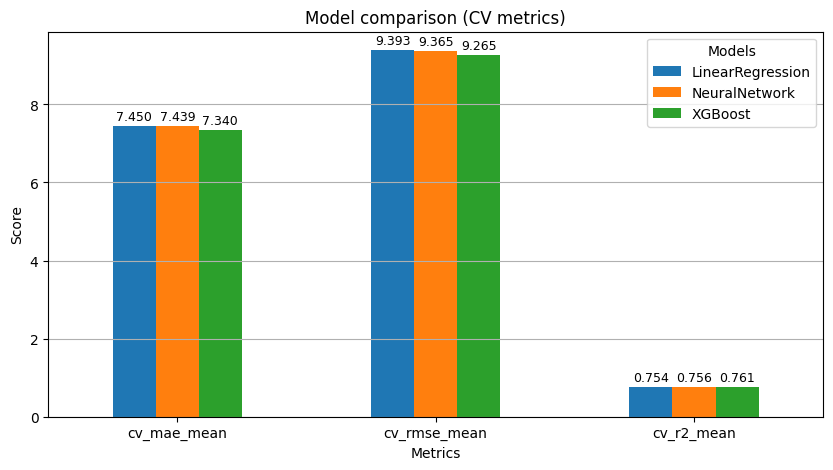

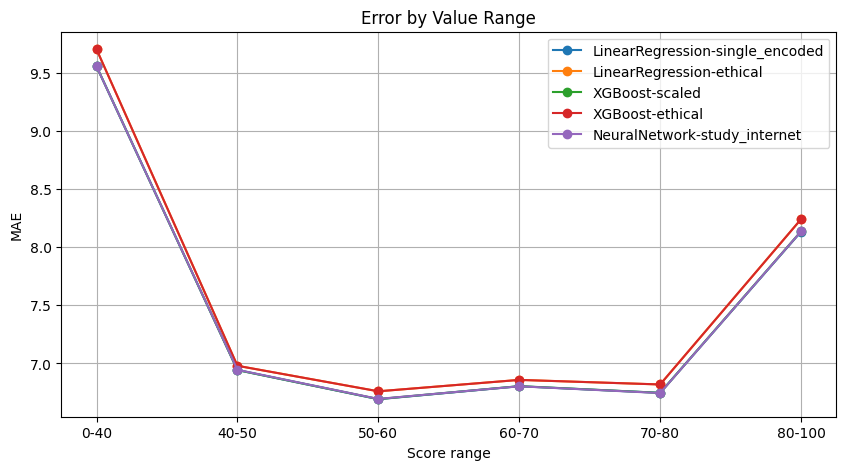

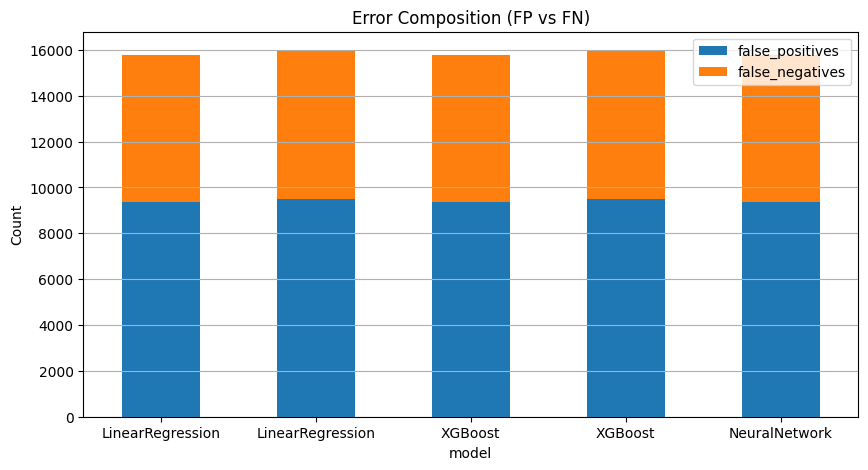

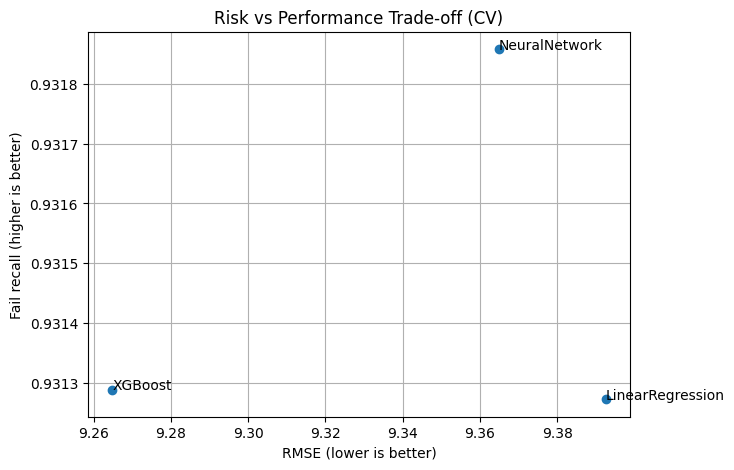

In [72]:
# -------------- PLOTS ----------------

# Plot MAE, RMSE, R2
metrics = ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"]
df_plot = comparison_df.groupby(["model"])[metrics].mean().T
ax = df_plot.plot(kind="bar", figsize=(10,5))
plt.title("Model comparison (CV metrics)")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Models")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
plt.show()



# Overfitting
# df_overfit = comparison_df.groupby("model")[["train_r2", "valid_r2"]].mean()
# ax = df_overfit.plot(kind="bar", figsize=(10,5))
# plt.title("Train vs Validation R² (Overfitting check)")
# plt.xticks(rotation=0)
# plt.grid(axis="y")
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
# plt.show()

# 


# Critical Zone error
plt.figure(figsize=(10,5))
plotted = False
for model_name in model_analysis.keys():
    for dataset_name in model_analysis[model_name]:
        block = model_analysis[model_name][dataset_name]
        if "error_by_range" in block and block["error_by_range"] is not None:
            data = block["error_by_range"]
            if len(data) > 0:
                plt.plot(
                    data.index.astype(str),
                    data.values,
                    marker="o",
                    label=f"{model_name}-{dataset_name}"
                )
                plotted = True
if plotted:
    plt.title("Error by Value Range")
    plt.xlabel("Score range")
    plt.ylabel("MAE")
    plt.grid()
    plt.legend()
    plt.show()
else:
    print("No error_by_range data found")





# Failure detection performance
df_plot = comparison_df.copy()

df_plot = df_plot.set_index("model")[
    ["false_positives", "false_negatives"]
]

ax = df_plot.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Error Composition (FP vs FN)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()



# Trade off
df_trade = comparison_df.groupby("model")[["cv_r2_mean", "cv_rmse_mean", "fail_recall"]].mean()
plt.figure(figsize=(7,5))
plt.scatter(
    df_trade["cv_rmse_mean"],
    df_trade["fail_recall"]
)
for i, txt in enumerate(df_trade.index):
    plt.annotate(txt, (df_trade["cv_rmse_mean"].iloc[i], df_trade["fail_recall"].iloc[i]))
plt.xlabel("RMSE (lower is better)")
plt.ylabel("Fail recall (higher is better)")
plt.title("Risk vs Performance Trade-off (CV)")
plt.grid()
plt.show()





In [73]:

# Error By value Range

# False Positives/ Negatives
#       - All models have similar performances 

# Trade off
#       - Fail recal is basically identical (All models are equally good at detecting failures)
#       - RMSE shows that XGBoost is slightly more precise
#       - “All models perform the same in safety, only differ in precision.”
#       - 
#       - 
#       - 
#       - 




#### Classification

In [74]:
# ------- CLASSIFICATION --------
rows = []

for model in bin_nn_analysis.keys():
    for ds_name in bin_nn_analysis[model].keys():
        data = bin_nn_analysis[model][ds_name]
        row = {
            "model": model,
            "dataset": ds_name,

            # core classification metrics
            "accuracy": data.get("accuracy"),
            "false_positives": data.get("false_positives"),
            "false_negatives": data.get("false_negatives"),

            # optional derived metric (VERY useful)
            "total_errors": data.get("false_positives", 0) + data.get("false_negatives", 0),
        }
        # add hyperparameters separately (clean separation)
        hyperparams = {
            k: v for k, v in data.items()
            if k not in ["accuracy", "false_positives", "false_negatives"]
        }

        row.update(hyperparams)

        rows.append(row)

bin_comparison_df = pd.DataFrame(rows)

cols_to_drop = [
    "units_0", "dropout_0", "lr",
    "units_1", "dropout_1",
    "units_2", "dropout_2",
    "units_3", "dropout_3",
    "units_4", "dropout_4",
    "units_5", "dropout_5",
    "tuner/epochs",
    "tuner/initial_epoch",
    "tuner/bracket",
    "tuner/round",
    "tuner/trial_id"
]

bin_comparison_df = bin_comparison_df.drop(columns=cols_to_drop, errors="ignore")


bin_comparison_df = bin_comparison_df.sort_values(
    ["accuracy", "total_errors"],
    ascending=[False, True]
)
pretty_names = {
    "accuracy": "Accuracy",
    "false_positives": "FP",
    "false_negatives": "FN",
    "total_errors": "Total Errors"
}

display_df = bin_comparison_df.rename(columns=pretty_names)

numeric_cols = display_df.select_dtypes(include="number").columns

display(
    display_df.style.format(
        subset=numeric_cols,
        formatter="{:.4f}"
    )
)


# ------ Prepare for plotting --------
# bin_plot_df = bin_comparison_df.copy()

# # map binary metrics into "CV-like" space
# bin_plot_df["cv_r2_mean"] = bin_plot_df["accuracy"]   # proxy
# bin_plot_df["cv_rmse_mean"] = bin_plot_df["total_errors"]  # proxy cost
# bin_plot_df["fail_recall"] = (
#     bin_plot_df["false_negatives"] /
#     (bin_plot_df["false_negatives"] + bin_plot_df["false_positives"] + 1e-9)
# )

# reg_plot_df = comparison_df.copy()

# # add binary model tag
# bin_plot_df["model"] = "NeuralNetwork_Binary"

# plot_df = pd.concat([reg_plot_df, bin_plot_df], ignore_index=True)

# #overfitting


print(dataset.keys())


,model,dataset,Accuracy,FP,FN,Total Errors,num_layers
1,NeuralNetwork_Binary,scaled,0.8743,9436.0000,6396.0000,15832.0000,6.0000
0,NeuralNetwork_Binary,ratio_study_sleep,0.8742,8608.0000,7249.0000,15857.0000,3.0000


dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])


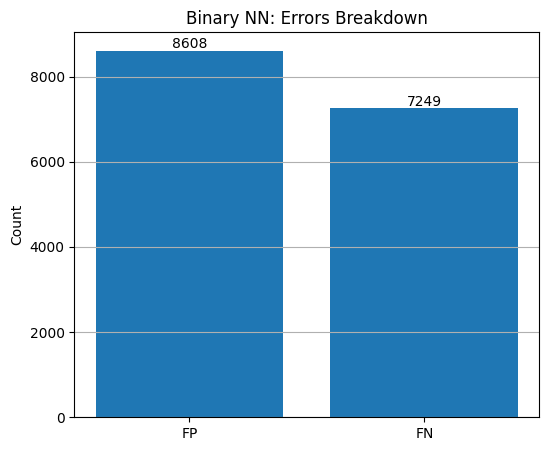

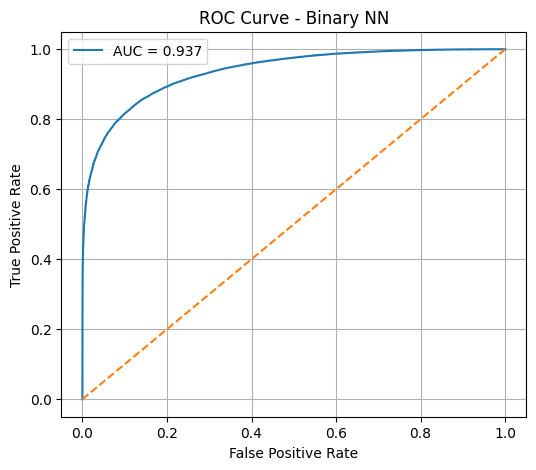

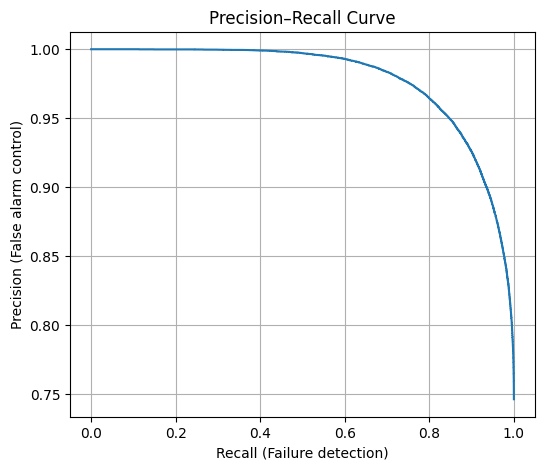

In [75]:
# -------------- PLOTS ----------------

nn = bin_NN_results["ratio_study_sleep"]["res"]

y_true = nn["y_true"]
y_prob = nn["y_prob"]
y_pred = nn["y_pred"]



import matplotlib.pyplot as plt

fp = np.sum((y_pred == 1) & (y_true == 0))
fn = np.sum((y_pred == 0) & (y_true == 1))
tp = np.sum((y_pred == 1) & (y_true == 1))
tn = np.sum((y_pred == 0) & (y_true == 0))

plt.figure(figsize=(6,5))

plt.bar(["FP", "FN"], [fp, fn])
plt.title("Binary NN: Errors Breakdown")
plt.ylabel("Count")
plt.grid(axis="y")

for i, v in enumerate([fp, fn]):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.show()


from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")

plt.title("ROC Curve - Binary NN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()



from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.title("Precision–Recall Curve")
plt.xlabel("Recall (Failure detection)")
plt.ylabel("Precision (False alarm control)")
plt.grid()

plt.show()






In [76]:
print(dataset.keys())

dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])


Which model you keep
Why it wins overall
What trade-offs it has

## ---

## 8. Advanced AI Lab Topics

### Intro

- Security: how a student could manipulate inputs
- Bias: sensitive variable check, fairness metric, mitigation
- Explainability: SHAP/LIME-style single prediction explanation

- Security: Some of the data used for failure prediction is provided by the students themselves. Could
a dishonest student lie about certain variables in order to obtain additional tutoring, even if they are
not among the most in need? Try to put yourself in the place of such a student and determine how
one could manipulate the inputs while changing as little information as possible. Is there a risk for the
OCR part?

- Bias: The dataset contains several variables. If sensitive variables are used, how do they affect the
model? Do they introduce unwanted bias? If so, you should evaluate this bias and apply techniques
to mitigate it while trying to maintain the best possible performance.
- Explainability: In the interest of transparency, a school may wish to explain to a student the factors
that made them eligible for special support. We ask you to provide an explanation based on which
and how much input variables influenced the decision. At the same time, and from a more scientific
perspective, a teacher interested in the OCR model would like to know which parts of the image are
used to predict the character. Could you provide such an explanation?



To respond to these aspects you have to submit a 5 page report supplement

Security / manipulation risk
Bias / fairness
Explainability
Keep this as a final applied discussion section

In [77]:
# Subjects seen in class : 
#
#   1. Security : how a student could manipulate inputs
#   - CIA
#   - Model Evasion
#   - Data Poisoning
#   - Model Poisoning
#   - Membership Inference and Data Leak
#   - Prompt Injection Attack
#   - 
# 
#   2. Bias :
#   - bias in our data collection ?
#   - Temporal or historical bias
#   - Representation Bias :
#   - Imbalace in the dataset 
#   - Conceptual Drift
#   - Measurement bias : would we benefit by using proxies ?
#   - Does our model confuses correlation vs causality ?
#   - Any hidden intermediate variable and common causality ?
#   - Aggregation Bias :
#   - Learning Bias : 
#   - Evaluation Bias : 
#   - Deployement Bias :
#   - Automation Bias : how much should we blindly trust the ai we just develloped ? what are the risks ?
#   - Measuring Fairness : use Prevalence, accuracy, True positive rate and precision. Same prevalence : (TP+FN)/(TP+FN+FP+TN) => Demographic parity / staistical parity. Same accuracy : (TP+TN)/(TP+FN+FP+TN) =>Equal accuracy. Same true positive rate (sensitivity/recall) : TP/(TP+FN) => Equal Opportunity.
#   - How to mitigate bias - pre-process : should we remove feature that are realted to sources of bias ? if we do will it reduce bias and is it possible to remove it totally if the removed feature is correlated wth other features. intead of removing it, could we use that feature to fight bias ?
#   - How to mitigate bias - pre-process : Disparact Impact remover is a technique that edits values from bias features. analyze how much it affects performance. 
#   - How to mitigate bias - pre-process : Resampling
#   - How to mitigate bias - in-process : class dependent loss or regularization
#   - How to mitigate bias - post-process : Per group-threshold
#   - 
#
#   3. Explainable AI (xAI) :
#   - Goal : xAi is important to understand how our model actually works, better feature engineering, find bugs and bias, help dirct future data collection, improve informed human decision making and build trust.
#   - Saliency Map ?
#   - Integrated Gradient : to nderstand what features ad the most impact on the prediction. Start from a neutral input (e.g., black image) and move toward the real input, tracking how each pixel changes the output.
#   - Activation Maximization : starting from random noise (or zero-state) maximize the classification features to understand how our AI sees/consider its comparison object. Start with noise and perform gradient ascent to create an image that maximizes the model’s confidence for a specific class.
#   - LIME : if Integ.Grad is udes to explain one decision, Act.Max to explain the model globally, Lime is used to explain it locally.
#   - Feature Permutation : “If Iin randomly shuffle (permute) this feature’s values, breaking its relationship with the target, how much does the model’s performance drop?”. The larger the drop, the more the model relied on that feature. 
#   - Partial Dependency Plot : Vary a feature across the whole dataset and track the average model output. A PDP shows the average relationship between one or two features and the model’s predictions, after “averaging out” the effects of all other features. It answers the question: “Holding everything else constant on average, how does the predicted outcome change when I adjust the feature(s) of interest?”. For example, a PDP for age in a health‑risk model might show that predicted risk increases steadily until age 60 and then plateaus, revealing the shape of the effect beyond a single importance number. 
#   - SHAP value and marginal contributions : Measure the actual contribution of each feature. Try out every group possibe, and see if by adding/rremoving a specific feature it changes the loss (gives out a percentage value ?) 
#   -
#   -
#   -
#   -

# Additionnal :
#   - try mi score between genre and other features (not just target)
#   - try permutation Importance (see slides) to confirm which features have great impact or not.
#   - 
#   - 
#   - 
# 
# 
# 
# 






In [78]:
print(dataset.keys())

dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])


### 1. Security

Our input features split into self‑reported vs verified. Self‑reported variables include heures_etude, heures_fête, heures_sommeil, méthode_etude, and potentially accès_internet; these can be easily manipulated by students. Verified variables include assiduité_classe (attendance records), and possibly administrative fields such as diplôme or school evaluations. The attack surface is therefore the set of self‑reported fields that directly influence predicted score and the 50% support decision.

From a CIA perspective, Integrity is the main risk: a student can perform model evasion by slightly lowering or changing self‑reported inputs to get flagged for extra tutoring. Confidentiality becomes relevant if predictions or training data can be queried (membership inference or data leak), but this is secondary unless privacy is explicitly required. Availability is less critical in this context.


Mitigation candidates include simple, realistic controls: logging and auditing suspicious edits, consistency checks between related variables (e.g., study hours vs attendance), requiring proof for some self‑reported inputs, and routing low‑confidence or borderline predictions to manual review. This keeps the system usable while reducing manipulation risk.


In [79]:
# which features are self‑reported vs verified ? define our attack surface.
# 
# CIA
# Model Evasion : “student manipulates inputs.”
# briefly : Membership Inference / Data Leak if privacy is a requirement
# 
# Mitigation candiates : simple, realistic controls (audit logs, consistency checks, require proof for some inputs, review low‑confidence cases).

In [80]:
# Raw Data
X_VALID_RAW = dataset["raw"]["X_valid"]

# Linear Regression
LG_MODEL_SG = model_trained["LinearRegression"]["single_encoded"]
LG_MODEL_ET = model_trained["LinearRegression"]["ethical"]

# XGBoost
XG_MODEL_ET = model_trained["XGBoost"]["scaled"]


### 2. Bias and Fairness

In [81]:
# Data collection bias / Representation bias / Imbalance
# Temporal bias / Concept drift : briefly to discuss future performance
# Measurement bias / Proxy bias : self‑reported variables → strong risk.
# Aggregation Bias : will this model fit other universities in other countries ? 
# Learning Bias ?
# Evaluation Bias : does metrics differs by group ? (how is it different than historical bias ?)
# Deployement Bias : convene with the administration to sharpen the goal, what type of help to what type of students ?
# Automation Bias : how much should the school rely on this model ?
# 
# Fairness Metrics :
#   - Demographic parity (positive rate)
#   - Equal opportunity (TPR for “fail” class)
#   - Accuracy by group (optional)
# 
# Bias Mitigation :
#   - Pre‑process: drop genre and compare
#   - In-process : ?
#   - Post‑process: group‑specific threshold


# 
# 

#### Bias sources

In the previous report, we found that genre feature has a surprisingly high MI score, this indicates the target (score_examen) differs by gender. 
This is not bias per se, but it suggests that if one gender is under‑represented, the model may learn patterns less reliably for that group
The Boxplot of score_examen by gender Shows the distribution of actual scores, there is a slight female advantage in terms of the median and the spread.
The MAE between gender (female: 8.727, male: 8.711) are almost identical,  That’s good for equal accuracy, but it does not measure equal opportunity (whether false negative rates differ) or demographic parity (whether the proportion flagged for tutoring differs)
Are some groups under‑represented in the training set relative to the real population?


In [82]:
# Describe dataset imbalance if any, show it with some graphs.
# Risk: under‑represented groups → unstable performance

import pandas as pd

# ----------------------------------------

# 1 - Counts and proportions per gender
# 2 – Pass rate by gender (Check if the imbalance affects the target distribution)
# 3. Mean study hours by gender
# 4. distribution of diplôme by gender

# ----------------------------------------

def create_bias_dataframe(raw_data, dataset_name="raw"):
    """
    Creates a DataFrame with bias metrics per gender.
    Returns a DataFrame where rows are (dataset, genre) and columns are metrics.
    """
    # Prepare data
    df = raw_data.copy()
    df['pass'] = (df['score_examen'] >= 50).astype(int)
    
    # Group by genre and aggregate
    agg = df.groupby('genre').agg(
        count=('genre', 'count'),
        mean_score=('score_examen', 'mean'),
        median_score=('score_examen', 'median'),
        pass_rate=('pass', 'mean'),
        mean_study_hours=('heures_etude', 'mean')
    ).reset_index()
    
    # Add proportion
    total = agg['count'].sum()
    agg['proportion'] = agg['count'] / total
    
    # Add dataset name
    agg['dataset'] = dataset_name
    
    # Add diploma distribution (normalised by gender)
    diploma_pivot = pd.crosstab(df['genre'], df['diplôme'], normalize='index').reset_index()
    # Rename diploma columns to avoid spaces
    diploma_pivot.columns = ['genre'] + [f"diploma_{col.replace(' ', '_')}" for col in diploma_pivot.columns[1:]]
    
    # Merge
    bias_df = agg.merge(diploma_pivot, on='genre', how='left')
    
    # Reorder columns to put dataset first
    cols = ['dataset', 'genre', 'count', 'proportion', 'mean_score', 'median_score', 
            'pass_rate', 'mean_study_hours'] + [c for c in bias_df.columns if c.startswith('diploma_')]
    bias_df = bias_df[cols]
    
    return bias_df

# Create the DataFrame for your raw dataset
bias_df = create_bias_dataframe(raw_data, dataset_name="raw")

# Display it
from IPython.display import display
display(bias_df)

,dataset,genre,count,proportion,mean_score,median_score,pass_rate,mean_study_hours,diploma_Bachelor_of_Arts,diploma_Business_Administration,diploma_Business_Management,diploma_Computer_Science,diploma_Engineering,diploma_Law,diploma_Marketing
0,raw,female,264338,0.419584,65.036548,65.17,0.771682,3.991174,0.145393,0.128775,0.161104,0.105501,0.109224,0.098208,0.251795
1,raw,male,365662,0.580416,62.228632,62.40,0.724527,4.011165,0.064420,0.113777,0.126168,0.228807,0.279942,0.065536,0.121350



Observations :
- There is a Gender representation imbalance (60-40 in favor of the male population). Which poses a representation bias concern.
- Study hours by gender (almost equal around 4h) : Differences in heures_etude (the strongest predictor) are negligible. Therefore, any difference in predicted scores between genders is unlikely to come from self‑reported study time; it must come from other features (e.g., diploma, attendance, etc.).
- 
- Diplome : Significant gender segregation by diploma. For instance, Computer Science and Engineering are dominated by males; Marketing and Arts by females. If datasets uses this feature as predictor, This is a form of proxy bias (or measurement bias).
- 
- 


Data collection / Representation	Certain groups are over‑ or under‑represented in the training data.	Male students: 58%, female: 42% → potential instability for female predictions.
Temporal / Concept drift	Relationships between features and outcome change over time.	Student study habits may shift after a policy change (e.g., new grading system).
Measurement / Proxy	Self‑reported features are inaccurate; some variables correlate with sensitive attributes.	diplôme proxies gender (male → CS/Eng, female → Arts/Marketing).
Aggregation	Model trained on one population may not generalise to another.	Our school’s data may not represent a university in a different country.
Learning bias	The algorithm favours patterns that are dominant in the training set.	Linear regression minimises MSE globally, which may ignore minority group errors.
Evaluation bias	The metrics used (e.g., overall accuracy) hide disparities across groups.	Model has similar accuracy for males/females but different recall (TPR).
Deployment bias	The way the model is used conflicts with the true goal.	Flagging “fail” may not be the only criterion; tutoring could also benefit borderline students.
Automation bias	Humans over‑trust the model and skip manual checks.	Teachers may stop reviewing flagged students, missing edge cases the model fails on.

#### Fairness Metrics (Quantitative)

In [83]:
print(dataset.keys())

dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled'])


In [84]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def evaluate_fairness(predictions, y_true, group_labels, threshold=50):
    """
    Evaluate binary fairness metrics across groups.
    
    Parameters
    ----------
    predictions : array-like
        Continuous predicted scores (e.g., from regression).
    y_true : array-like
        True continuous scores (or binary). Function binarizes at threshold.
    group_labels : array-like or pandas Series
        Group membership for each sample (e.g., 'female', 'male').
    threshold : float, default=50
        Threshold to binarize both predictions and true scores.
    
    Returns
    -------
    fairness_df : pd.DataFrame
        Per‑group metrics: TP, FP, TN, FN, count, positive_rate, tpr, fnr, fpr, accuracy.
    gaps_df : pd.DataFrame
        Absolute differences between groups for demographic parity, equal opportunity, and FNR.
    """
    # Binarize
    y_pred_binary = (np.array(predictions) < threshold).astype(int)
    y_true_binary = (np.array(y_true) < threshold).astype(int)
    
    # Ensure group_labels is a pandas Series for easy grouping
    if not isinstance(group_labels, pd.Series):
        group_labels = pd.Series(group_labels)
    
    unique_groups = group_labels.unique()
    rows = []
    
    for g in unique_groups:
        mask = (group_labels == g)
        tn, fp, fn, tp = confusion_matrix(
            y_true_binary[mask], 
            y_pred_binary[mask]
        ).ravel()
        total = tp + fp + tn + fn
        
        rows.append({
            'group': g,
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn,
            'count': total,
            'positive_rate': (tp + fp) / total if total > 0 else 0,
            'tpr': tp / (tp + fn) if (tp + fn) > 0 else 0,
            'fnr': fn / (tp + fn) if (tp + fn) > 0 else 0,
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'accuracy': (tp + tn) / total if total > 0 else 0
        })
    
    fairness_df = pd.DataFrame(rows)
    
    # If exactly two groups, compute gaps; otherwise return only per‑group
    if len(unique_groups) == 2:
        group_a = fairness_df.iloc[0]
        group_b = fairness_df.iloc[1]
        gaps_df = pd.DataFrame({
            'metric': ['demographic_parity_diff', 'equal_opportunity_diff', 'fnr_diff'],
            'value': [
                abs(group_a['positive_rate'] - group_b['positive_rate']),
                abs(group_a['tpr'] - group_b['tpr']),
                abs(group_a['fnr'] - group_b['fnr'])
            ]
        })
    else:
        gaps_df = None
    
    return fairness_df, gaps_df

# ============================================================================
# USAGE EXAMPLE 1: single_encoded dataset (with gender in training)
predictions_single = LG_MODEL_SG["preds"]
X_valid_raw = X_VALID_RAW
gender = X_valid_raw["genre"]

fairness_df, gaps_df = evaluate_fairness(predictions_single, y_valid, gender, threshold=50)
print("=== Per‑gender fairness (single_encoded) ===")
display(fairness_df)
print("\n=== Fairness gaps ===")
display(gaps_df)

# USAGE EXAMPLE 2: ethical dataset (gender dropped from training)
predictions_ethical = LG_MODEL_ET["preds"]
fairness_df_ethical, gaps_df_ethical = evaluate_fairness(predictions_ethical, y_valid, gender, threshold=50)
print("\n=== Per‑gender fairness (ethical, gender not used in training) ===")
display(fairness_df_ethical)
print("\n=== Fairness gaps after removing gender ===")
display(gaps_df_ethical)

=== Per‑gender fairness (single_encoded) ===


,group,TP,FP,TN,FN,count,positive_rate,tpr,fnr,fpr,accuracy
0,male,14629,3884,49162,5402,73077,0.253336,0.730318,0.269682,0.073219,0.872929
1,female,8022,2525,38409,3967,52923,0.199290,0.669113,0.330887,0.061685,0.877331



=== Fairness gaps ===


,metric,value
0,demographic_parity_diff,0.054046
1,equal_opportunity_diff,0.061205
2,fnr_diff,0.061205



=== Per‑gender fairness (ethical, gender not used in training) ===


,group,TP,FP,TN,FN,count,positive_rate,tpr,fnr,fpr,accuracy
0,male,13841,3236,49810,6190,73077,0.233685,0.690979,0.309021,0.061004,0.871013
1,female,8693,3273,37661,3296,52923,0.226102,0.725081,0.274919,0.079958,0.875876



=== Fairness gaps after removing gender ===


,metric,value
0,demographic_parity_diff,0.007583
1,equal_opportunity_diff,0.034102
2,fnr_diff,0.034102




Metric	Female	Male	Gap (Female – Male)	Interpretation
Count (proportion)	52,923 (42.0%)	73,077 (58.0%)	–16.0%	Representation bias: males are over‑represented. Under‑represented groups (females) may have less stable estimates.
Positive rate (predicted fail)	19.9%	25.3%	–5.4 pp	Demographic parity difference = 0.054. Males are more likely to be flagged for tutoring, even though – as we will check – the true fail rate might differ.
True Positive Rate (TPR, recall for fail)	66.9%	73.0%	–6.1 pp	Equal opportunity difference = 0.061. The model catches failing male students at a significantly higher rate than failing female students.
False Negative Rate (FNR)	33.1%	27.0%	+6.1 pp	Female students who actually fail are 6.1 percentage points more likely to be missed (not offered tutoring).
False Positive Rate (FPR)	6.2%	7.3%	–1.1 pp	Small difference – the model does not disproportionately label passing females as failing.
Accuracy	87.73%	87.29%	+0.44 pp	Overall accuracy is almost equal across genders. This hides the disparity in TPR/FNR.



Observtion :
Unfairness Toward Failing Female Students
Despite similar average study hours (~4h for both genders) and similar overall accuracy, the model systematically under‑identifies failing female students (higher FNR). This means that a female student who actually fails has a ~33% chance of being denied tutoring, while a male student in the same situation has only a ~27% chance.


Why does this happen? (Root Cause Hypothesis)
From the earlier raw data summary, we observed strong gender segregation by diploma:

Male‑dominated diplomas: Computer Science, Engineering

Female‑dominated diplomas: Marketing, Arts, Law

If diplôme is a predictor (and it is, as part of the encoding), then the model may have learned that certain diplomas are associated with lower failure risk, but those diplomas happen to have more female students. Combined with potential differences in assiduité_classe, méthode_etude, or heures_fête (which may correlate with gender due to social or cultural factors), the model indirectly uses gender as a proxy – even if genre itself is included or excluded.



“Removing the genre feature from training reduced the demographic parity gap from 5.4% to 0.8%, indicating that the model no longer predicts failure at substantially different rates for male and female students. However, a 3.4% gap in true positive rate (recall for failing students) remained, suggesting that other features (e.g., diplôme, méthode_etude) still act as proxies for gender. To address this, we recommend applying group‑specific decision thresholds (post‑processing) to equalize recall across genders, or reweighting the training data to balance the representation of failing female students.”









#### Mitigation Experiments : 

In [85]:
# 1. Pre-processing : 
#   - Drop genre (already done in previous report, analyze and discuss results)


# Reduces dem. parity gap from 5.4% → 0.8%; 
# Impact on fairness : reduces equal opportunity gap from 6.1% → 3.4%	
# Accuracy trade‑off : Minimal (R² 0.7569 → 0.7518)



In [86]:
# 2. In-processing :
#   - optionnal ? : class‑weighted loss or regularization

In [87]:
# 3. Post-processing :
#   - Group‑specific threshold to reduce FN for vulnerable group

Conclusion :
- Is bias observed? How large?
- Which mitigation is feasible without hurting MAE too much?
- Recommendation for deployment


### 3. Explainable AI (xAI)

Transparency is essential for both students (who may want to understand why they were flagged for tutoring) and teachers (who need to trust the model’s behaviour). We provide three complementary explanations: global feature importance (permutation importance), local single‑prediction explanation (using SHAP), and partial dependence plots to visualise how key features affect the predicted exam score.

#### Permutation Importance

Permutation importance measures the drop in model performance (here, R²) when a feature’s values are randomly shuffled, breaking its relationship with the target. A larger drop indicates higher importance.

We used eli5’s PermutationImportance on the final linear regression model (single_encoded dataset) with 10 repetitions. 

In [88]:
import eli5
from eli5.sklearn import PermutationImportance


# Linear Regression
model_lg = LG_MODEL_SG["model"]   # SINGLE Encoded dataset
X_valid_lg = dataset["single_encoded"]["X_valid"]
feature_names_lg = dataset["single_encoded"]["feature_names"]



perm = PermutationImportance(model_lg, random_state=1).fit(X_valid_lg, y_valid)
eli5.show_weights(perm, feature_names = feature_names_lg)


Weight,Feature
0.9675 ± 0.0031,num__heures_etude
0.1669 ± 0.0020,num__assiduité_classe
0.0295 ± 0.0007,num__heures_sommeil
0.0258 ± 0.0008,ord__qualité_sommeil_poor
0.0240 ± 0.0004,ord__qualité_sommeil_good
0.0225 ± 0.0003,nom__méthode_etude_coaching
0.0163 ± 0.0006,ord__évaluation_établissement_low
0.0157 ± 0.0004,ord__évaluation_établissement_high
0.0078 ± 0.0003,nom__méthode_etude_self-study
0.0038 ± 0.0001,nom__méthode_etude_online videos


- Study hours dominate the prediction. Shuffling this feature crashes R² from 0.757 to near zero (or negative).

- Class attendance is the second most important factor, but an order of magnitude less than study hours.

- Gender (directly included) has virtually no global importance, confirming that the model does not rely on it for predictions (which aligns with the fairness analysis).

heures_etude is the single most actionable lever. Increasing study hours from 2 to 8 per week dramatically raises predicted scores.

assiduité_classe (attendance) is also very influential – interventions that improve attendance will help.

Study method, sleep quality, and prior institutional evaluation matter, but much less.



- “Why low feature importance does not imply fairness” :
“At first glance, the permutation importance of genre appears negligible (ΔR² ≈ 0.003), suggesting that gender does not help predict exam scores. However, fairness metrics reveal a 6.1% gap in recall for failing female students. This is not a contradiction: low feature importance means gender adds little unique predictive value beyond other features, but those other features (e.g., diplôme, méthode_etude, heures_fête) may themselves be correlated with gender, creating indirect discrimination. Removing genre from the model reduced the gap to 3.4% but did not eliminate it, confirming that proxy biases persist. Therefore, fairness assessment must go beyond feature importance – we must directly measure group‑wise disparities.”



#### Partial Depenendency Plots

Partial Dependence Plots (PDP) show how a feature affects the predicted outcome on average, while accounting for the average effects of all other features.

Here PDPs can help teachers and administrators understand how changes in student behaviours (e.g., study hours, attendance) change the predicted exam score, and therefore the likelihood of being flagged for tutoring.

['num__age' 'num__heures_etude' 'num__assiduité_classe'
 'num__heures_sommeil' 'num__heures_fête' 'num__taille_etudiant'
 'bin__genre_female' 'bin__genre_male' 'bin__accès_internet_no'
 'bin__accès_internet_yes' 'ord__qualité_sommeil_average'
 'ord__qualité_sommeil_good' 'ord__qualité_sommeil_poor'
 'ord__évaluation_établissement_high' 'ord__évaluation_établissement_low'
 'ord__évaluation_établissement_medium' 'ord__difficulté_examen_easy'
 'ord__difficulté_examen_hard' 'ord__difficulté_examen_moderate'
 'nom__diplôme_Bachelor of Arts' 'nom__diplôme_Business Administration'
 'nom__diplôme_Business Management' 'nom__diplôme_Computer Science'
 'nom__diplôme_Engineering' 'nom__diplôme_Law' 'nom__diplôme_Marketing'
 'nom__méthode_etude_coaching' 'nom__méthode_etude_group study'
 'nom__méthode_etude_mixed' 'nom__méthode_etude_online videos'
 'nom__méthode_etude_self-study']


/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject

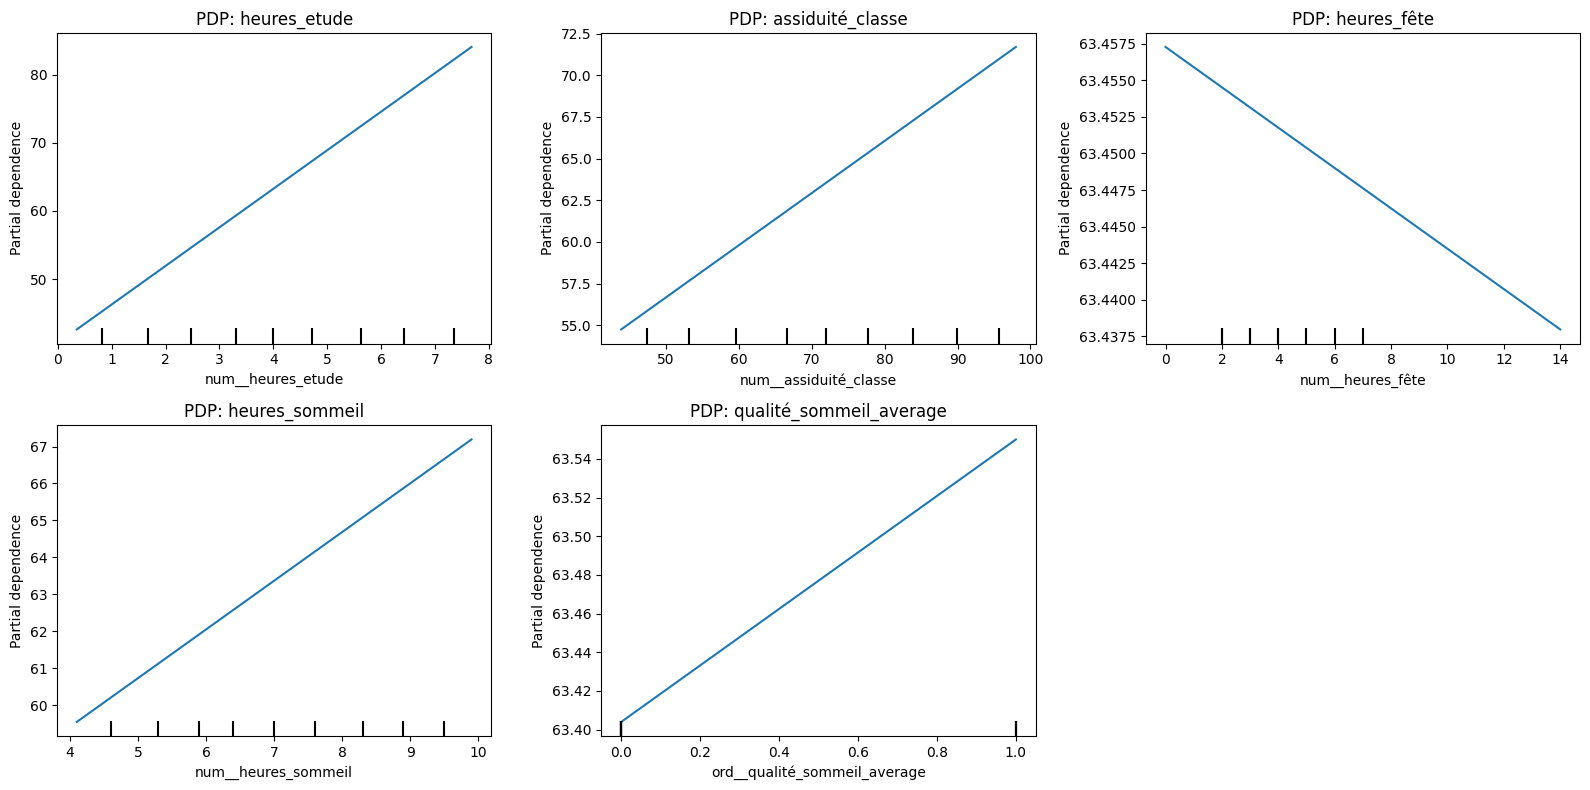

/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject

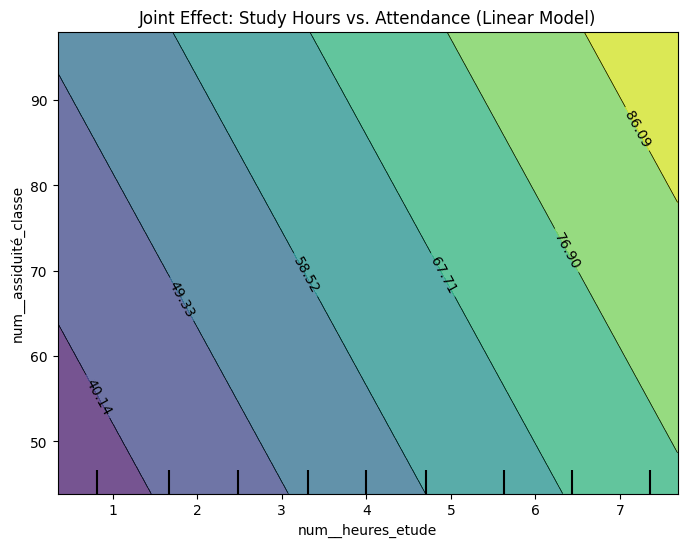

In [89]:
# -------- Linear Regression PDP ------------

from matplotlib import pyplot as plt
from sklearn.inspection import PartialDependenceDisplay


print(feature_names_lg)


X_valid = X_valid_lg
model = model_lg
feature_names = feature_names_lg

# Random Sample to speed up comput
X_sample = pd.DataFrame(X_valid, columns=feature_names).sample(n=5000, random_state=42)  # Convert to dataframe first




# 1D PDP 
features_1d = [
    'num__heures_etude',
    'num__assiduité_classe',
    'num__heures_fête',
    'num__heures_sommeil',
    'ord__qualité_sommeil_average',
    # 'ord__qualité_sommeil_good',
    # 'ord__qualité_sommeil_poor'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()  # Flatten for easy indexing

for idx, feat in enumerate(features_1d):
    # For binary/ordinal dummies, the PDP will be two points (0 and 1)
    PartialDependenceDisplay.from_estimator(
        model, X_sample, [feat],
        feature_names=feature_names, ax=axes[idx]
    )
    axes[idx].set_title(f'PDP: {feat.replace("num__", "").replace("ord__", "")}')
    axes[idx].grid(True)

# Remove any unused subplots (7 plots, we have 8 axes)
for i in range(len(features_1d), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()




# 2D PDP for interaction between study hours and attendance
fig, ax = plt.subplots(figsize=(8, 6))
features_2d = [('num__heures_etude', 'num__assiduité_classe')]
PartialDependenceDisplay.from_estimator(
    model,                    # chosen model
    X_sample,                 # sampled data
    features_2d,              # list of tuple(s) of feature names
    grid_resolution=20,       # reduce grid points (default is 20 already)
    ax=ax,
)
plt.title('Joint Effect: Study Hours vs. Attendance (Linear Model)')
plt.show()








Main insigths : 

To understand the actual impact of each feature, we look at the y-axis of partial dependence :
- Study hours covers almost the full 0-100 range : Increasing from 2 to 7 hours raises the predicted score by 30 points (from 50 to 80). That’s a large, linear effect. Each extra hour adds ≈6 points.
- Class attendance has a more narrow range (50-70): Increasing from 50% to 95% raises the predicted score by 15 points (from 55 to 70). That’s about 0.33 points per percentage point, a smaller but still important effect.
- Sleep hours is still impactfull at a 10-points range (60-67).
- The remaining graphs show very little partial dependence, with ranges not exceeding a few decimal point. Special note for party hours: it has a negative slope, meaning fewer party hours would increase the average exam score, but the PDP range is way too small for this to be a practically noticeable effect.

- The 2D PDP shows straight, parallel contour lines – expected for a linear model without interactions. The predicted exam score increases linearly with both study hours and attendance.
-> The contours are slanted leftward because both features have positive coefficients; to achieve the same score, low study hours can be compensated by high attendance (and vice versa).
-> The passing threshold (score=50) lies between 1–3 hours when attendance is very high (95% for 1h of studying, 50% for 3h of studying).


These linear slopes match the coefficients you would get from the model (since PDP for a linear model is a straight line)

Now, running the same plots for XGBoost will be revealing:
- Non‑linearities – XGBoost may show diminishing returns for study hours (e.g., the slope becomes flat after 12 hours) or a threshold effect (e.g., attendance below 60% is very harmful).
- Interactions – XGBoost can capture that the benefit of study hours depends on attendance. That’s why a 2D PDP would be valuable.


['num__age' 'num__heures_etude' 'num__assiduité_classe'
 'num__heures_sommeil' 'num__heures_fête' 'num__taille_etudiant'
 'bin__genre' 'bin__accès_internet' 'ord__qualité_sommeil'
 'ord__évaluation_établissement' 'ord__difficulté_examen'
 'nom__diplôme_Bachelor of Arts' 'nom__diplôme_Business Administration'
 'nom__diplôme_Business Management' 'nom__diplôme_Computer Science'
 'nom__diplôme_Engineering' 'nom__diplôme_Law' 'nom__diplôme_Marketing'
 'nom__méthode_etude_coaching' 'nom__méthode_etude_group study'
 'nom__méthode_etude_mixed' 'nom__méthode_etude_online videos'
 'nom__méthode_etude_self-study']


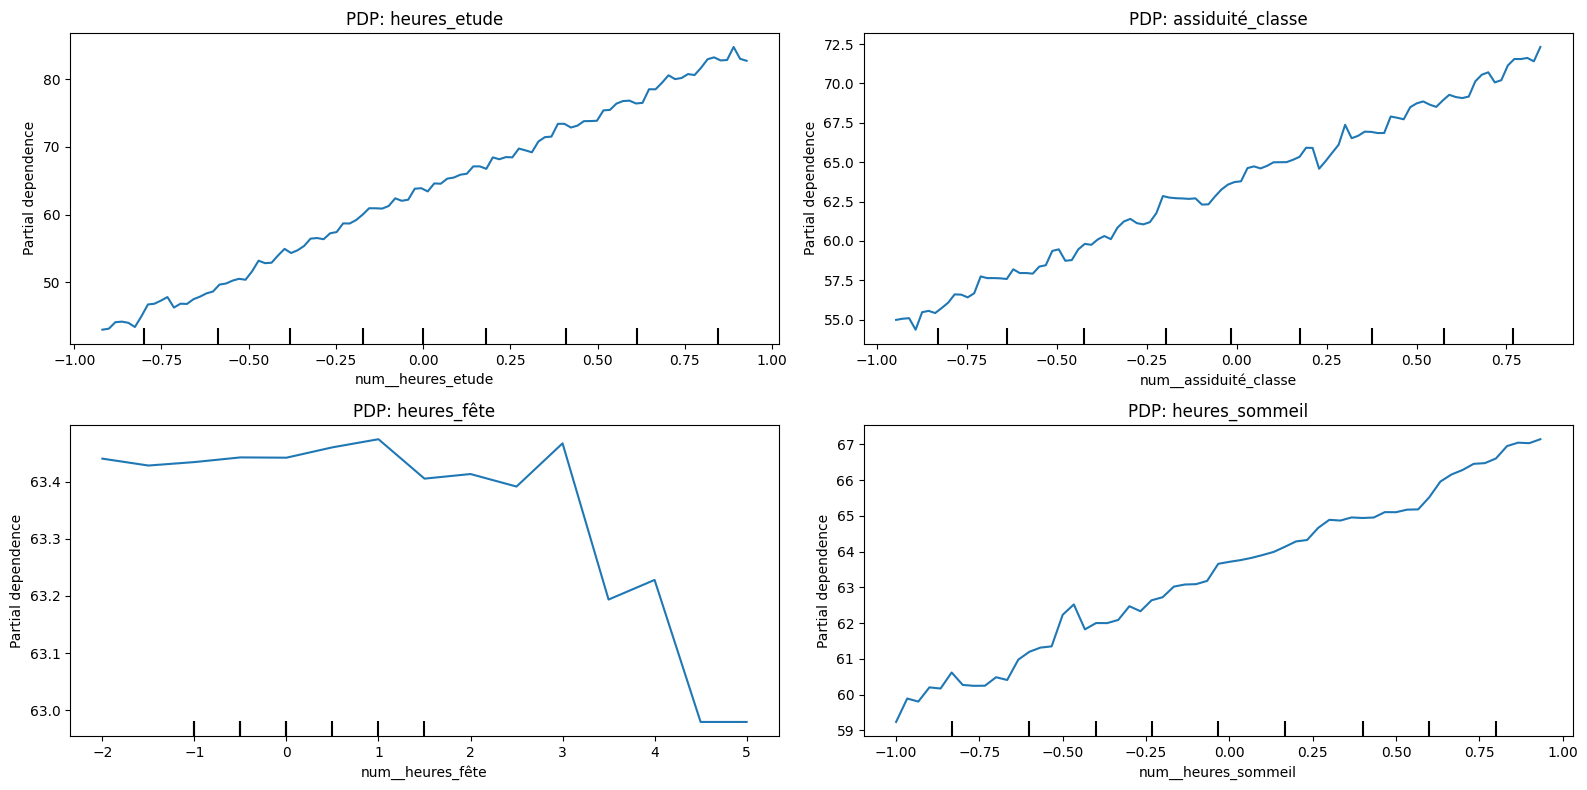

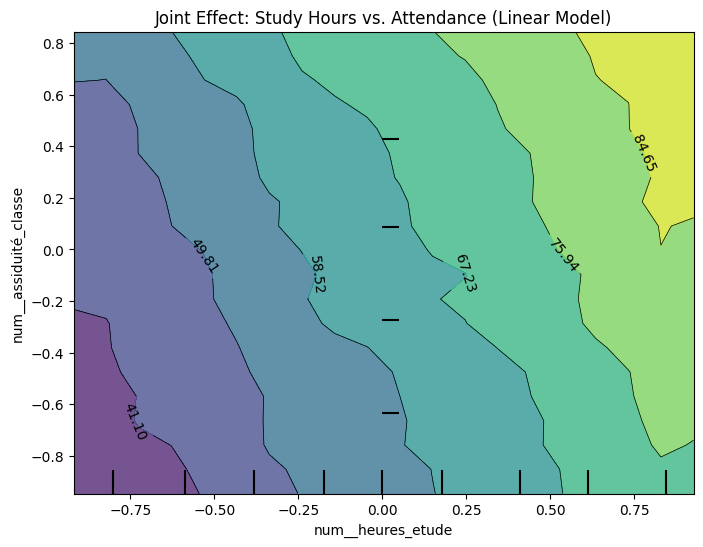

In [90]:
# --------- XGBoost --------------

# XGBoost
model_xg = XG_MODEL_ET["model"]   # Ethical dataset
X_valid_Xg = dataset["scaled"]["X_valid"]
feature_names_xg = dataset["scaled"]["feature_names"]

print(feature_names_xg)



model = model_xg
X_valid = X_valid_Xg
feature_names = feature_names_xg


# Random Sample to speed up comput
X_sample = pd.DataFrame(X_valid, columns=feature_names).sample(n=5000, random_state=42)  # Convert to dataframe first


# 1D PDP 
features_1d = [
    'num__heures_etude',
    'num__assiduité_classe',
    'num__heures_fête',
    'num__heures_sommeil',
    # 'ord__qualité_sommeil',
    # 'ord__qualité_sommeil_good',
    # 'ord__qualité_sommeil_poor'
]
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()  # Flatten for easy indexing
for idx, feat in enumerate(features_1d):
    # For binary/ordinal dummies, the PDP will be two points (0 and 1)
    PartialDependenceDisplay.from_estimator(
        model, X_sample, [feat],
        feature_names=feature_names, ax=axes[idx]
    )
    axes[idx].set_title(f'PDP: {feat.replace("num__", "").replace("ord__", "")}')
    axes[idx].grid(True)
# Remove any unused subplots (7 plots, we have 8 axes)
for i in range(len(features_1d), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()


# 2D PDP for interaction between study hours and attendance
fig, ax = plt.subplots(figsize=(8, 6))
features_2d = [('num__heures_etude', 'num__assiduité_classe')]
PartialDependenceDisplay.from_estimator(
    model,                    # chosen model
    X_sample,                 # sampled data
    features_2d,              # list of tuple(s) of feature names
    grid_resolution=20,       # reduce grid points (default is 20 already)
    ax=ax,
)
plt.title('Joint Effect: Study Hours vs. Attendance (Linear Model)')
plt.show()










We repeated the PDP analysis using the XGBoost model trained on the scaled dataset (standardised features: mean 0, variance 1). The resulting PDPs are nearly indistinguishable from the linear model’s straight lines – any curvature is minor and likely due to noise. The only noticeable deviation occurs for heures_fête, where XGBoost shows a plateau from 0 to 7 hours followed by a slight drop. However, the entire y‑axis range in that PDP is only 63.0 to 63.4, meaning the predicted score changes by less than 0.4 points across the full party‑hour range. Hence, this curvature is practically insignificant.

Note on scale differences: The absolute predicted values in the XGBoost PDPs differ from the linear model’s because XGBoost was trained on scaled data. The important observation is the shape – it is essentially linear, confirming that the linear model captures the main relationships adequately.

Conclusion: The linear model’s PDPs are sufficiently accurate for explaining the marginal effects of each feature. The additional complexity of XGBoost does not reveal any actionable non‑linearities or interactions that would justify sacrificing interpretability. Therefore, we retain the linear regression model as the final choice for the tutoring flagging system.


####  SHAP Values

To explain why a student was flagged for tutoring, we use SHAP (SHapley Additive exPlanations). SHAP values decompose a prediction into the sum of each feature’s contribution, starting from a base value (the average prediction over the training set). This provides a clear, mathematically sound explanation for any single prediction.

We apply SHAP to both our linear regression (final model) and XGBoost (best‑performing model) to compare interpretability.

SHAP for Linear Regression

For a linear model, the SHAP value for feature j is:

SHAPj = βj ⋅ (xj−E[xj])
where  βj is the coefficient and 
E[xj] is the mean of that feature in the training set. This makes SHAP values additive, consistent, and locally accurate.

In [112]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_shap_for_student(model, X_train, X_valid, y_valid, feature_names, 
                         student_idx, model_type="LinearRegression", top_n=10):
    """
    Compute and display SHAP values for a single student at given index.
    """
    # Convert to DataFrames
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_valid_df = pd.DataFrame(X_valid, columns=feature_names)
    
    # Convert y_valid to numpy array for positional indexing
    y_true = np.array(y_valid)
    
    # Get predictions for this student
    if model_type == "LinearRegression":
        pred_score = model.predict(X_valid_df.iloc[[student_idx]])[0]
        explainer = shap.LinearExplainer(model, X_train_df)
    elif model_type == "XGBoost":
        pred_score = model.predict(X_valid_df.iloc[[student_idx]])[0]
        background = X_train_df.sample(n=500, random_state=42)
        explainer = shap.TreeExplainer(model, background, 
                                       feature_perturbation="interventional",
                                       check_additivity=False)
    else:
        raise ValueError("model_type must be 'LinearRegression' or 'XGBoost'")
    
    # Compute SHAP values for this single student
    shap_values = explainer.shap_values(X_valid_df.iloc[[student_idx]])
    shap_single = shap_values[0]
    student_data = X_valid_df.iloc[student_idx]
    base_value = explainer.expected_value
    if isinstance(base_value, np.ndarray):
        base_value = base_value[0]
    
    # Build contribution table
    contrib_df = pd.DataFrame({
        'Feature': feature_names,
        'Value': student_data.values,
        'SHAP': shap_single,
        'Abs_SHAP': np.abs(shap_single)
    })
    top_contrib = contrib_df.nlargest(top_n, 'Abs_SHAP')
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"STUDENT #{student_idx} - {model_type}")
    print(f"True exam score: {y_true[student_idx]:.2f}")
    print(f"Predicted score: {pred_score:.2f}")
    print(f"Base value: {base_value:.2f}")
    print(f"Top {top_n} features by |SHAP|:\n")
    print(top_contrib[['Feature', 'Value', 'SHAP']].to_string(index=False))
    print(f"{'='*70}\n")
    
    # Waterfall plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_single,
            base_values=base_value,
            data=student_data,
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f"SHAP Explanation - {model_type} - Student #{student_idx}")
    plt.show()


def explain_critical_students(model, X_train, X_valid, y_valid, feature_names,
                              model_type="LinearRegression", top_n=10):
    """
    Automatically select and explain three types of students.
    """
    X_valid_df = pd.DataFrame(X_valid, columns=feature_names)
    if model_type == "LinearRegression":
        preds = model.predict(X_valid_df)
    else:
        preds = model.predict(X_valid_df)
    
    preds = np.array(preds)
    y_true = np.array(y_valid)
    
    # 1. Passing student (predicted around 80)
    passing_candidates = np.where((preds >= 75) & (preds <= 85) & (y_true >= 50))[0]
    if len(passing_candidates) > 0:
        passing_idx = passing_candidates[0]
    else:
        passing_idx = np.argmin(np.abs(preds - 80))
    
    # 2. Failing student (predicted around 20)
    failing_candidates = np.where((preds >= 15) & (preds <= 25) & (y_true < 50))[0]
    if len(failing_candidates) > 0:
        failing_idx = failing_candidates[0]
    else:
        failing_idx = np.argmin(np.abs(preds - 20))
    
    # 3. False negative (predicted > 50 but true < 50)
    fn_candidates = np.where((preds > 50) & (y_true < 50))[0]
    if len(fn_candidates) > 0:
        fn_idx = fn_candidates[0]
    else:
        borderline = np.where((preds >= 45) & (preds <= 55) & (y_true < 50))[0]
        fn_idx = borderline[0] if len(borderline) > 0 else None
        if fn_idx is None:
            print("Warning: No false negative or borderline failing student found.")
            return
    
    print(f"\n{'#'*70}")
    print(f"# EXPLAINING CRITICAL STUDENTS - {model_type}")
    print(f"{'#'*70}")
    
    get_shap_for_student(model, X_train, X_valid, y_valid, feature_names,
                         passing_idx, model_type, top_n)
    get_shap_for_student(model, X_train, X_valid, y_valid, feature_names,
                         failing_idx, model_type, top_n)
    get_shap_for_student(model, X_train, X_valid, y_valid, feature_names,
                         fn_idx, model_type, top_n)

/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



######################################################################
# EXPLAINING CRITICAL STUDENTS - LinearRegression
######################################################################

STUDENT #2 - LinearRegression
True exam score: 83.95
Predicted score: 75.90
Base value: 65.90
Top 10 features by |SHAP|:

                           Feature  Value      SHAP
                 num__heures_etude   7.26 15.954117
             num__assiduité_classe  50.80 -6.926213
         ord__qualité_sommeil_poor   1.00 -2.962938
ord__évaluation_établissement_high   1.00  2.713769
               num__heures_sommeil   9.30  2.712170
     nom__méthode_etude_self-study   1.00 -2.406001
         ord__qualité_sommeil_good   0.00 -1.411934
 ord__évaluation_établissement_low   0.00  1.285072
       nom__méthode_etude_coaching   0.00 -1.110585
                 bin__genre_female   1.00  0.765391



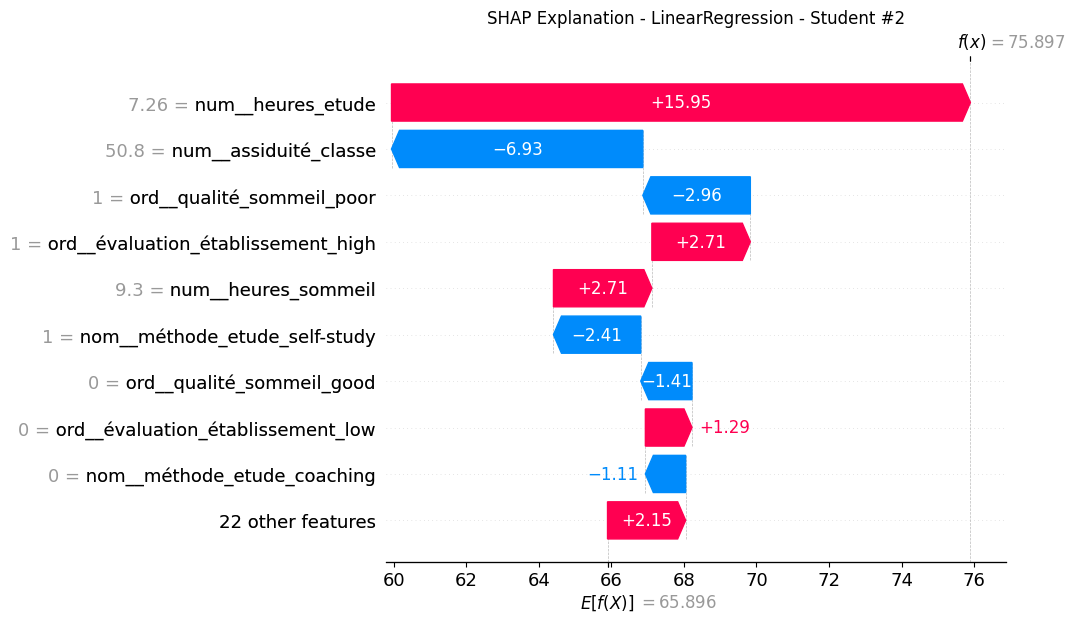


STUDENT #272 - LinearRegression
True exam score: 27.60
Predicted score: 22.76
Base value: 65.90
Top 10 features by |SHAP|:

                           Feature  Value       SHAP
                 num__heures_etude   0.08 -24.725794
             num__assiduité_classe  62.80  -3.166904
               num__heures_sommeil   4.90  -3.086445
         ord__qualité_sommeil_poor   1.00  -2.962938
     nom__méthode_etude_self-study   1.00  -2.406001
 ord__évaluation_établissement_low   1.00  -2.386562
         ord__qualité_sommeil_good   0.00  -1.411934
       nom__méthode_etude_coaching   0.00  -1.110585
ord__évaluation_établissement_high   0.00  -0.904590
                 bin__genre_female   0.00  -0.678743



/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


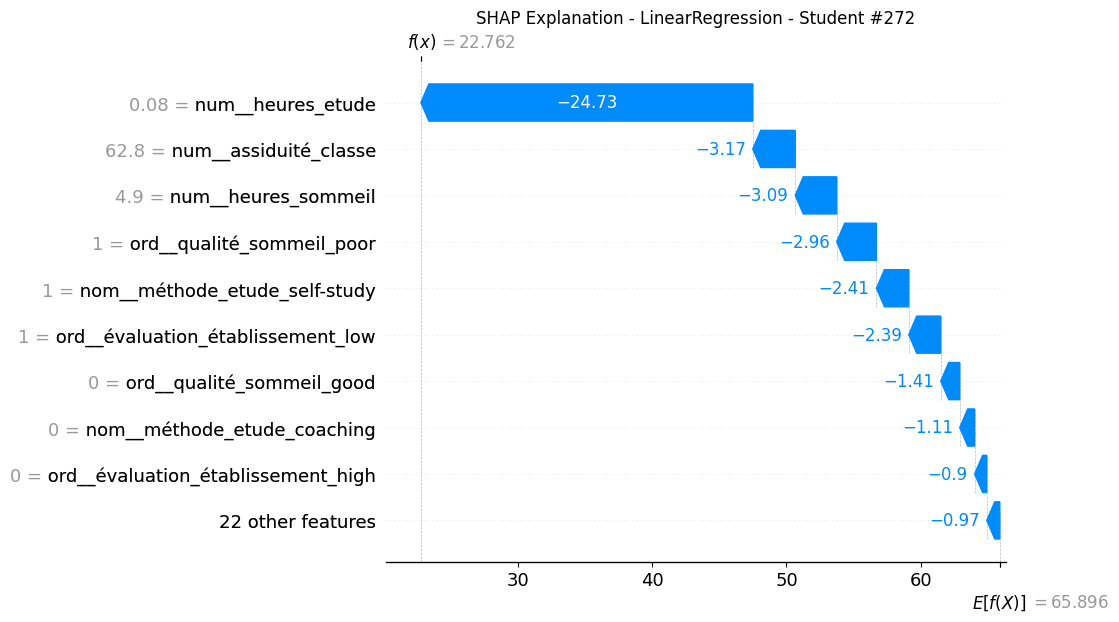


STUDENT #4 - LinearRegression
True exam score: 48.92
Predicted score: 50.49
Base value: 65.90
Top 10 features by |SHAP|:

                           Feature  Value       SHAP
                 num__heures_etude   1.24 -18.153552
             num__assiduité_classe  88.60   4.915609
               num__heures_sommeil   5.30  -2.559298
 ord__évaluation_établissement_low   1.00  -2.386562
         ord__qualité_sommeil_poor   0.00   1.595428
         ord__qualité_sommeil_good   0.00  -1.411934
          nom__méthode_etude_mixed   1.00   1.348020
       nom__méthode_etude_coaching   0.00  -1.110585
ord__évaluation_établissement_high   0.00  -0.904590
                 bin__genre_female   1.00   0.765391



/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


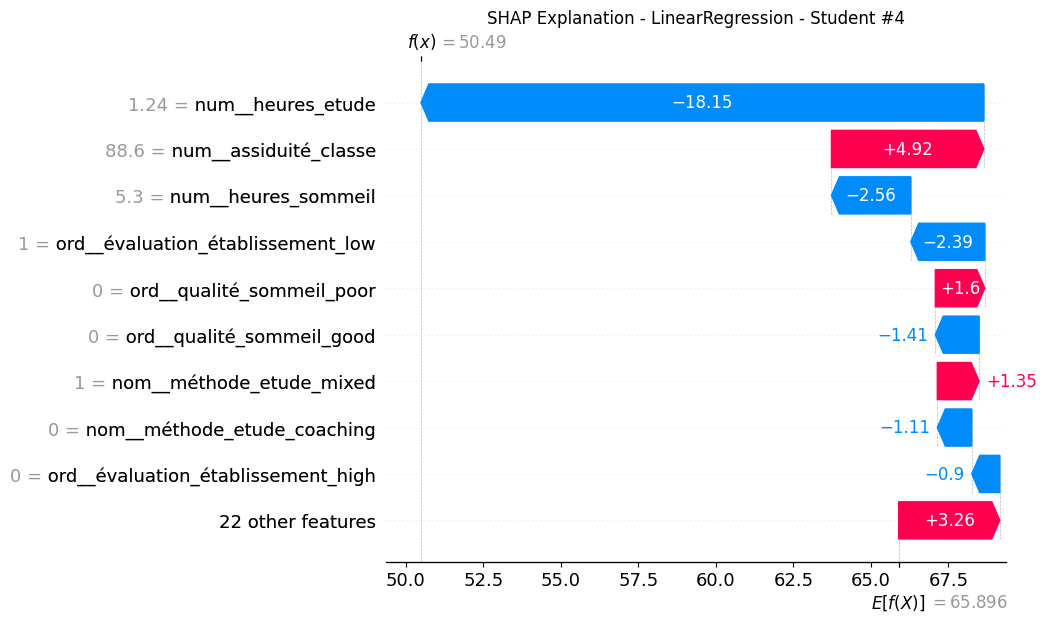

In [113]:
# For Linear Regression
X_valid = X_valid_lg
X_train = dataset["single_encoded"]["X_train"]
model = model_lg
feature_names = feature_names_lg
explain_critical_students(model, X_train, X_valid, y_valid, feature_names, model_type="LinearRegression", top_n=10)



- heures_etude : Strong negative – low study hours reduce the score significantly
- assiduité_classe : Positive – high attendance helps
- bin__accès_internet : bith encodings (yes and no versions) are complementary, we choose to only focus on the no-version but the yes-would've been the same. Here not having access to the internet has a clear -1.81 negative effect. 


Other features having a negative effect on the final exam score : qualité_sommeil_poor (poor sleep quality lowers the score), ord__qualité_sommeil_good (not having this feature has a negative effect)
Other positive features : évaluation_établissement_high (being well evaluated by your school has a positive effect), num__heures_sommeil (high sleep hours help), ...


Key takeaways
Low study hours (3.23/week) is the single biggest factor pulling the score down (‑6.88). This is actionable: increasing study time would raise the predicted score substantially.

High attendance (82.6%) provides a strong boost (+3.04), partially compensating for low study hours.

Poor sleep quality has a large negative effect (‑2.96), while actual sleep hours are high (8.3) and contribute positively (+1.39). Improving sleep quality would help.

Lack of internet access reduces the score (‑1.81), suggesting digital access may be a barrier.

Study method (mixed) and prior high evaluation are positive assets.

SHAP for XGBoost 


XGBoost is a non‑linear model; SHAP values capture complex interactions and non‑linear effects. We use shap.TreeExplainer (since XGBoost is a tree‑based model).

Base value (mean prediction on training set): 63.39
Predicted score for this student: 59.67

Top 10 features driving this prediction (by |SHAP|):

                      Feature     Value      SHAP
         ord__qualité_sommeil  0.000000 -4.767144
            num__heures_etude -0.193955 -4.152812
          bin__accès_internet  0.000000 -3.954180
        num__assiduité_classe  0.334437  3.621291
ord__évaluation_établissement  2.000000  3.586615
     nom__méthode_etude_mixed  1.000000  1.822657
          num__heures_sommeil  0.400000  1.621696
                   bin__genre  1.000000 -1.390724
  nom__méthode_etude_coaching  0.000000 -0.947598
nom__méthode_etude_self-study  0.000000  0.368336




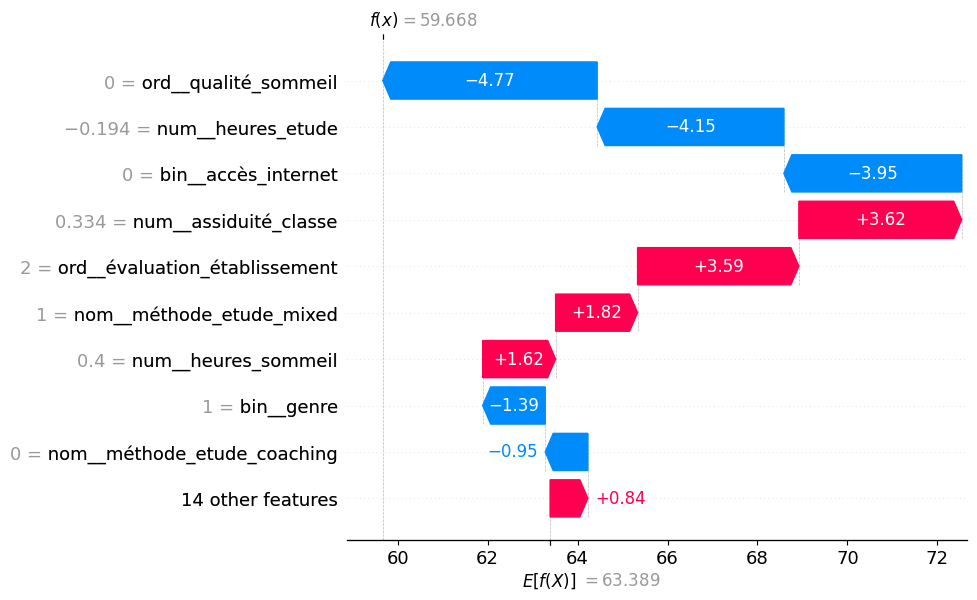

In [102]:
# -------- XGBoost --------

model = model_xg
X_valid = X_valid_Xg
X_train = dataset["scaled"]["X_train"]
feature_names = feature_names_xg


getSHAP(model, X_train, X_valid, feature_names, top_n=10, type="XGBoost")

Note that this XGBoost model has been trained on scaled numerical features, so direct number comparison with the linear regression results is tricky. We rather rank 





## OCR

### 1. Security

In [ ]:
# CIA (done in failure prediction, briefly mention)
# Model Evasion : “student manipulates inputs.”
# Data Poisoning : brief mention
# briefly : Membership Inference/Data Leak if privacy is a requirement
# prompt injection : what could the student do to inject and manipulate the model ?


### 2. Bias and Fairness

In [ ]:
# Representation bias / imbalance : Yes (class imbalance already mentioned).
# Fairness metrics : per‑class recall/precision disparity.  No strict demographic fairness (no sensitive groups).
# 


# Temporal bias / Concept drift (brief) : Risk if student behavior changes (new cohorts, policies)
# Measurement / Proxy bias : Self‑reported features can be inaccurate or manipulated, Some variables may be proxies for socioeconomic status
# Aggregation bias : Model trained on one school ≠ generalizable to other universities/countries
# Learning bias: model favors patterns dominant in training set
# Evaluation bias: metrics differ across groups
# Deployment bias: model use may not match real school goals
# Automation bias: staff may over‑trust predictions

### 3. Explainable AI (xAI)

In [ ]:
# Saliency / Integrated Gradients / Grad‑CAM
# Activation Maximization : yes, visually interesting but optionnal
# SHAP/LIME : maybe not ideal for images CNNs
# 
# 

you are an ai made to help me write a report extension on my previous report where i built a model to predict academic failure based on a dataset. this report uses almost exclusively kaggle courses functions. perform a critical analysis of whats been done.



ead how my report is structured and how to access data and models. which data should we use for our security, bias and eplainability supplement ? in the previous part of the report i made a lot of graphs, lets reuse them, improve them or add new ones in order to verify if any dataset imbalances exist and deduce insight from these results. keep the same general coding style as my report already has
